In [1]:
import numpy as np
from time import time
from matplotlib import pyplot as plt
from numba import jit
from tqdm import tqdm
import pickle
from scipy import interpolate

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size='22')
#plt.rcParams['figure.dpi'] = 150
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1.5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1.5

In [3]:
import sys
sys.path.append('/home/addis/PkBk/Library')
sys.path.append('/home/addis/PkBk/Scripts')
import get_field as gf
import compute_grid_info as cgi
import Pk 

In [4]:
#load field from file on server...
###skip if have own field

path = '../../../data/Quijote/' #path to folder containing quijote files.
N_side = 128
rsd_direction = '' # 'z'

redshift = '/snapdir_004/snap_004'
if redshift[-1] == str(4):
    red_info = 'z=0'
elif redshift[-1] == str(2):
    red_info = 'z=1'
else:
    red_info = 'z=NA'

realisation = str(10016)
field_tmp = np.load(path + 'fields_CIC/' + realisation + '_' + red_info + '_' + str(N_side) + '_LOS=Cen'+ '.npy') #load field


In [5]:
# save/load disctionaries
def save_dict(pk_save):
    #save dictionary to particualar folder
    # create a binary pickle file 
    f_open = open('pk_dict_'+ red_info +'_' + str(N_side) + ".pkl","wb")
    
    pk_save['ks'] = k_est  # saves k for future.
    pickle.dump(pk_save,f_open)
    # close file
    f_open.close()
    pk_save.pop('ks', None)#cos sometimes it sus

#save_dict(pks)   

with open('pk_dict_'+ red_info +'_' + str(N_side) + ".pkl", 'rb') as f:
    pk_load = pickle.load(f)
    ks_load = pk_load['ks'] #get ks
    pk_load.pop('ks', None) # remove ks from dict
pks = pk_load

In [6]:
%%time
#define grid information
Nside=128               #grid resolution
L=1000                  #size of box Mpc/h
rfft=False              #use real ffts?
order=2                 #order MAS correction 2- CIC
obs_pos=(0,0,0)         #position of observer defined from centre of box
dtype=np.complex64      #np.complex128 also allowed - single or double precision
threads=4               #no. threads for pyfftw to use
verbose=True    


#get array of statistics for grid
grid_info = cgi.compute_survey(Nside,L,rfft,order,obs_pos)#xi,x_norm,ki,k_mag,MAS,k_f,k_ny

CPU times: user 6.82 s, sys: 233 ms, total: 7.06 s
Wall time: 7.08 s


In [7]:
%%time
s=1 #size of bins in units of 2*k_f
k_est = np.arange(grid_info[5],grid_info[6],2*s*grid_info[5]) + s*grid_info[5] #create k bins centers - from k_f to k_ny with steps of s*k_f

#compute binning information
binning_info = cgi.pk_compute_bins(k_est,s,grid_info[3],grid_info[5])#In_bin,N_modes

CPU times: user 1.89 s, sys: 48.9 ms, total: 1.94 s
Wall time: 1.94 s


In [8]:
#define stuff related to each multipole
t= 0
l = 1
exorder = 0 #order in x_12/d expansion in estimator

In [31]:
"""

Pk.Pk(delta,L,Nside,l,k_est,grid_info,binning_info,t,exorder,False,dtype,threads,rfft,verbose)

delta :    The overdensity field in format of np.array((N_side, N_side, N_side), dtype=dtype_r)

All others predefined...
"""

'\n\nPk.Pk(delta,L,Nside,l,k_est,grid_info,binning_info,t,exorder,False,dtype,threads,rfft,verbose)\n\ndelta :    The overdensity field in format of np.array((N_side, N_side, N_side), dtype=dtype_r)\n\nAll others predefined...\n'

In [32]:
#%%time
#get power_spectrum
Pk_ell = Pk.Pk(field_tmp,L,Nside,l,k_est,grid_info,binning_info,t,exorder,False,dtype,threads,rfft,verbose).pk

In [33]:
Pk_ell

array([-3.50496406e-13-9.54667871e+03j,  2.80784402e-13+6.54222534e+02j,
       -3.69614387e-13-1.13802441e+03j, -1.01390474e-13+6.14766052e+02j,
       -6.41792934e-14-9.87315445e+01j,  9.04506775e-14-3.90651428e+02j,
       -1.62956230e-14-1.25630447e+02j, -3.19434166e-15+1.55225800e+02j,
        0.00000000e+00-5.00477829e+01j,  1.61083915e-14-9.54055595e+00j,
        2.00943557e-14+2.96839790e+01j, -2.82658367e-15+2.70555763e+01j,
        9.40603322e-15+5.98590565e+00j, -1.24665521e-14-7.04589558e+00j,
        1.79853047e-15+5.82121887e+01j,  8.63118357e-15-1.84189129e+01j,
        5.56039098e-15+1.31112585e+01j, -1.87281568e-15-5.85297346e+00j,
       -1.12388270e-15+2.41636276e+01j,  3.04444775e-15+2.33536720e+01j,
       -4.57649466e-16-8.09795761e+00j,  8.30288800e-16+1.12154245e+00j,
        7.69272358e-16+2.46569767e+01j, -3.50980490e-16+2.84609818e+00j,
       -6.42888901e-16+6.16018724e+00j, -1.85584622e-15+6.35318327e+00j,
       -5.55264561e-16+4.23389339e+00j,  1.28267067

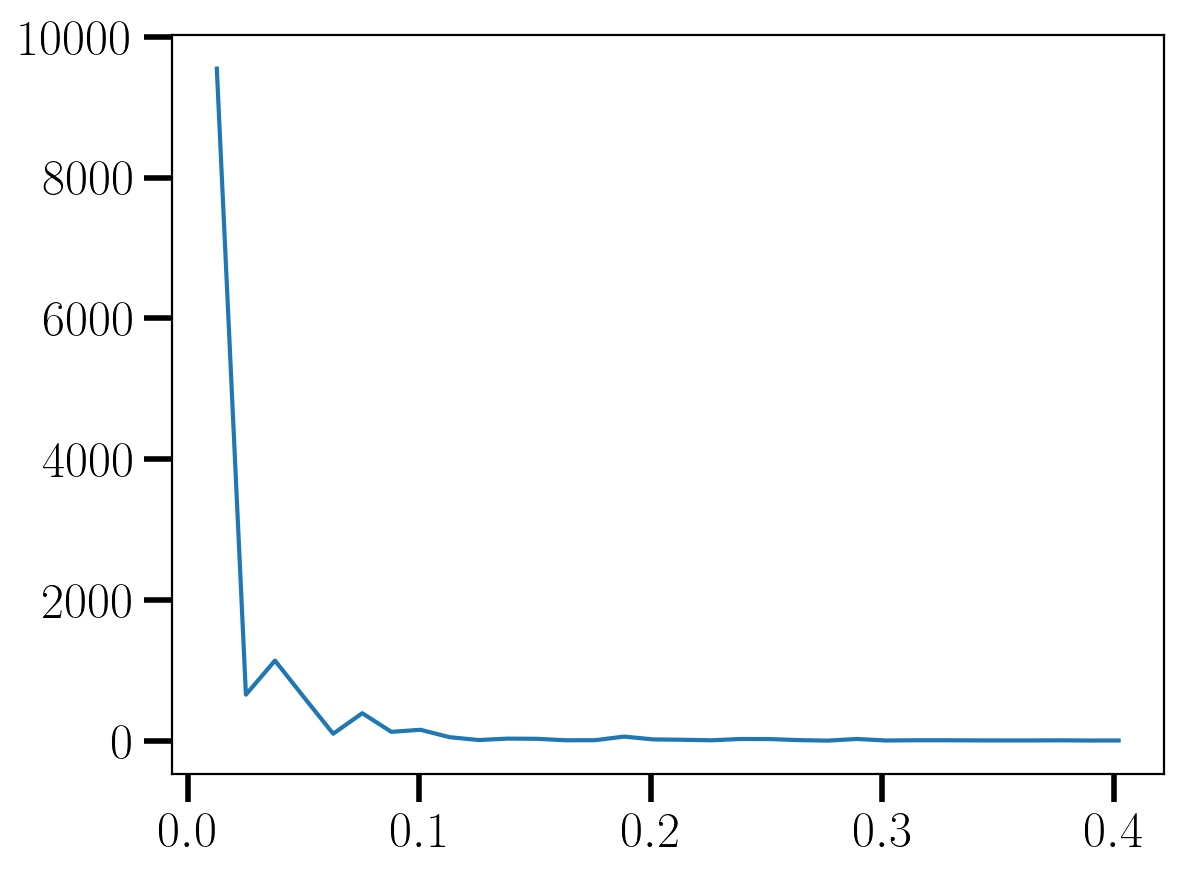

In [34]:
plt.plot(k_est,np.abs(Pk_ell))
plt.show()

# If you want to save results over realisations in dict...

In [35]:
#define empty dict to fill in...
pks = {
    'Cen' : {},#redshift space in centre
    '-500' : {},#z_obs
    '0':{},
    'PP' : {}, # PP with RSD
    'real': {}, #real space
    '-1000' : {},
    '250' : {},
    '0_other' : {},
    '-100' : {},
    '100' : {},
    '-250' : {},
    '400' : {},
    '-400' : {}
    } 

In [94]:
#this is designed
def pk_realisations(field,init_dict,ls,ts,exorder,obs_pos,N_min,N_max):#add path so choose fields as were
    """function to run to calculate bispectrum for different multiplles over realisations"""
    pk_dict= init_dict.copy()
    N_side=128
    L=1000
    rfft=False
    order=2
    #obs_pos=(500,500,z_obs)#
    grid_info = cgi.compute_survey(N_side,L,rfft,order,obs_pos)
    
    iFFT=False
    dtype=np.complex64
    threads=4
    verbose=True
    
    #s=1/2 #units of 2*k_f
    k_est = np.arange(grid_info[5],grid_info[6],2*s*grid_info[5]) + s*grid_info[5] #create k bins centers - from k_f to k_ny with steps of s*k_f
    binning_info = cgi.pk_compute_bins(k_est,s,grid_info[3],grid_info[5])
    #In_bin,N_modes 
    
    for t in ts:#which LOS
        for l in ls:  #which multipoles to calculate
            key_mono = 'l=%d'%(0)
            key ='l=%d'%(l) +',t=' + str(t)[-1]

            arr_pk = np.zeros((N_max-N_min,len(k_est)),dtype=np.complex64) #create empty arrays in dict to store bispectra
            arr_mono = np.zeros((N_max-N_min,len(k_est)),dtype=np.complex64)
            for i in tqdm(range(N_min,N_max)):
                realisation = str(10000 + i)
                                                            #
                field_tmp = np.load(path + 'fields_CIC/' + realisation + '_' + red_info + '_' + str(N_side) + field+ '.npy') #load field
                j = Pk.Pk(field_tmp,L,N_side,l,k_est,grid_info,binning_info,t,exorder,iFFT,dtype,threads,rfft,verbose)
                arr_pk[i-N_min] = j.pk
                if l % 2 == 0:
                    arr_mono[i-N_min] = j.mono
            
            #for resets...
            if key in pk_dict.keys():
                if len(pk_dict[key]) >= N_max - N_min:#in case of error just delete
                    pk_dict.pop(key, None)
                    pk_dict.pop(key_mono, None)
                
            if key in pk_dict.keys(): # create array with extra zeros beyond which has already been computed
                pk_dict[key] = np.concatenate((pk_dict[key][:N_min],arr_pk))
                if l % 2 == 0:#if even
                    pk_dict[key_mono] = np.concatenate((pk_dict[key_mono][:N_min],arr_mono))
            else:
                pk_dict[key] = arr_pk
                if l % 2 == 0:#if even
                    pk_dict[key_mono] = arr_mono
                 
    return pk_dict

ls= [1]#
ts = [0]#

exorder = 0

obs_pos = (500,500,0)#-1e+10

field = str(obs_pos[-1]) #'Cen' #'PP'#'Cen'#'0_other'#'000'# 'real'#
field_add = '_LOS='+field
if field == 'real': #real has a different naming convention for no reason
    field_add = ''
    
pks[field] = pk_realisations(field_add,pks[field],ls,ts,exorder,obs_pos,0,100)

100%|██████████| 100/100 [00:36<00:00,  2.76it/s]


In [9]:
#calculate avg and std of all realisations
def avg_err(Pk):#ok so adapt to nested dict structure...
    Pk_avg = {}
    Pk_err = {}
    Pk_std = {}
    for i in Pk.keys():#so this loops over each type - i.e. PP,Cen,real_space
        Pk_avg[i] = {}#create the nested dictionary to fill...
        Pk_err[i] = {}
        Pk_std[i] = {}
        for j in Pk[i].keys(): # loop over multipole keys - to get mean and std for each
            Pk_avg[i][j] = np.mean((Pk[i][j]),axis=0)
            Pk_err[i][j] = np.std(Pk[i][j],axis=0)/np.sqrt(len(Pk[i][j])) # standard error makes sense as we have independent realisations
            Pk_std[i][j] = np.std(Pk[i][j],axis=0)
    return Pk_avg,Pk_err,Pk_std

Pk_avg,Pk_err,Pk_std = avg_err(pks)

In [20]:
Pk_avg

{'Cen': {},
 '-500': {},
 '0': {},
 'PP': {'l=2,t=0': array([ 1.9276289e+04+1.5713546e-05j,  1.8828779e+04+1.2297434e-05j,
          1.3922291e+04+8.2980483e-07j,  9.4382510e+03+3.2588814e-06j,
          7.6765781e+03-3.9708866e-08j,  5.9455342e+03-9.8375449e-07j,
          4.3943843e+03+5.4283521e-07j,  3.5375857e+03+1.9087285e-07j,
          2.8039329e+03-5.6159184e-08j,  2.1886958e+03-4.2921499e-07j,
          1.7620574e+03-5.0523649e-08j,  1.4011520e+03-2.2508746e-07j,
          1.1054196e+03-5.0928346e-08j,  8.4273029e+02+1.1472498e-07j,
          6.2096893e+02-1.0963469e-07j,  4.3813388e+02+2.0312685e-08j,
          3.0134567e+02-1.2302710e-08j,  1.7995807e+02-4.6037680e-08j,
          8.0159645e+01-6.6212245e-08j, -7.1969271e+00+3.5114514e-08j,
         -8.4549423e+01+6.2051835e-09j, -1.5189201e+02+2.9350952e-08j,
         -1.9918149e+02+2.4901636e-09j, -2.4912729e+02-2.2635520e-08j,
         -2.9085474e+02-5.5321538e-09j, -3.2670651e+02+1.0684746e-08j,
         -3.6392206e+02+4

In [11]:
import cosmo_wap as cw
import cosmo_wap.pk as pk

# get cosmology from classy (Planck 2018)
cosmo = cw.lib.utils.get_cosmo()

survey_params = cw.survey_params.SurveyParams()

#so now we can compute terms for this cosmology and for euclid-likes biases
#cosmo_funcs = cw.ClassWAP(cosmo,[survey_params.Euclid],compute_bias=True)
cosmo_funcs = cw.ClassWAP(cosmo,[survey_params.DM_part(cosmo)])
cosmo_funcs1 = cw.ClassWAP(cosmo,[survey_params.DM_part(cosmo)],nonlin=True)

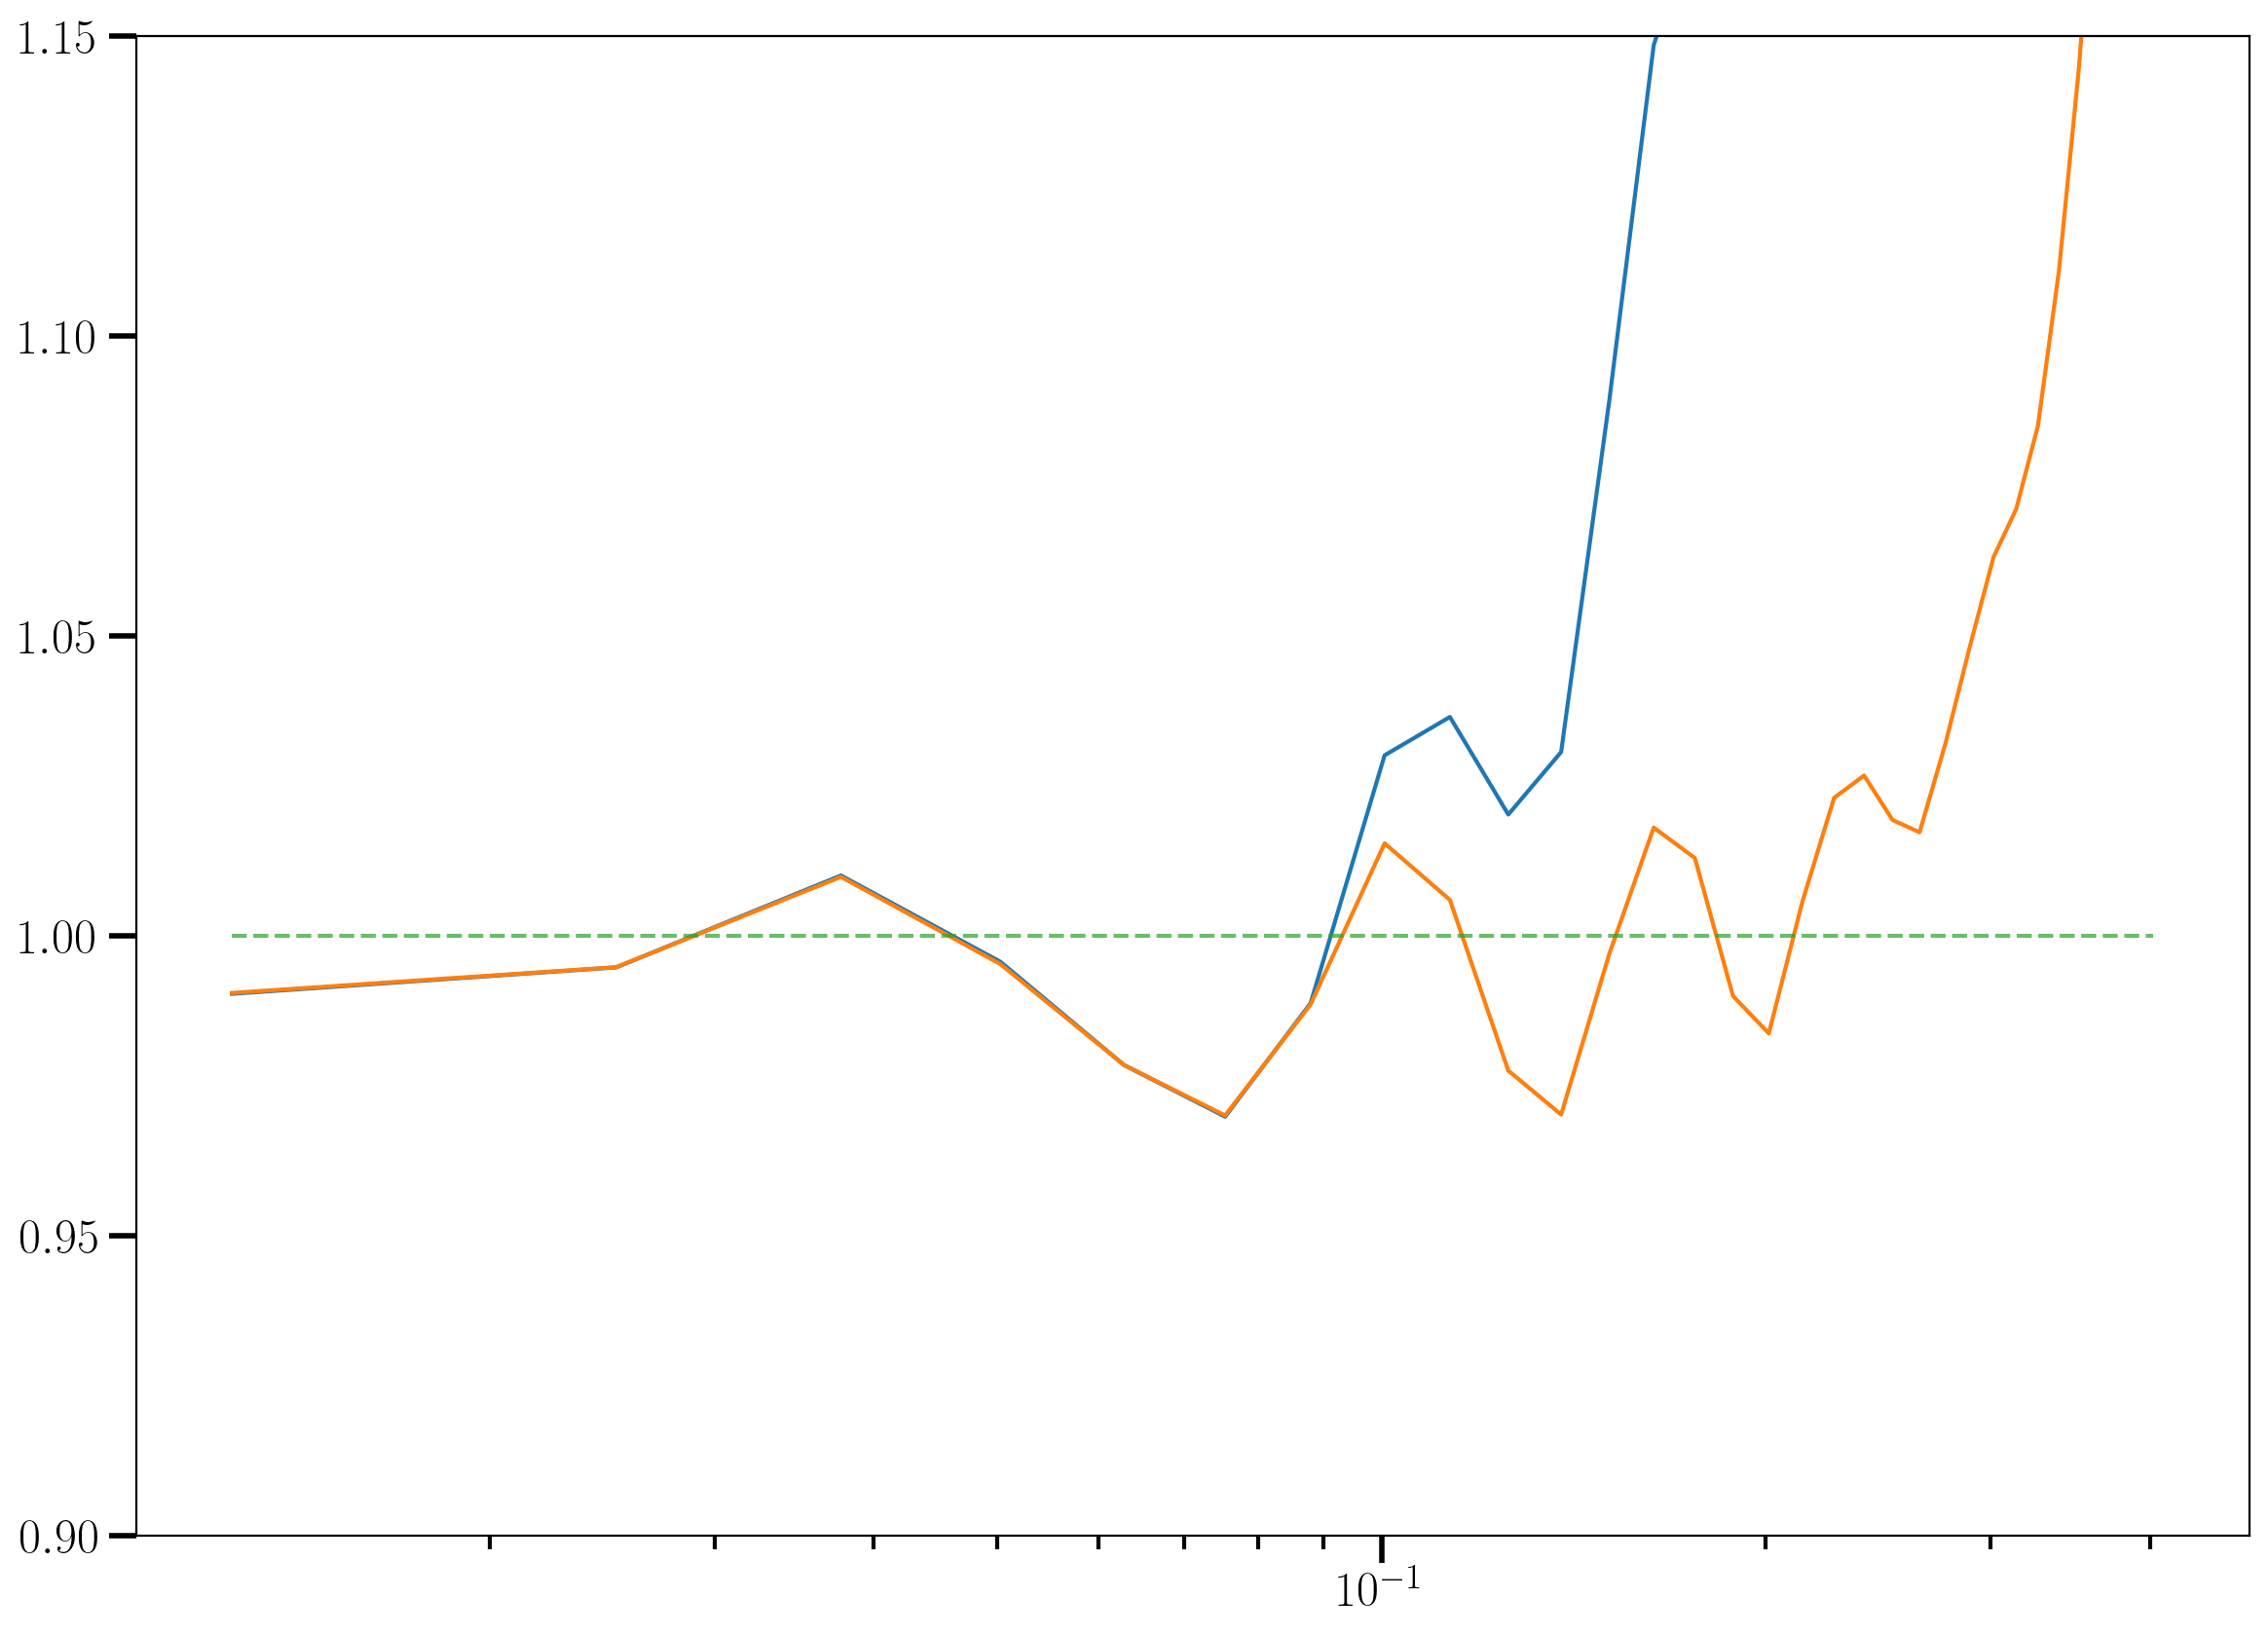

In [12]:
plt.figure(figsize=(14,10))
#plt.plot(k_est,Pk_avg['PP']['l=0'].real/pk.NPP.l0(cosmo_funcs,k_est,zz=0,sigma=None).real)
plt.plot(k_est,Pk_avg['PP']['l=0'].real/pk.NPP.l0(cosmo_funcs,k_est,zz=0,sigma=6).real)
plt.plot(k_est,Pk_avg['PP']['l=0'].real/pk.NPP.l0(cosmo_funcs1,k_est,zz=0,sigma=6).real)
plt.plot(k_est,np.ones_like(k_est),'--',alpha=0.7)
plt.xscale('log')
plt.ylim(0.9,1.15)
plt.show()

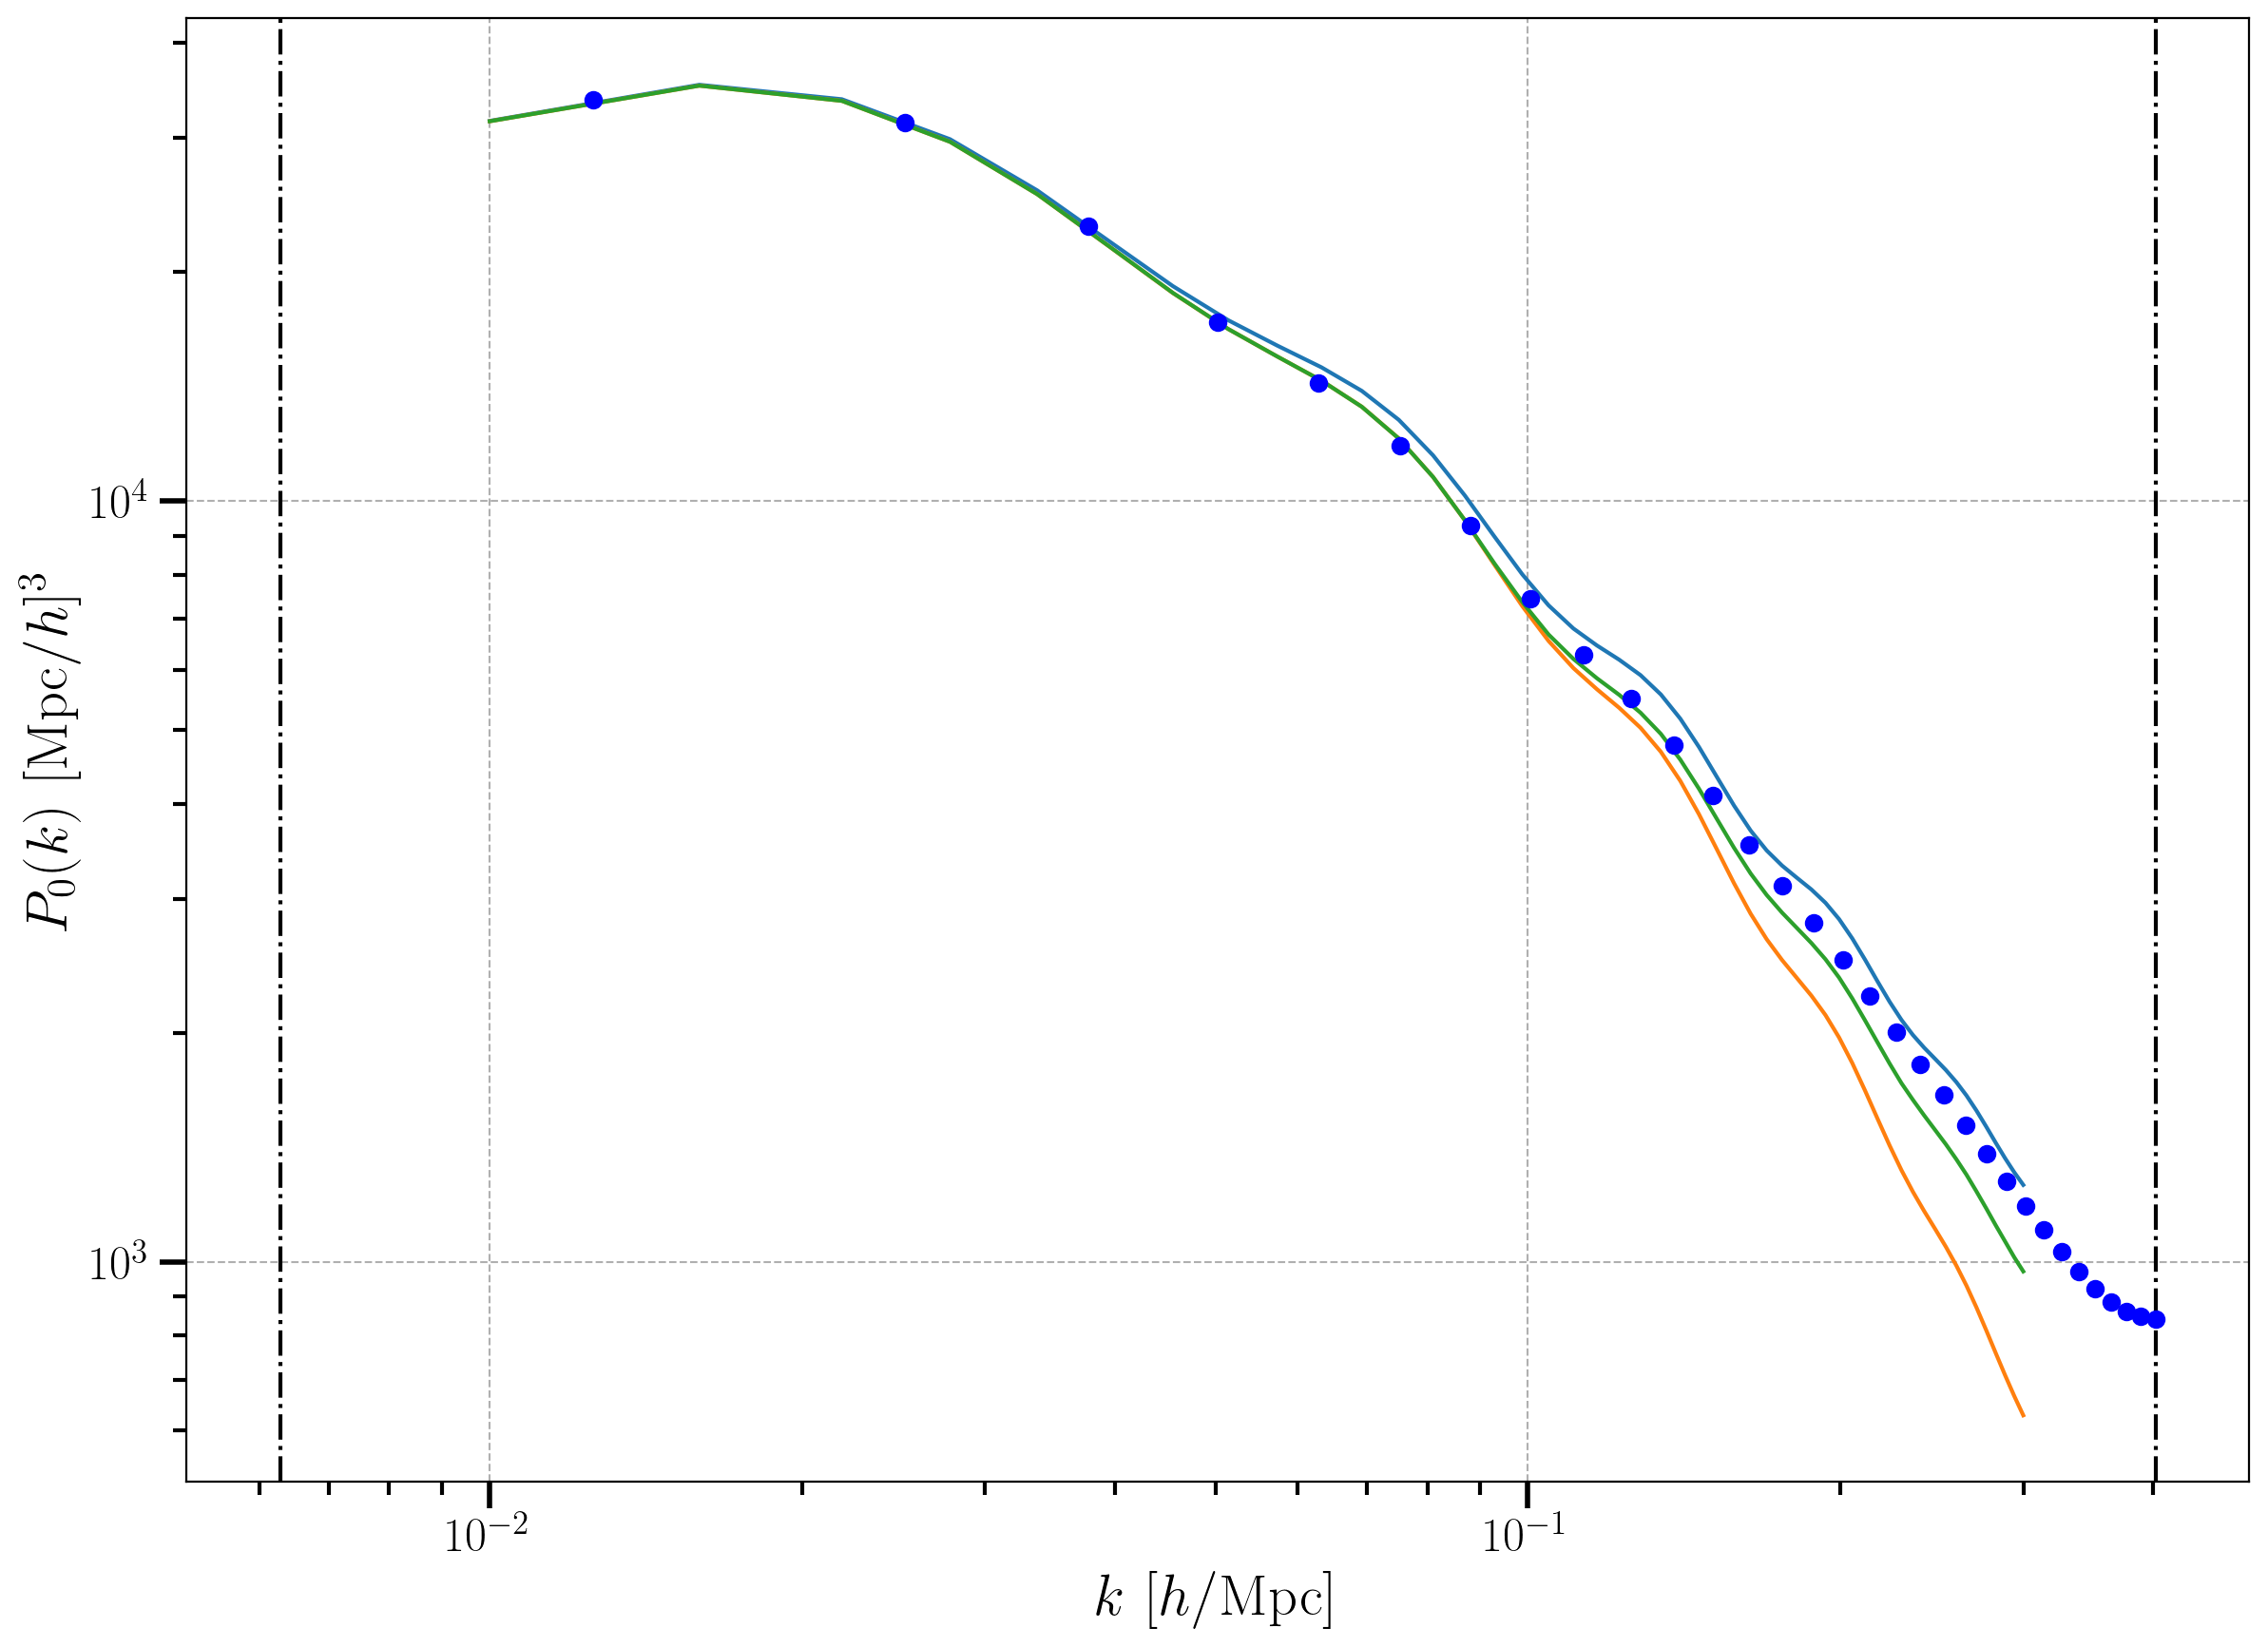

In [13]:
#monopole!!!
plt.figure(figsize=(14,10))

plt.errorbar(k_est,np.abs(Pk_avg['PP']['l=0'].real),yerr=Pk_err['PP']['l=0'],fmt ='o',color='blue')

k_plot = np.linspace(1e-2,3e-1)
plt.plot(k_plot,pk.NPP.l0(cosmo_funcs,k_plot,zz=0,sigma=None).real)
plt.plot(k_plot,pk.NPP.l0(cosmo_funcs,k_plot,zz=0,sigma=7).real)
plt.plot(k_plot,pk.NPP.l0(cosmo_funcs1,k_plot,zz=0,sigma=7).real)

plt.axvline(x = grid_info[5], linestyle='-.', color = 'black')
plt.axvline(x = grid_info[6], linestyle='-.', color = 'black')
#plt.xlim(5e-3,0.5e0)
#plt.ylim(3e+3,5e+4)
plt.xlabel('$k\,\,[h/\mathrm{Mpc}]$')
plt.ylabel('$ P_{0}(k)\,\,[\mathrm{Mpc}/h]^3$')

plt.xscale('log')
plt.yscale('log')

plt.grid(ls='--',lw=0.75)
plt.show()

In [101]:
from cosmo_wap.forecast import PkForecast, BkForecast
pkfore = PkForecast([1,1.2], cosmo_funcs, k_max=0.2, s_k=2)
cov = pkfore.get_cov_mat([0])

print(cov.shape)

(1, 1, 46)


In [102]:
z=0
#kk = np.linspace(0.01,0.3,1000)

COV = pk.cov.COV_MU()
COV1 = pk.cov.COV(cosmo_funcs,kk,z)
l2=0
l1=0

In [141]:
from cosmo_wap.forecast import PkForecast, BkForecast
pkfore = PkForecast([0,0.2], cosmo_funcs, k_max=0.3, s_k=1)
pkfore1 = PkForecast([0,0.2], cosmo_funcs, k_max=0.3, s_k=2)
cov = pkfore.get_cov_mat([0])


k_f = grid_info[-2]
s_k = 2
kk = pkfore.args[1]
N_k = 4*np.pi*kk**2 * (s_k*k_f)
A = k_f**3 /N_k

In [151]:
 len(pkfore.cov.cosmo_funcs_list)

1

In [142]:
pkfore.cov.get_cov([0])

array([[[2.82886467e+09+0.j, 4.65603111e+09+0.j, 4.26888799e+09+0.j,
         3.09354074e+09+0.j, 2.08357295e+09+0.j, 1.46039170e+09+0.j,
         1.12294922e+09+0.j, 9.33179945e+08+0.j, 7.89882466e+08+0.j,
         6.44154474e+08+0.j, 4.94692916e+08+0.j, 3.64162122e+08+0.j,
         2.68800066e+08+0.j, 2.08788181e+08+0.j, 1.74444307e+08+0.j,
         1.54173754e+08+0.j, 1.38280633e+08+0.j, 1.20851663e+08+0.j,
         1.00985943e+08+0.j, 8.13273186e+07+0.j, 6.49503120e+07+0.j,
         5.31935882e+07+0.j, 4.56090971e+07+0.j, 4.08267138e+07+0.j,
         3.73439053e+07+0.j, 3.39704734e+07+0.j, 3.01124372e+07+0.j,
         2.59527104e+07+0.j, 2.20407267e+07+0.j, 1.88033837e+07+0.j,
         1.63706549e+07+0.j, 1.46413463e+07+0.j, 1.33771379e+07+0.j,
         1.23096131e+07+0.j, 1.12523265e+07+0.j, 1.01425434e+07+0.j,
         9.02071850e+06+0.j, 7.97900883e+06+0.j, 7.09396622e+06+0.j,
         6.38714752e+06+0.j]]])

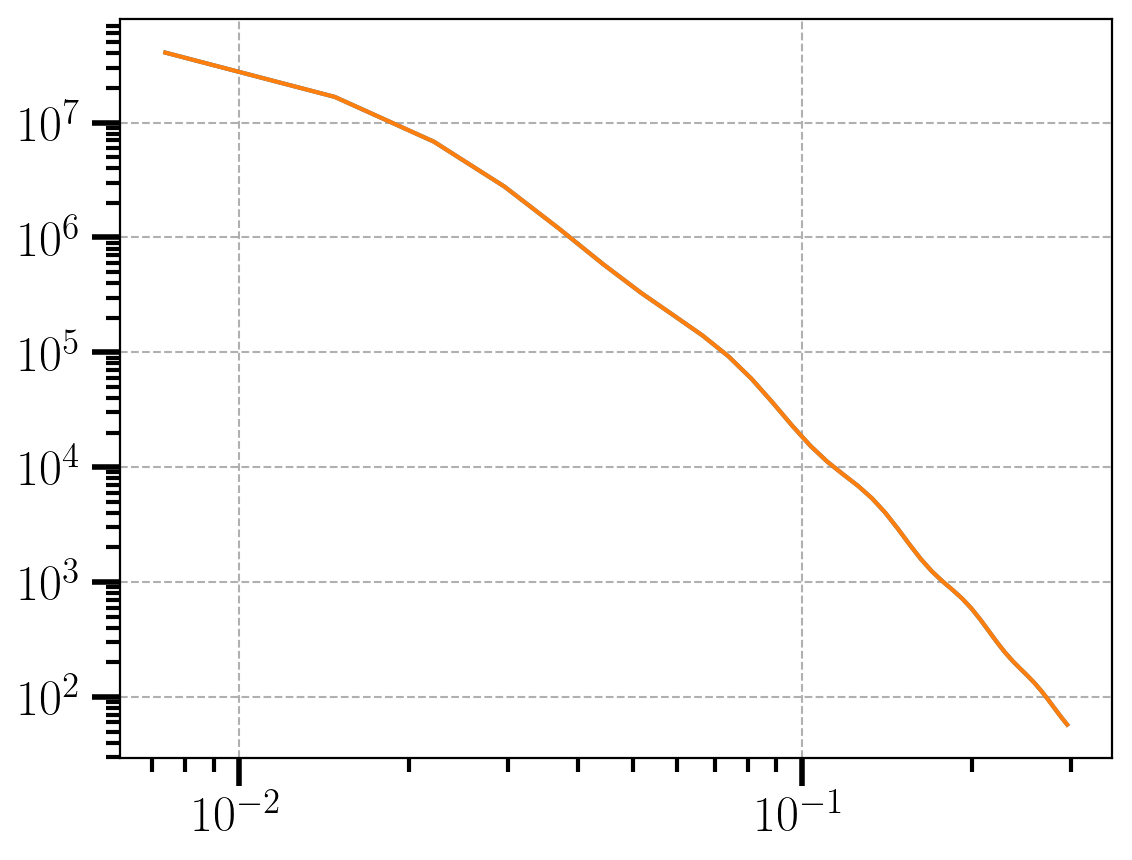

In [147]:

#plt.plot(k_est,(Pk_std['PP']['l=0'])**2, 'x')
#plt.plot(kk,A*np.abs(COV.cov_l1l2('NPP','NPP',2,2,cosmo_funcs,kk,0.1,n_mu=64,fast=False).real),'k')
#plt.plot(kk,A*np.abs(COV.cov_l1l2('NPP','NPP',l2,l1,cosmo_funcs1,kk,z,n_mu=64,fast=False).real),'grey','--')

#np.sqrt((grid_info[5]**3/(N_k))*
plt.plot(pkfore.args[1],(1/2)*A*pkfore.cov.get_cov([0])[0,0])

cov = pk.COV(cosmo_funcs,k_plot,zz=0.1)

delta_k = 2*s *grid_info[5]
N_k = 4*np.pi*k_plot**2 *delta_k
#this agrees with sims
#plt.plot(k_plot,((grid_info[5]**3/(N_k))*np.abs(cov.N22().real)))




plt.xscale('log')
plt.yscale('log')

plt.grid(ls='--',lw=0.75)
plt.show()

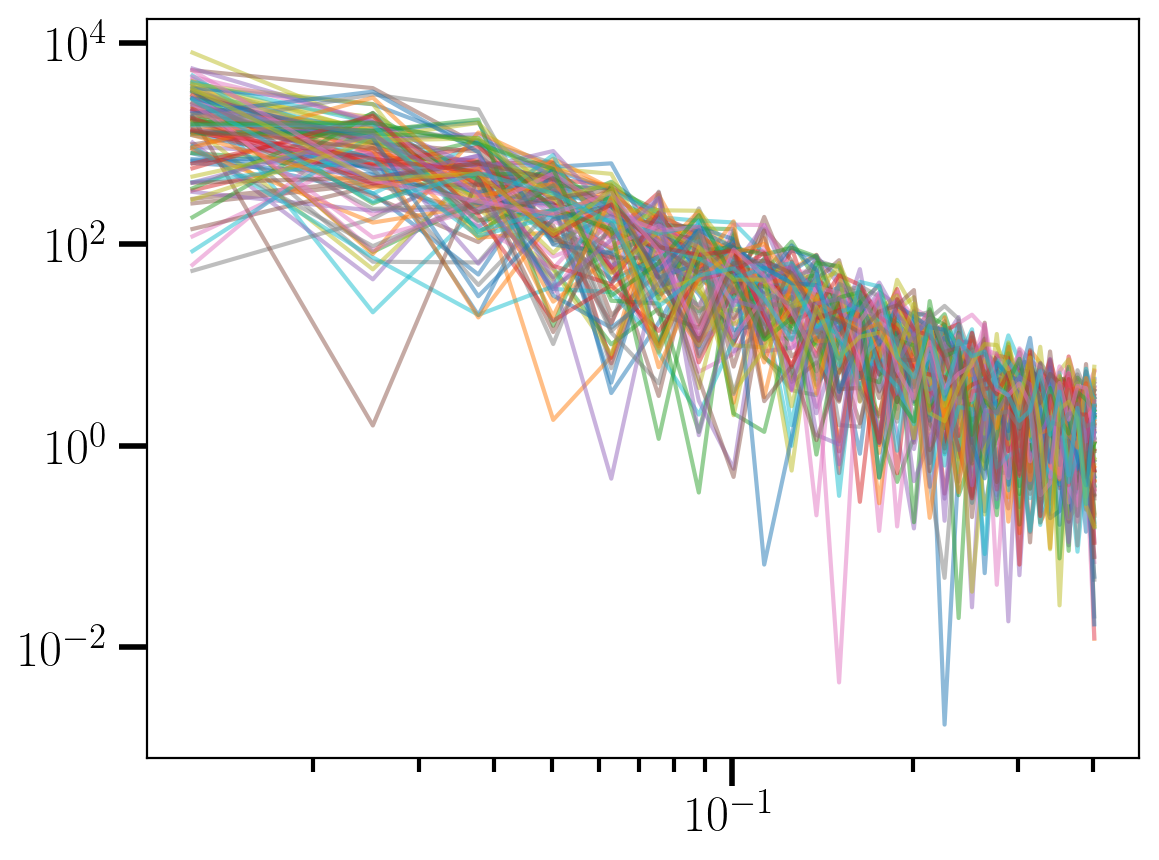

In [102]:
for i in pks['0']['l=1,t=0']:
    plt.plot(k_est,np.abs(i.imag),alpha=0.5)
    
plt.xscale('log')
plt.yscale('log')
    
plt.show()


In [ ]:

plt.figure(figsize=(14,10))

plt.errorbar(k_est,np.abs(Pk_avg['PP']['l=2,t=0'].real),yerr=Pk_err['PP']['l=2,t=0'],fmt ='o',color='blue')
k_plot = np.linspace(1e-2,3e-1)
plt.plot(k_plot,np.abs(pk.Pk0.l2(cosmo_funcs,k_plot,zz=0,sigma=0).real))
plt.plot(k_plot,np.abs(pk.Pk0.l2(cosmo_funcs,k_plot,zz=0,sigma=np.sqrt(2)*5).real))

plt.plot(k_plot,pk_quad_dfog(k_plot,zz=0,sigma=5), '--')

plt.axvline(x = grid_info[5], linestyle = '-.', color = 'black')
plt.axvline(x = grid_info[6], linestyle = '-.', color = 'black')
#plt.xlim(5e-3,0.5e0)
#plt.ylim(3e+3,5e+4)
plt.xlabel('$k\,\,[h/\mathrm{Mpc}]$')
plt.ylabel('$ P_{0}(k)\,\,[\mathrm{Mpc}/h]^3$')

plt.xscale('log')
plt.yscale('log')

plt.grid(ls='--',lw=0.75)

In [28]:
cw.forecast.PkForecast([1,1.5],cosmo_funcs,k_max=0.1,s_k=1,verbose=False)

cosmo_wap.forecast.PkForecast

In [65]:
print(1.7e-3)
print(1/(20*(np.pi)**3))

0.0017
0.0016125767216599747


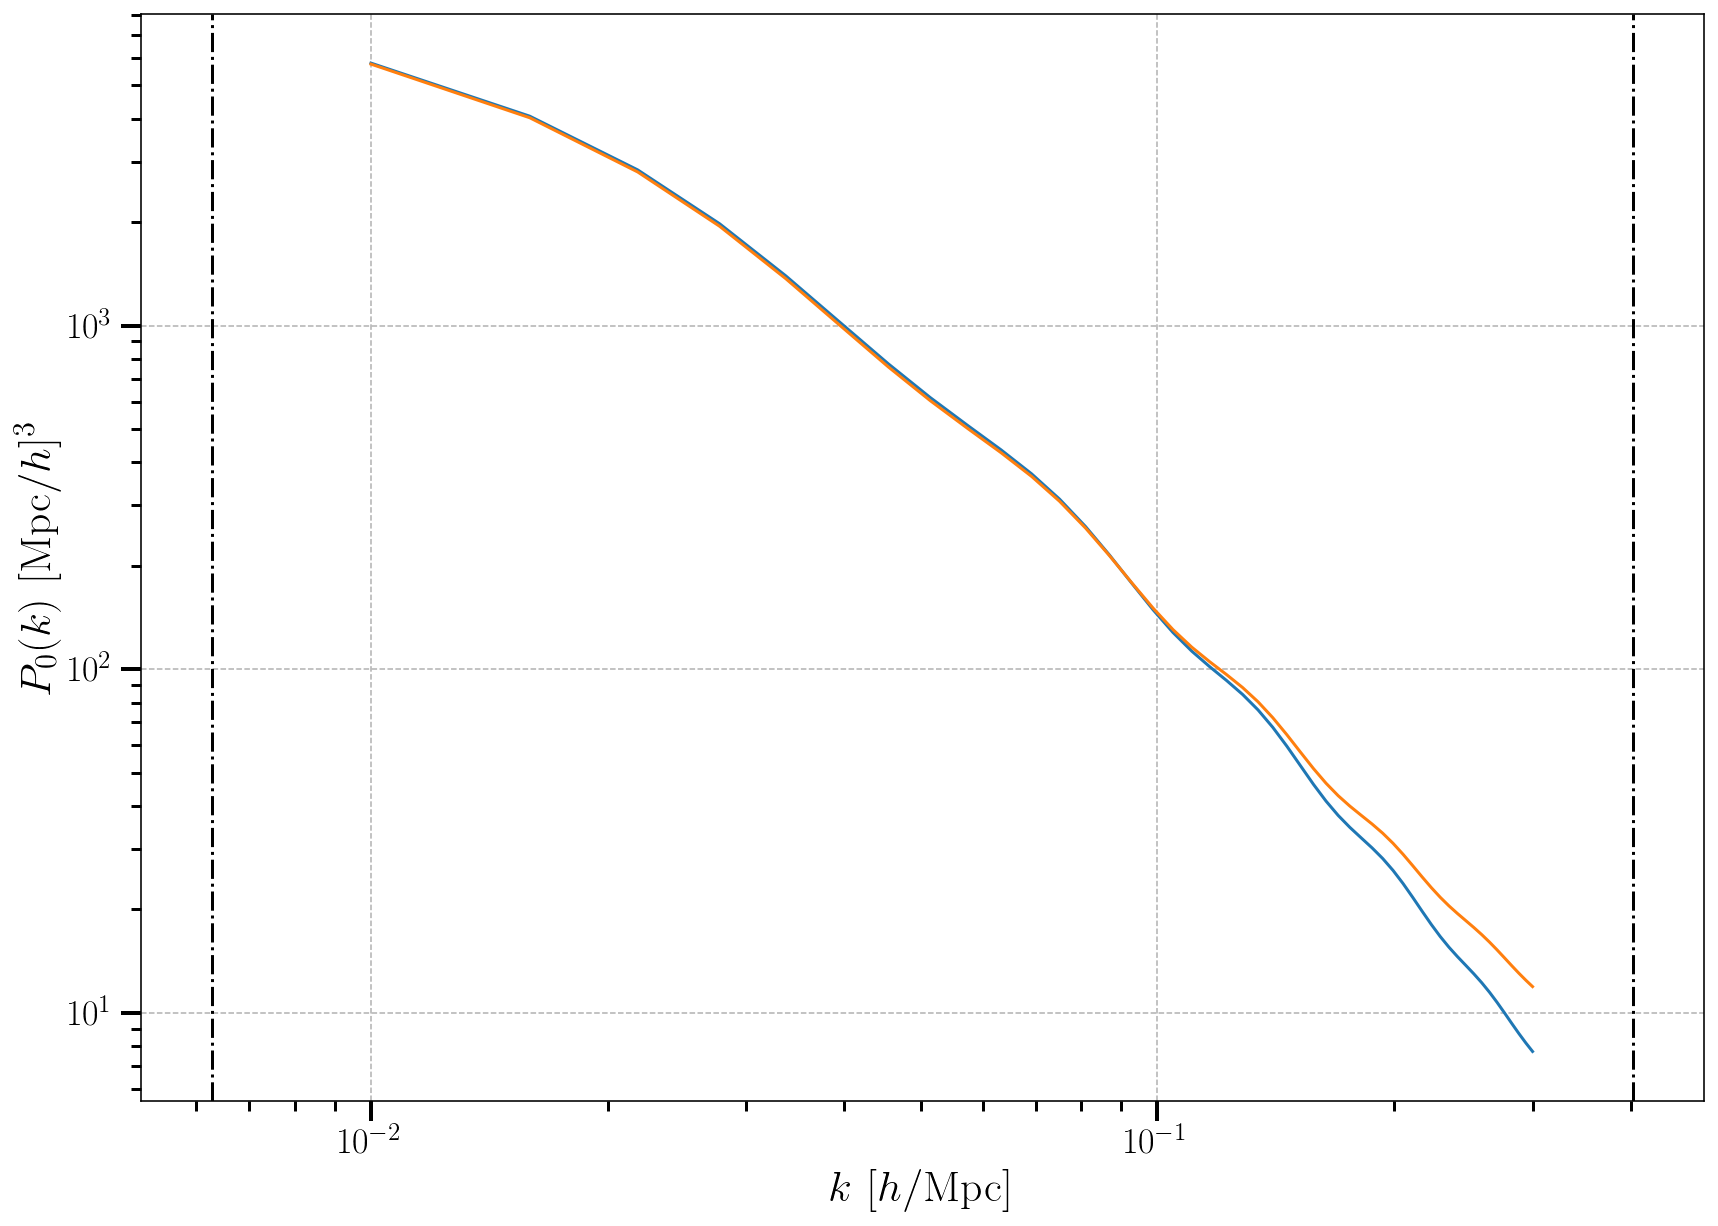

In [37]:
#lets plot covariances 
plt.figure(figsize=(14,10))

plt.errorbar(k_est,np.abs(Pk_std['PP']['l=0'].real),yerr=Pk_err['PP']['l=0'],fmt ='o',color='blue')
k_plot = np.linspace(1e-2,3e-1)
# define covariance
cov = pk.COV(cosmo_funcs,k_plot,zz=0)

N_k = 4*np.pi*k_plot**2 *2*s *grid_info[5]
#plt.plot(k_plot,np.sqrt((2*grid_info[5]**3/(4*np.pi*N_k))*np.abs(cov.N00().real)))

#this agrees with sims
plt.plot(k_plot,np.sqrt((grid_info[5]**3/(N_k))*np.abs(cov.N00().real)))

# define covariance
cov = pk.COV(cosmo_funcs,k_plot,zz=0,nonlin=True)
plt.plot(k_plot,np.sqrt((grid_info[5]**3/(N_k))*np.abs(cov.N00().real)))


plt.axvline(x = grid_info[5], linestyle = '-.', color = 'black')
plt.axvline(x = grid_info[6], linestyle = '-.', color = 'black')
plt.xlabel('$k\,\,[h/\mathrm{Mpc}]$')
plt.ylabel('$ P_{0}(k)\,\,[\mathrm{Mpc}/h]^3$')

plt.xscale('log')
plt.yscale('log')

plt.grid(ls='--',lw=0.75)

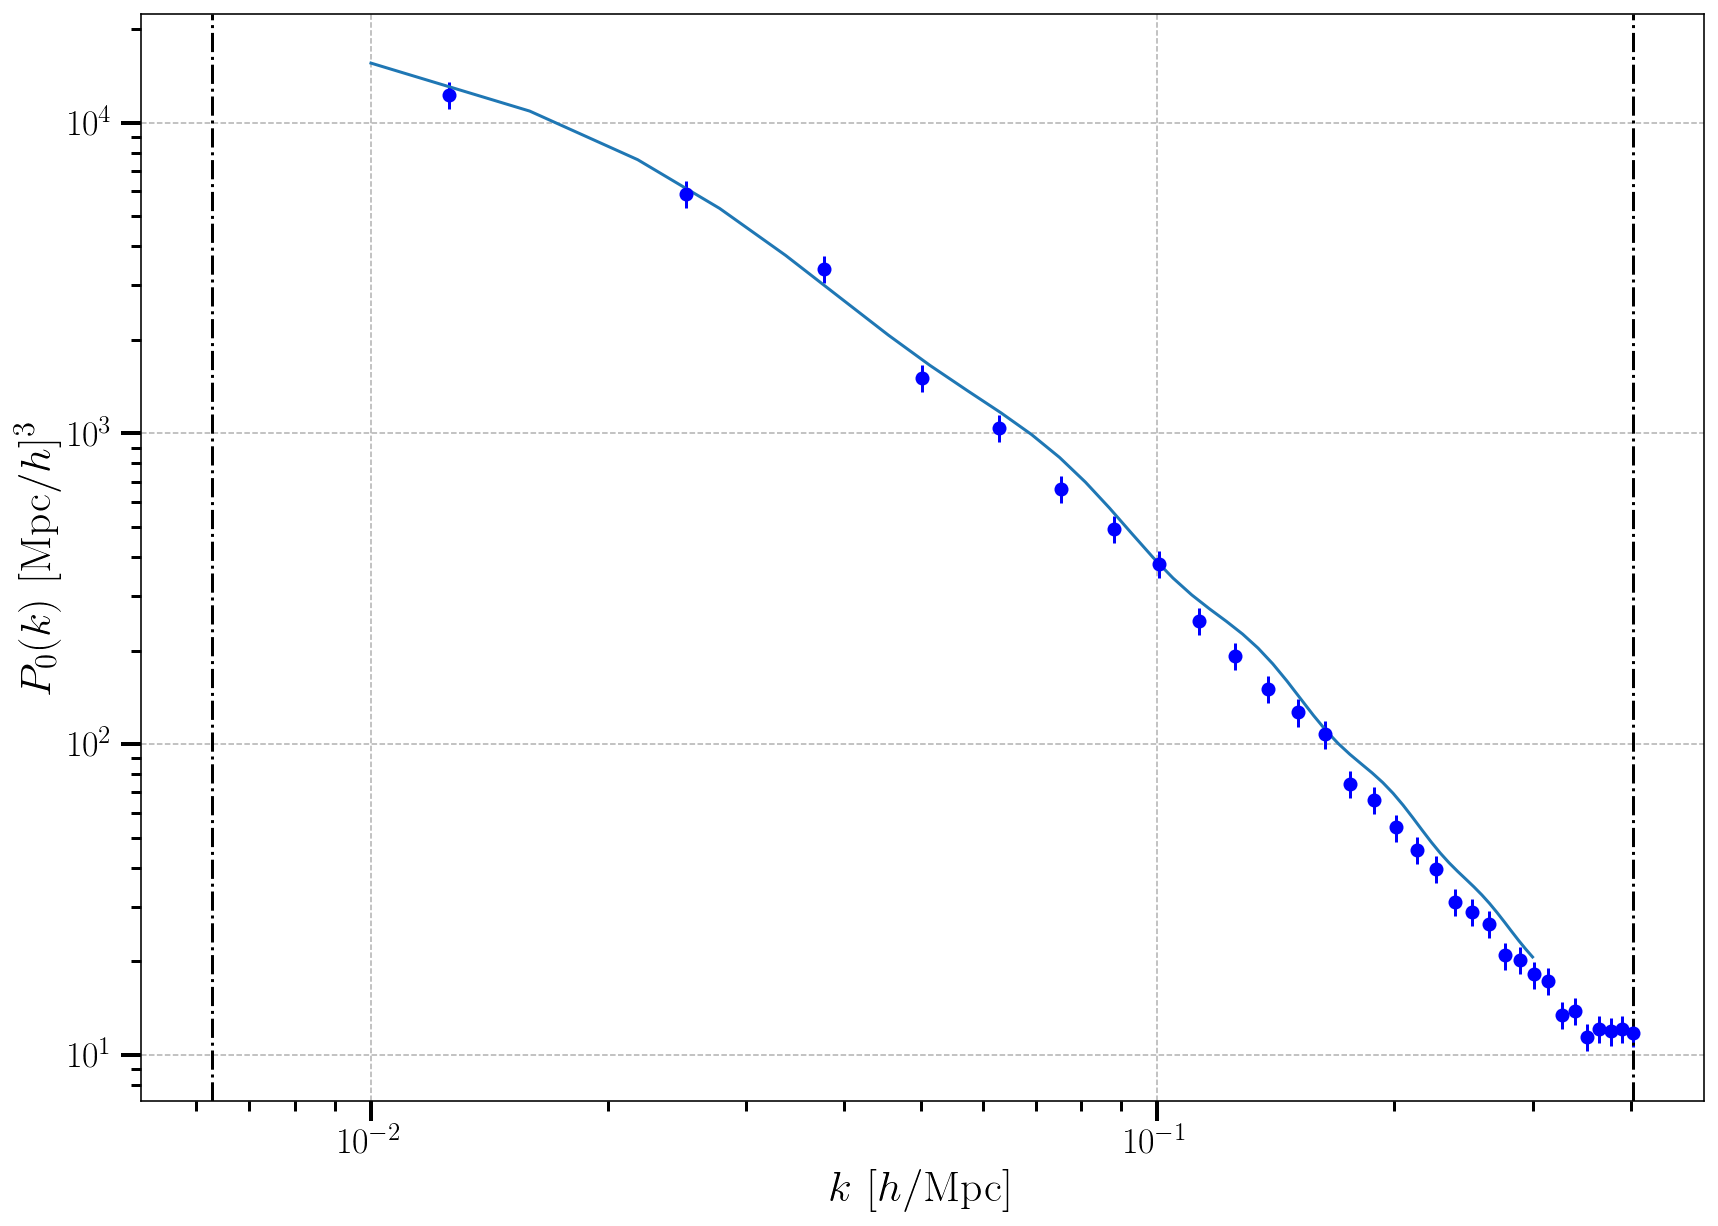

In [17]:
#lets plot covariances #  l22
plt.figure(figsize=(14,10))

plt.errorbar(k_est,np.abs(Pk_std['PP']['l=2,t=0'].real),yerr=Pk_err['PP']['l=2,t=0'],fmt ='o',color='blue')
k_plot = np.linspace(1e-2,3e-1)
# define covariance
cov = pk.COV(cosmo_funcs,k_plot,zz=0)

delta_k = 2*s *grid_info[5]
N_k = 4*np.pi*k_plot**2 *delta_k
#this agrees with sims
plt.plot(k_plot,np.sqrt((grid_info[5]**3/(N_k))*np.abs(cov.N22().real)))


plt.axvline(x = grid_info[5], linestyle = '-.', color = 'black')
plt.axvline(x = grid_info[6], linestyle = '-.', color = 'black')
plt.xlabel('$k\,\,[h/\mathrm{Mpc}]$')
plt.ylabel('$ P_{0}(k)\,\,[\mathrm{Mpc}/h]^3$')

plt.xscale('log')
plt.yscale('log')

plt.grid(ls='--',lw=0.75)

In [45]:
Pk_std['PP']

{'l=2,t=0': array([1.2304279e+04, 5.8873560e+03, 3.3855334e+03, 1.5112087e+03,
        1.0442963e+03, 6.6088647e+02, 4.9421741e+02, 3.8123523e+02,
        2.4936644e+02, 1.9209093e+02, 1.5070372e+02, 1.2663178e+02,
        1.0759761e+02, 7.4485977e+01, 6.6235115e+01, 5.4013008e+01,
        4.5838448e+01, 3.9624001e+01, 3.1093958e+01, 2.8827847e+01,
        2.6362547e+01, 2.0909969e+01, 2.0286119e+01, 1.8178320e+01,
        1.7328856e+01, 1.3500984e+01, 1.3883913e+01, 1.1412061e+01,
        1.2169516e+01, 1.1925011e+01, 1.2109907e+01, 1.1781134e+01],
       dtype=float32),
 'l=0': array([4628.121    , 2265.502    , 1162.4464   ,  639.5426   ,
         484.84296  ,  286.16263  ,  205.17863  ,  136.94426  ,
         105.89737  ,   83.800316 ,   54.833435 ,   49.262283 ,
          43.27782  ,   31.07214  ,   25.604746 ,   22.282286 ,
          22.360634 ,   16.204384 ,   16.591198 ,   13.560315 ,
          11.505476 ,    9.898723 ,    8.793216 ,    8.856382 ,
           6.8373985,    5.752

In [40]:
covl2l0 = np.mean(pks['PP']['l=0']*pks['PP']['l=2,t=0'],axis=0) - np.mean(pks['PP']['l=0'],axis=0)*np.mean(pks['PP']['l=2,t=0'],axis=0)
#covl2l0 = (1/100)*np.sum((pks['PP']['l=0']-np.mean(pks['PP']['l=0'],axis=0))*(pks['PP']['l=2,t=0']-np.mean(pks['PP']['l=2,t=0'],axis=0)),axis=0)
        

/opt/jupyterhub/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


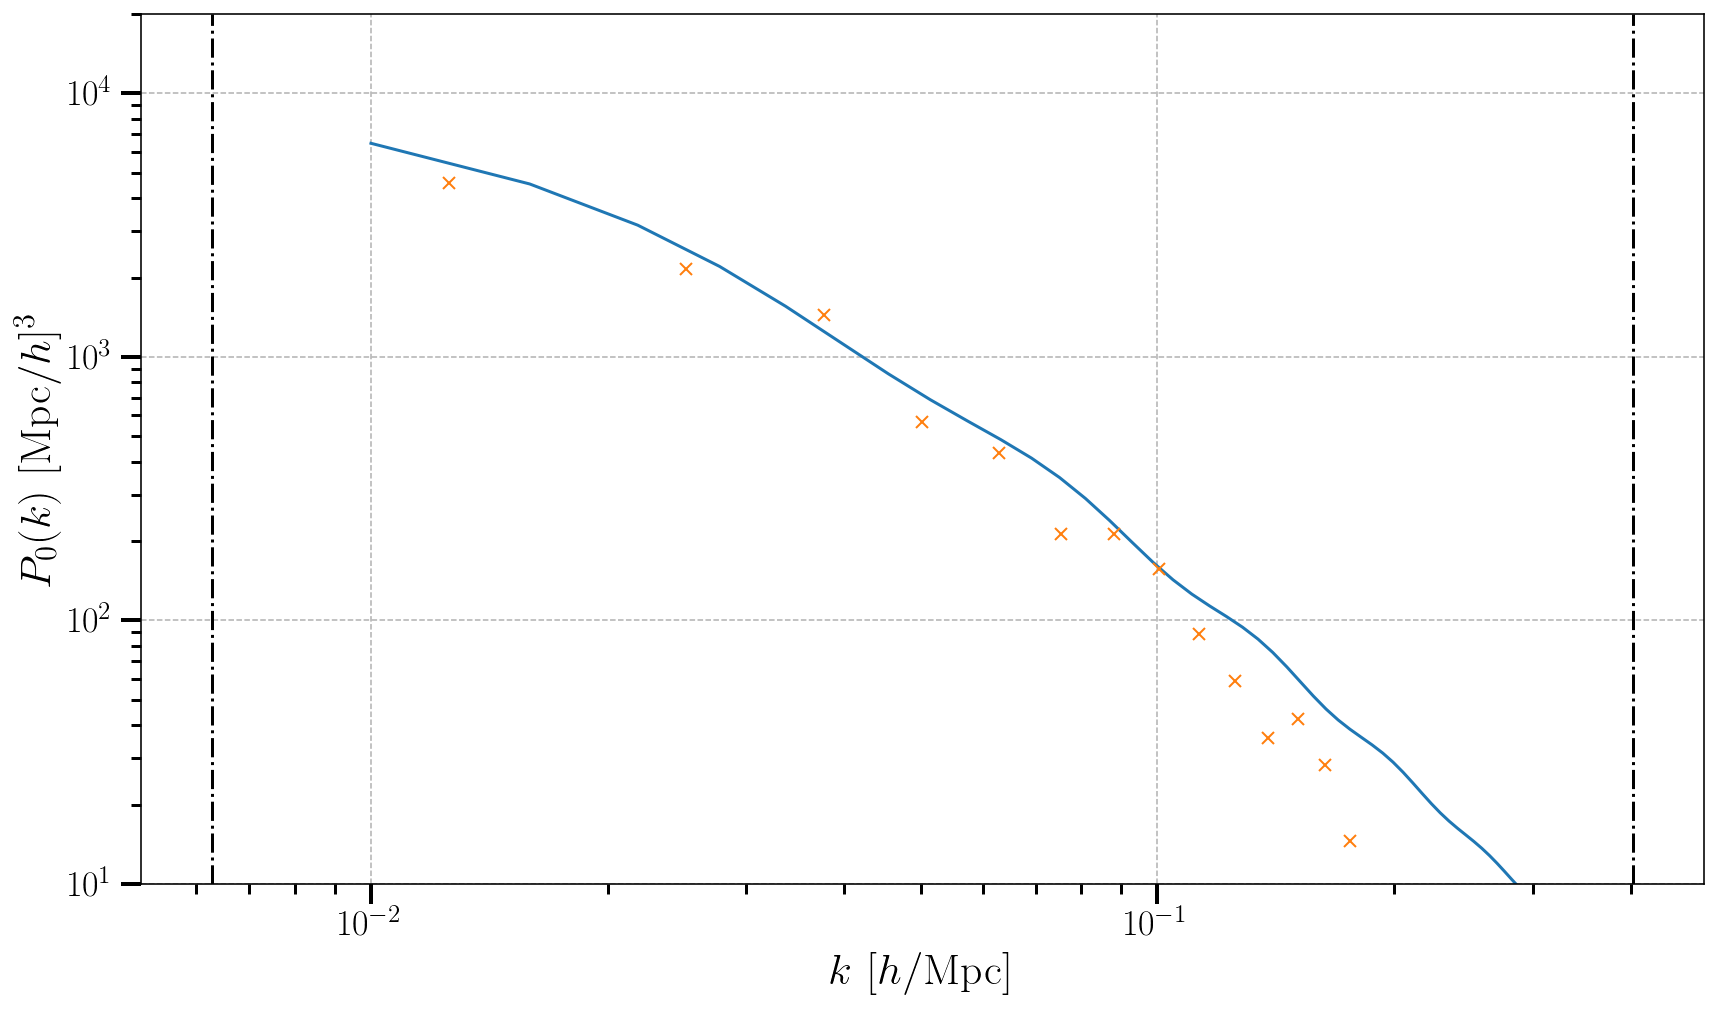

In [41]:
#lets plot covariances #  l20
plt.figure(figsize=(14,8))

k_plot = np.linspace(1e-2,3e-1)
# define covariance
cov = pk.COV(cosmo_funcs,k_plot,zz=0)

delta_k = 2*s *grid_info[5]
N_k = 4*np.pi*k_plot**2 *delta_k

plt.plot(k_plot,np.sqrt((grid_info[5]**3/(N_k))*np.abs(cov.N20().real)))

plt.plot(k_est, np.sqrt(covl2l0),'x')

plt.axvline(x = grid_info[5], linestyle = '-.', color = 'black')
plt.axvline(x = grid_info[6], linestyle = '-.', color = 'black')

plt.ylim(1e+1,2e+4)
plt.xlabel('$k\,\,[h/\mathrm{Mpc}]$')
plt.ylabel('$ P_{0}(k)\,\,[\mathrm{Mpc}/h]^3$')

plt.xscale('log')
plt.yscale('log')
plt.grid(ls='--',lw=0.75)

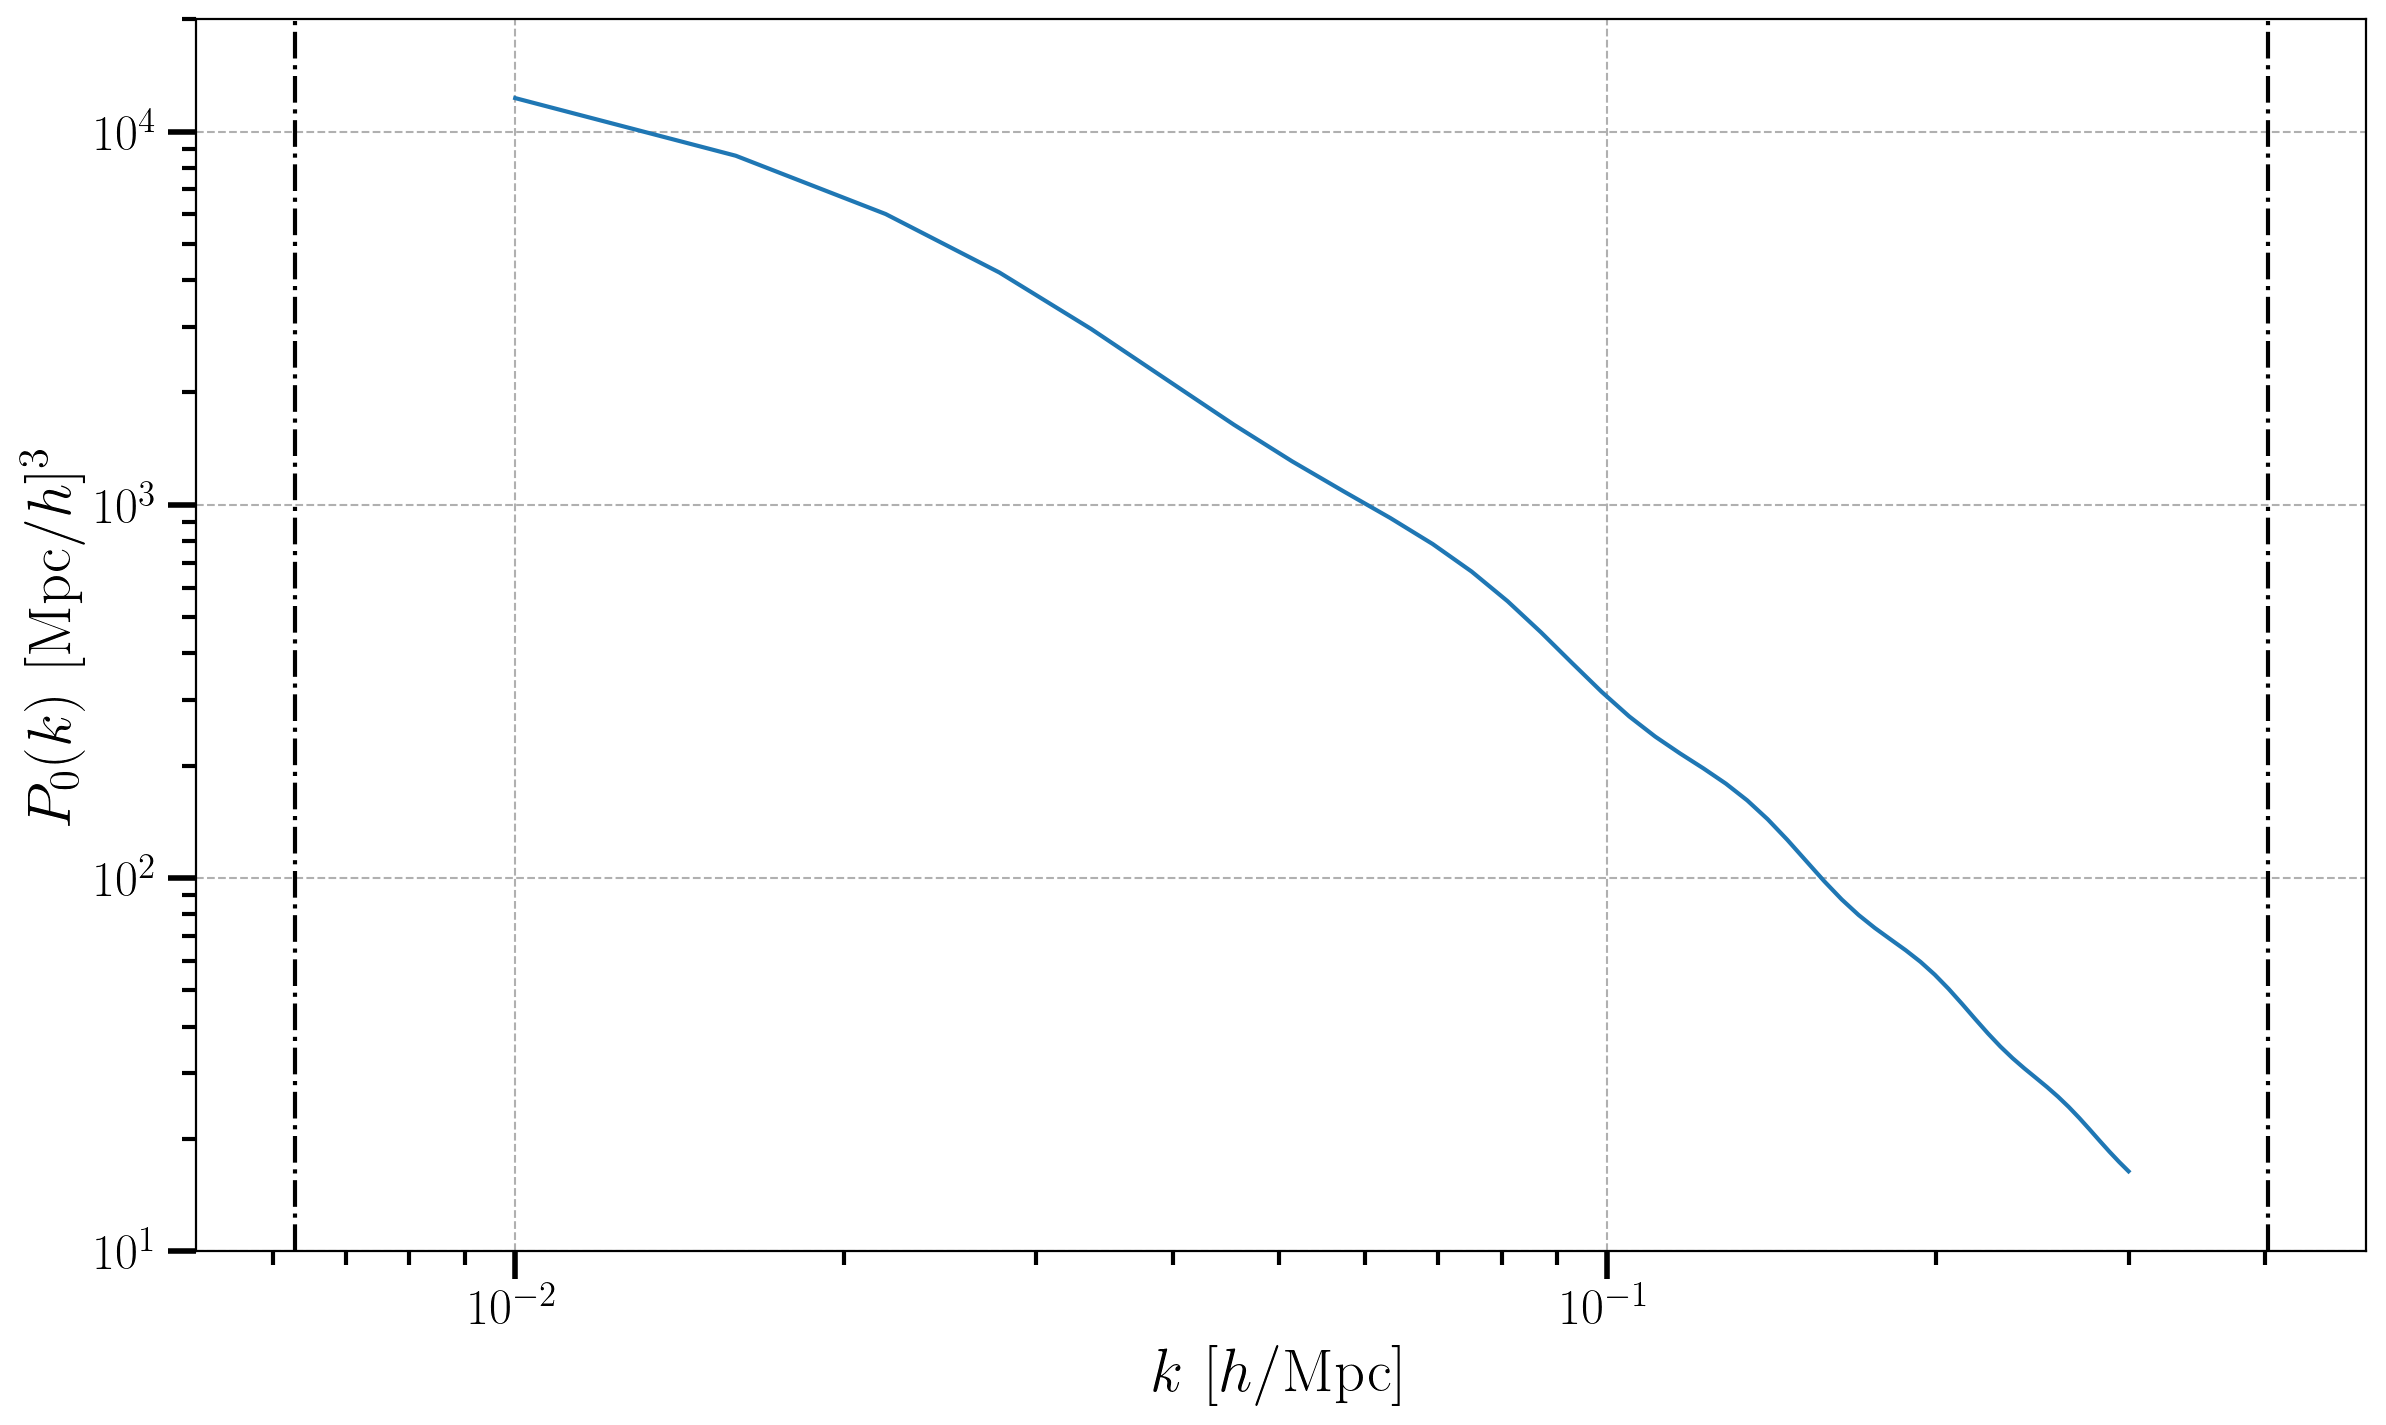

In [87]:
#lets plot covariances #  l11
plt.figure(figsize=(14,8))

k_plot = np.linspace(1e-2,3e-1)
# define covariance
cov = pk.COV(cosmo_funcs,k_plot,zz=0)

delta_k = 2*s *grid_info[5]
N_k = 4*np.pi*k_plot**2 *delta_k

plt.plot(k_plot,np.sqrt((grid_info[5]**3/(N_k))*np.abs(cov.N11().real)))

plt.errorbar(k_est,np.abs(Pk_std['PP']['l=1,t=0'].real),yerr=Pk_err['PP']['l=1,t=0'],fmt='o',color='blue')

plt.axvline(x = grid_info[5], linestyle = '-.', color = 'black')
plt.axvline(x = grid_info[6], linestyle = '-.', color = 'black')

plt.ylim(1e+1,2e+4)
plt.xlabel('$k\,\,[h/\mathrm{Mpc}]$')
plt.ylabel('$ P_{0}(k)\,\,[\mathrm{Mpc}/h]^3$')

plt.xscale('log')
plt.yscale('log')
plt.grid(ls='--',lw=0.75)
plt.show()

In [84]:
Pk_std['PP']['l=1,t=0'].real

array([2.4492334e-04, 1.2039956e-04, 5.5347940e-05, 3.1087693e-05,
       2.1967306e-05, 1.4019396e-05, 9.3596627e-06, 7.2218691e-06,
       5.4895959e-06, 4.1975663e-06, 3.3398344e-06, 2.4400617e-06,
       1.9442339e-06, 1.5739066e-06, 1.3315889e-06, 1.1540442e-06,
       9.2862888e-07, 8.7696577e-07, 7.5461645e-07, 6.0876147e-07,
       4.8959708e-07, 4.2929540e-07, 4.2166471e-07, 4.0328928e-07,
       3.2593397e-07, 3.0706877e-07, 2.7572705e-07, 2.1584719e-07,
       2.5078793e-07, 2.2740610e-07, 2.1112766e-07, 7.1047097e-01],
      dtype=float32)

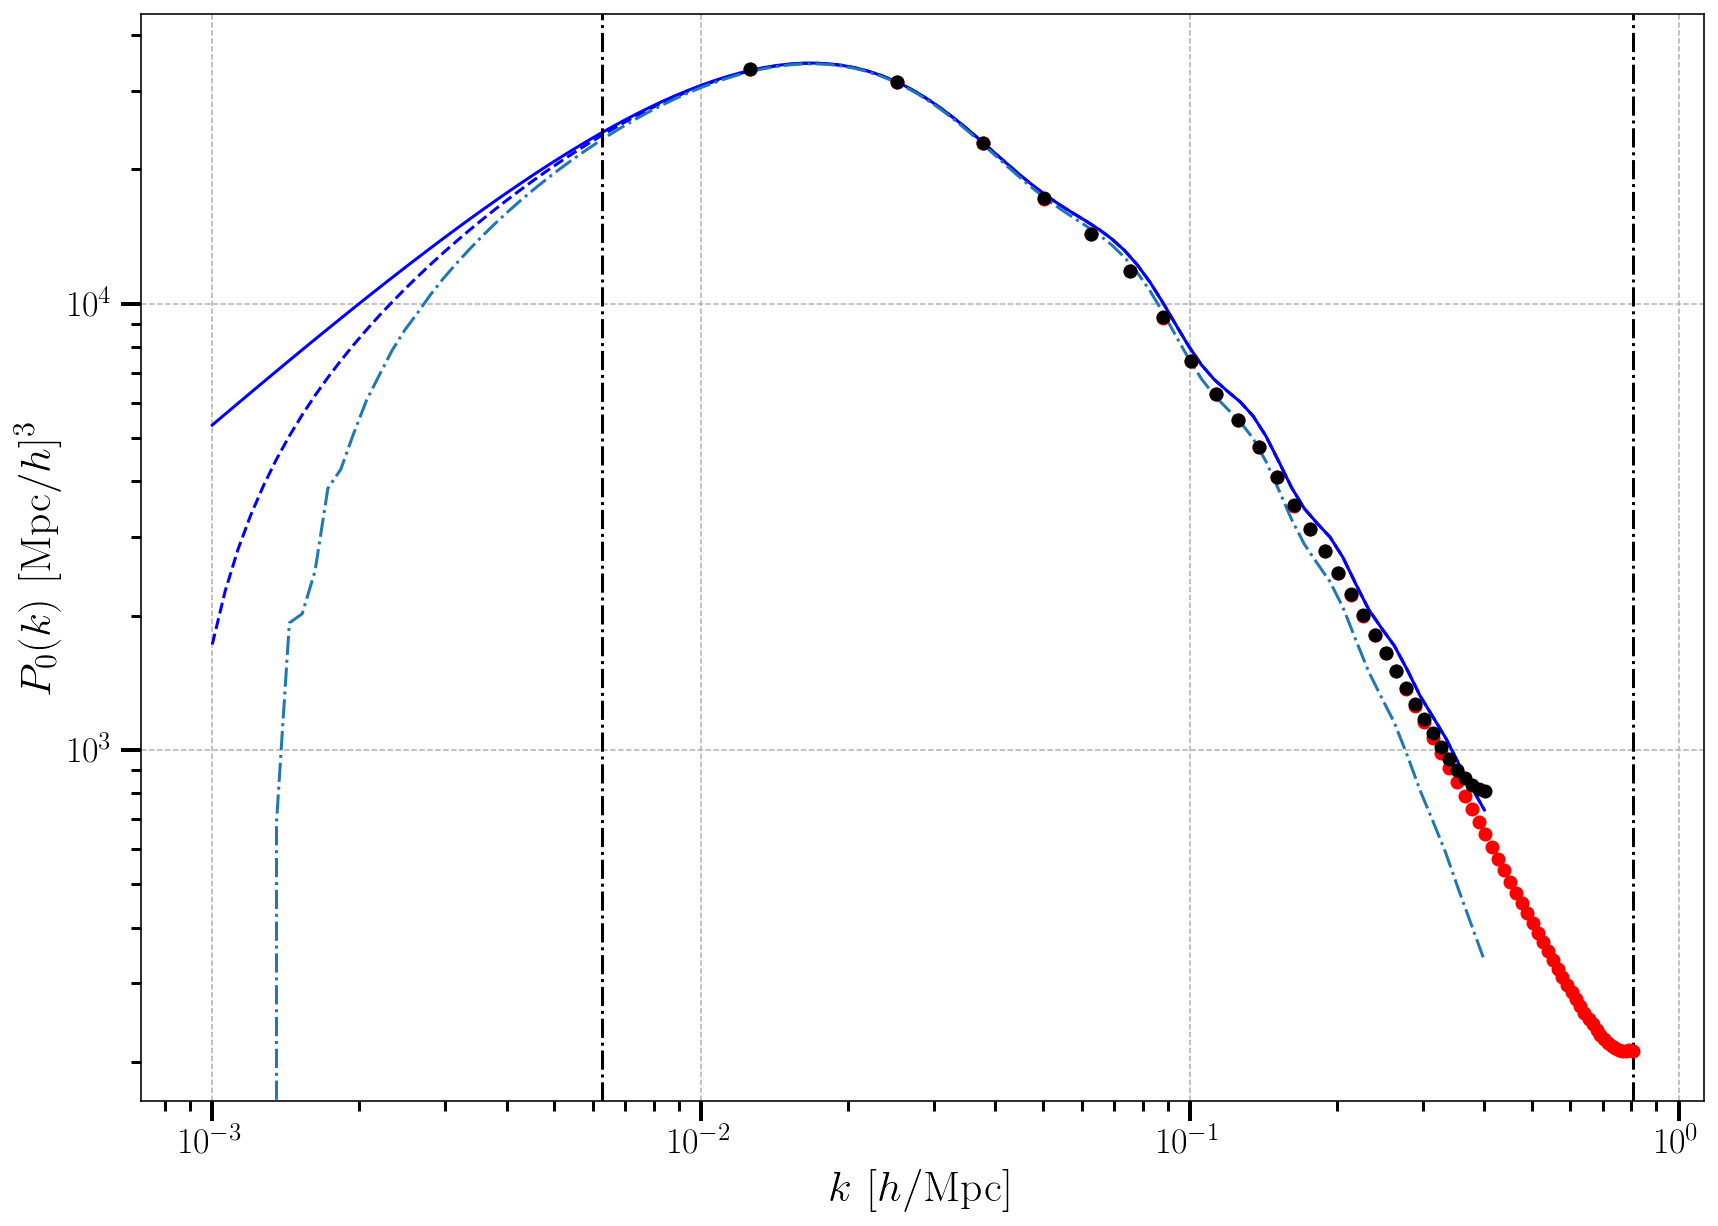

In [638]:
#monopole!!!
plt.figure(figsize=(14,10))

#plt.errorbar(k_est,np.abs(Pk_avg['0']['l=0'].real),yerr=Pk_err['0']['l=0'],fmt ='o',color='blue')
#
#plt.errorbar(k_est,(Pk_avg['PP']['l=0'].real),yerr=Pk_err['PP']['l=0'],fmt ='o',color='orange')

plt.loglog(ks,Pl0_pp,'-',color='blue')
plt.loglog(ks,Pl0_pp+Pk_l0_wa,'--',color='blue')
plt.plot(ks,pk_mono_dfog(ks,4)+pk_mono_dfog_wa(ks,4,430,0),'-.')

plt.axvline(x = grid_info[5], linestyle='-.', color = 'black')
plt.axvline(x = grid_info[6], linestyle='-.', color = 'black')
#plt.xlim(5e-3,0.5e0)
#plt.ylim(3e+3,5e+4)
plt.xlabel('$k\,\,[h/\mathrm{Mpc}]$')
plt.ylabel('$ P_{0}(k)\,\,[\mathrm{Mpc}/h]^3$')

plt.xscale('log')
plt.yscale('log')

plt.grid(ls='--',lw=0.75)
plt.savefig("P_0_pp_comp.png",bbox_inches='tight')#

In [1092]:
print(k_est)

[0.01256637 0.02513274 0.03769911 0.05026548 0.06283185 0.07539822
 0.08796459 0.10053096 0.11309734 0.12566371 0.13823008 0.15079645
 0.16336282 0.17592919 0.18849556 0.20106193 0.2136283  0.22619467
 0.23876104 0.25132741 0.26389378 0.27646015 0.28902652 0.30159289
 0.31415927 0.32672564 0.33929201 0.35185838 0.36442475 0.37699112
 0.38955749 0.40212386]


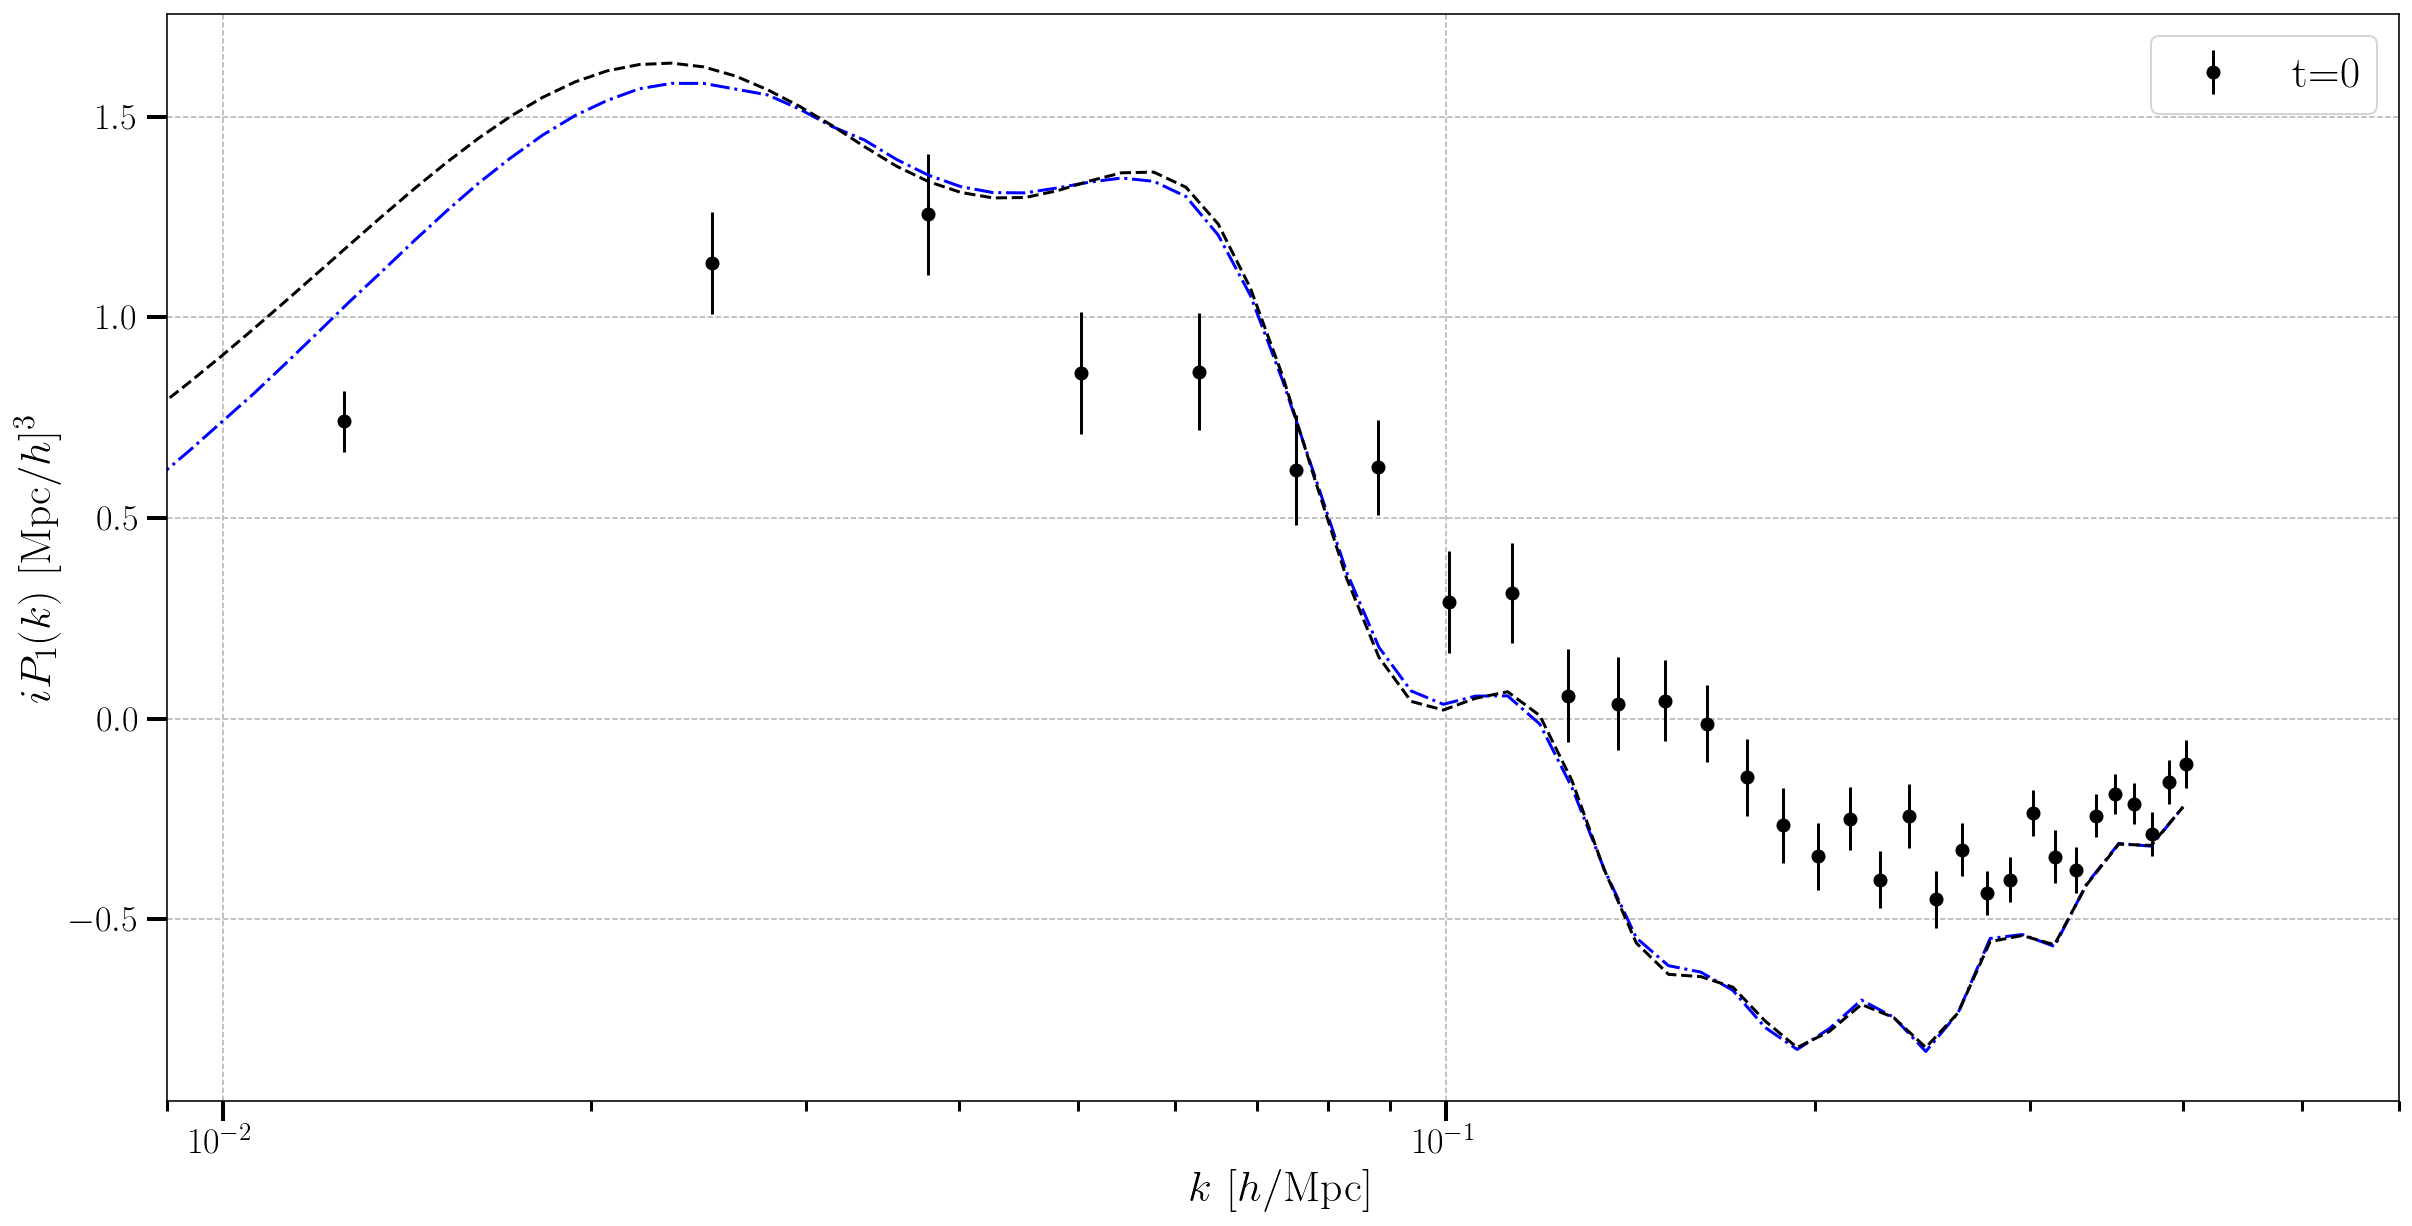

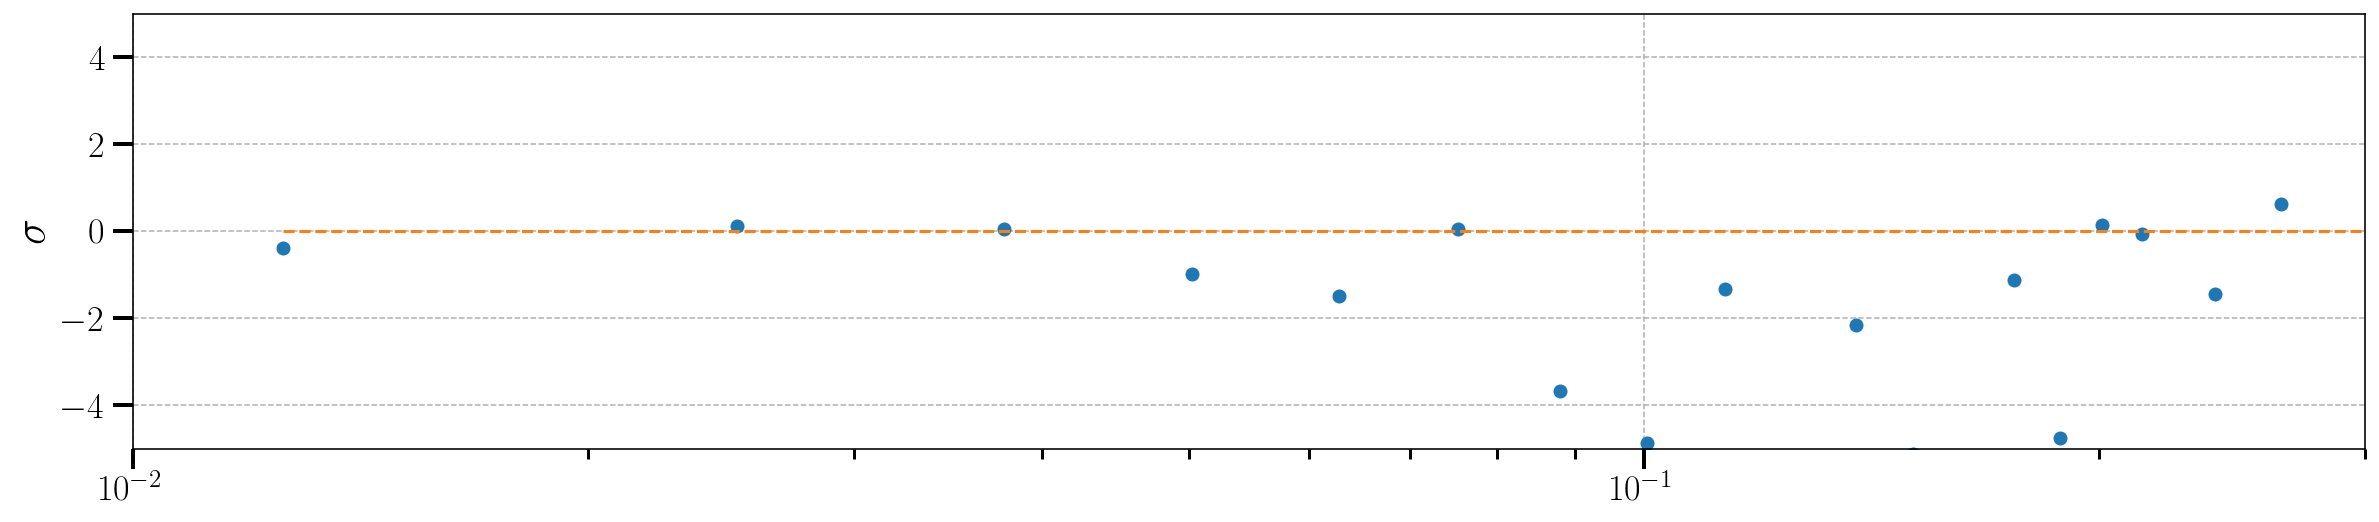

In [1117]:
#dipole!!!
plt.figure(figsize=(20,10))
key ='Cen'

plt.errorbar(k_est,- k_est**2 *(Pk_avg[key]['l=1,t=0'].imag),yerr=k_est**2 *Pk_err[key]['l=1,t=0'],fmt ='o',linestyle='none',color='black',label='t=0')
#plt.errorbar(k_est,(Pk_avg1[key]['l=1,t=5'].imag),yerr=Pk_err1[key]['l=1,t=5'],fmt ='o',linestyle='none',color='red',alpha=1)
#plt.errorbar(k_est,(Pk_avg1[key]['l=1,t=1'].imag),yerr=Pk_err1[key]['l=1,t=1'],fmt ='o',linestyle='none',color='red',label='t=1, 1st order')
#plt.errorbar(k_est,(Pk_avg2[key]['l=1,t=1'].imag),yerr=Pk_err2[key]['l=1,t=1'],fmt ='o',linestyle='none',color='green',label='t=1, 2nd order')


for i in range(400):
    plt.plot(k_est,-(pk['0']['l=1,t=0'][i].imag),'.',alpha=0.6,color='grey')

plt.plot(ks, -ks**2 *(pk_dipo_dfog_wa(ks,5.3,420,0).imag+pk_dipo_3(ks,250,0).imag),color='blue',linestyle='-.')
plt.plot(ks, -ks**2 *(pk_dipo_dfog_wa(ks,5.3,420,0).imag),color='black',linestyle='--')

plt.axvline(x = grid_info[5], linestyle = '-.', color = 'black')
plt.axvline(x = grid_info[6], linestyle = '-.', color = 'black')
plt.xlim(9e-3,0.6e0)
#plt.ylim(-1e+2,1e+4)
plt.xlabel('$k\,\,[h/\mathrm{Mpc}]$')
plt.ylabel('$i P_{1}(k)\,\,[\mathrm{Mpc}/h]^3$')
#plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.grid(ls='--',lw=0.75)
plt.show()
plt.figure(figsize=(20,4))
plt.plot(k_est,((np.abs(Pk_avg[key]['l=1,t=0'])-np.abs(Pk_avg2[key]['l=1,t=1']))/Pk_err[key]['l=1,t=0']),'o')
plt.xscale('log')
plt.grid(ls='--',lw=0.75)
plt.ylabel('$\sigma$')
plt.xlim(1e-2,0.3e0)
plt.ylim(-5,5)
plt.plot(k_est,np.zeros_like(k_est),'--')
#plt.savefig("P_0_pp_comp.png",bbox_inches='tight')#

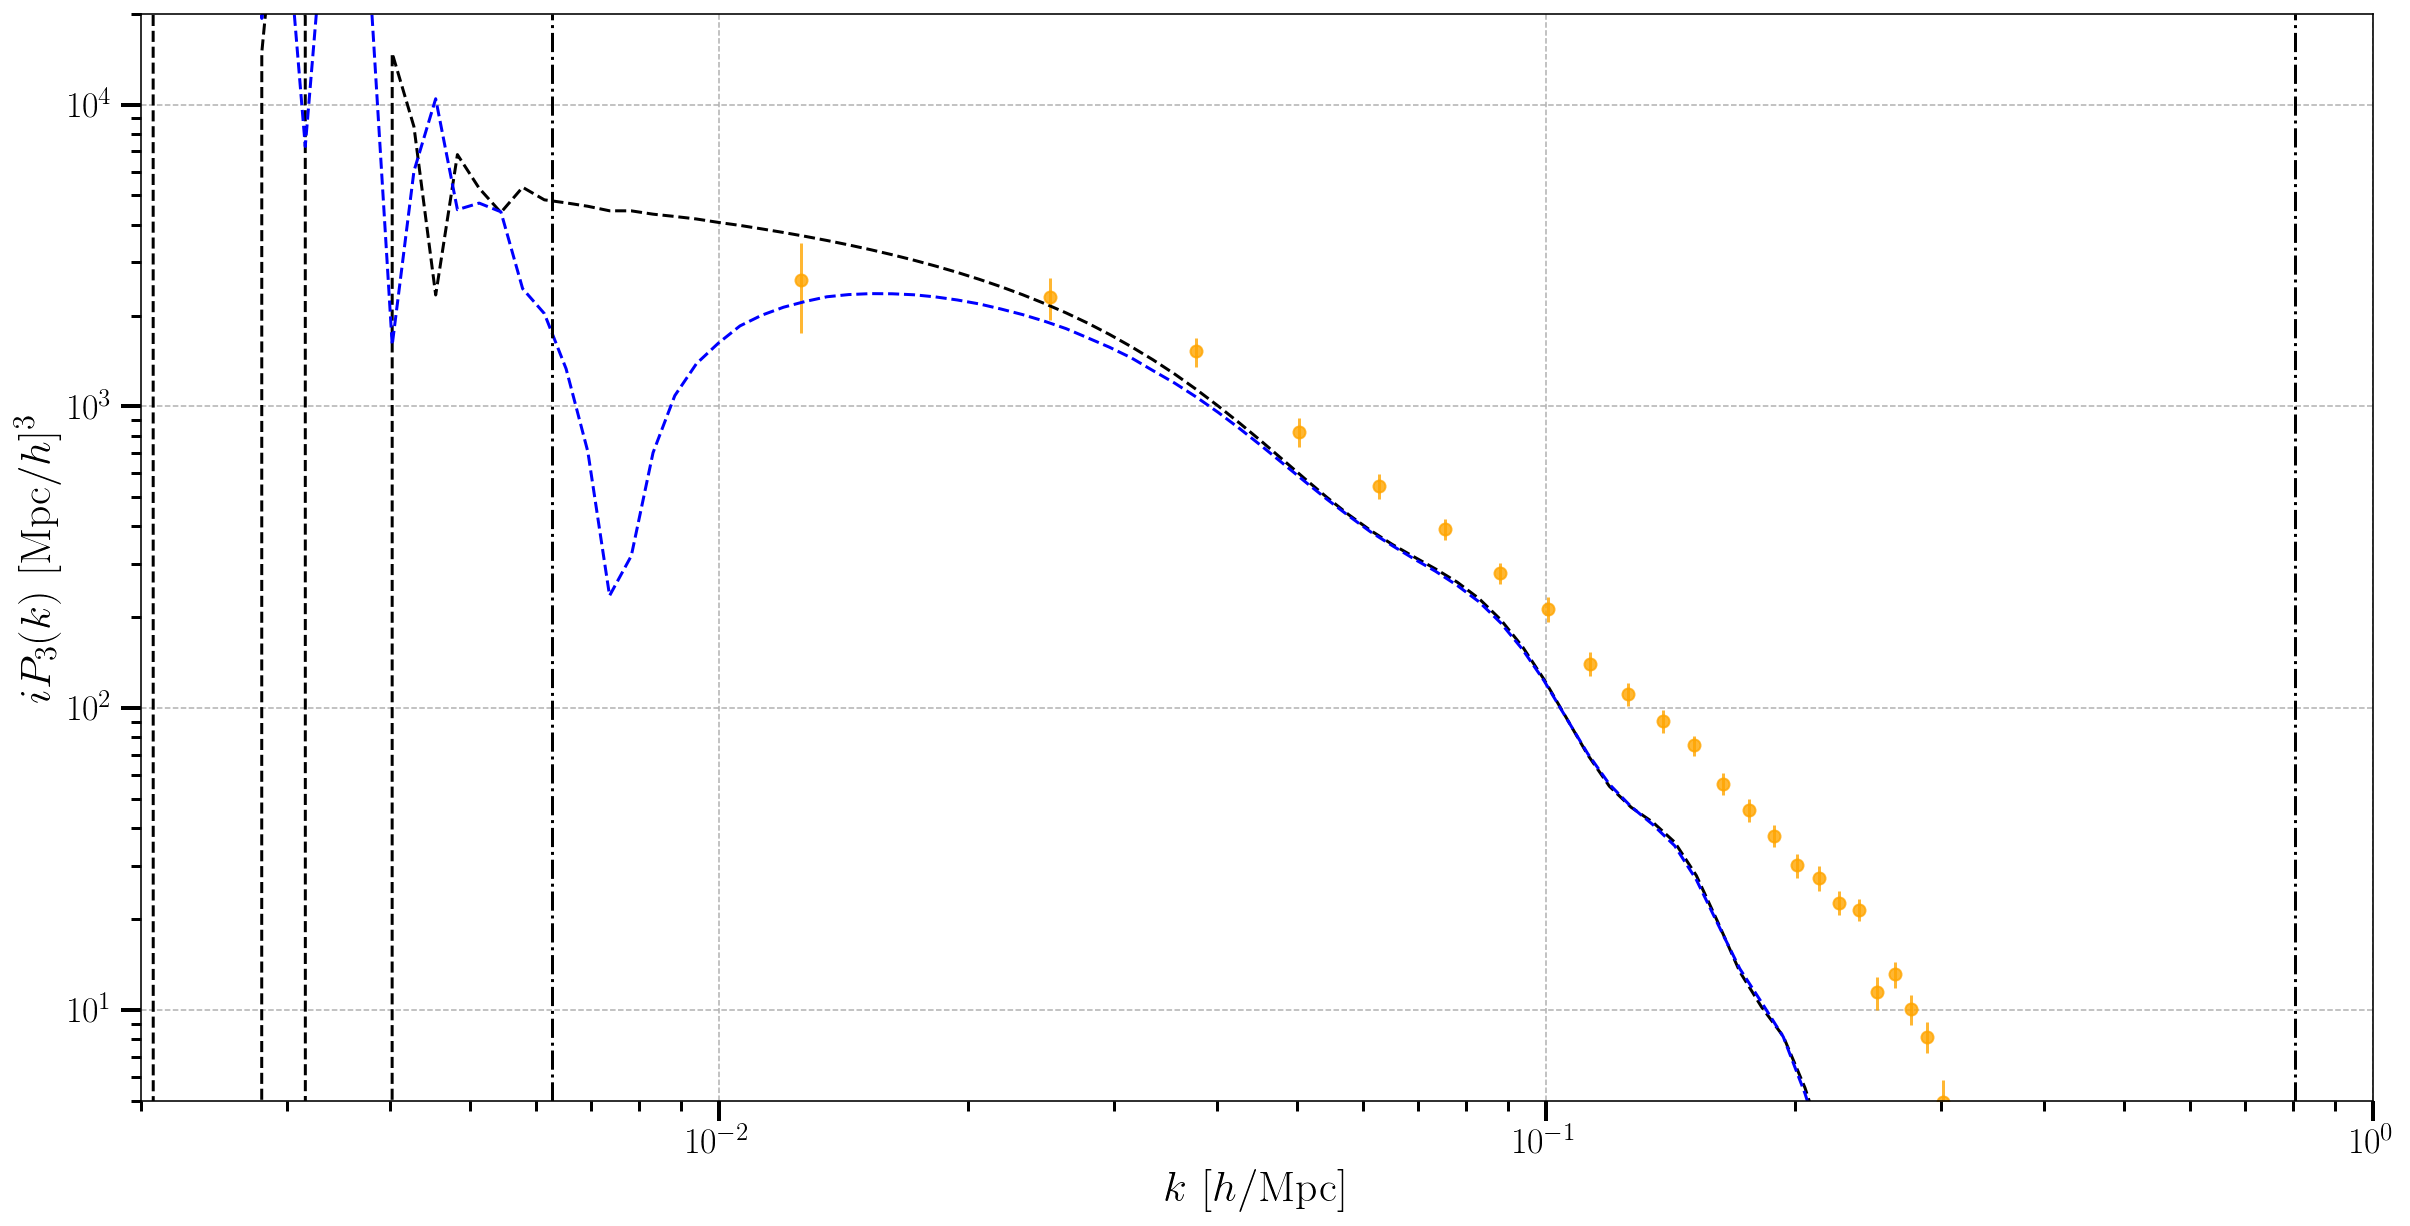

In [1063]:
#octupole!!!
plt.figure(figsize=(20,10))

key1 = '-100'
plt.errorbar(k_est,-(Pk_avg[key1]['l=3,t=0']).imag,yerr=Pk_err[key1]['l=3,t=0'],fmt ='o',linestyle='none',color='orange',alpha=0.8)

for i in range(100):
    1#plt.plot(k_est,-(pk['0']['l=1,t=0'][i].imag),'.',alpha=0.6,color='grey')

#plt.plot(ks,-(pk_oct(ks,d,0).imag+pk_octo_3(ks,d,0).imag),color='blue',linestyle='--')
plt.plot(ks,-(pk_octo_dfog_wa(ks,5.3,640,0).imag),color='black',linestyle='--')
plt.plot(ks,np.abs(pk_octo_dfog_wa(ks,5.3,640,0).imag+pk_octo_3(ks,520,0).imag),color='blue',linestyle='--')

plt.axvline(x = grid_info[5], linestyle = '-.', color = 'black')
plt.axvline(x = grid_info[6], linestyle = '-.', color = 'black')
plt.xlim(2e-3,1e0)
plt.ylim(0.5e+1,2e+4)
plt.xlabel('$k\,\,[h/\mathrm{Mpc}]$')
plt.ylabel('$i P_{3}(k)\,\,[\mathrm{Mpc}/h]^3$')

plt.yscale('log')
plt.xscale('log')
plt.grid(ls='--',lw=0.75)
plt.savefig("P_0_pp_comp.png",bbox_inches='tight')#

In [985]:
print(pk['PP'].keys())

dict_keys(['l=1,t=0'])


In [1051]:
def slice_realisations(key,key1,low,high):
    temp_arr = 1*pk[key][key1]
    pk1[key][key1] = temp_arr[low:high]#this the way to change without chopping og
    print(pk1[key][key1].shape)
    return avg_err(pk1)

Pk_avg1,Pk_err1,Pk_std1 = slice_realisations('PP','l=2,t=0',0,400)
Pk_avg2,Pk_err2,Pk_std2 = slice_realisations('0','l=2,t=0',350,400)
print(pk['PP']['l=2,t=0'].shape)


(400, 32)
(50, 32)
(500, 32)


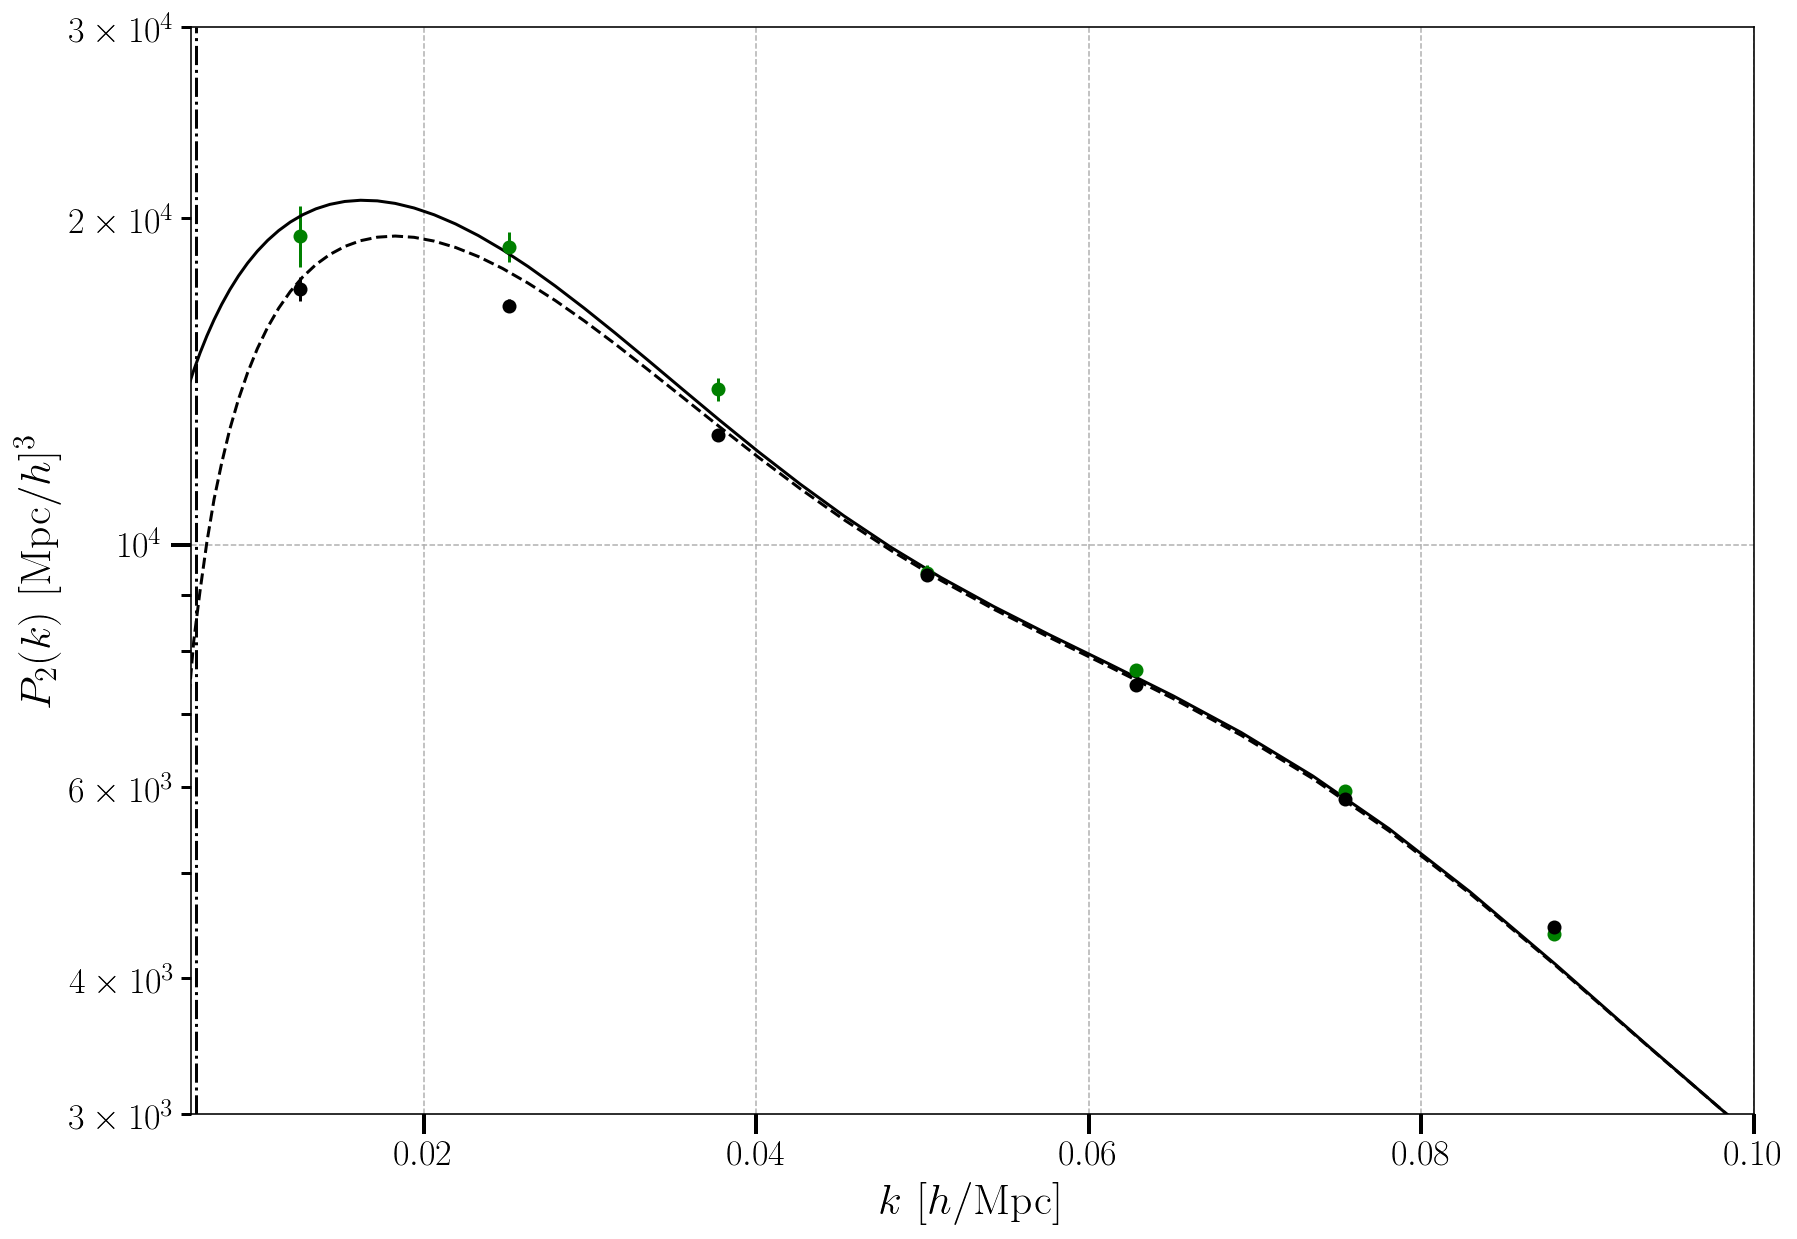

In [1128]:
#quadrupole
plt.figure(figsize=(14,10))

plt.errorbar(k_est,np.abs(Pk_avg['PP']['l=2,t=0'].real),yerr=Pk_err['PP']['l=2,t=0'],fmt ='o',color='green')
#plt.errorbar(k_est1,np.abs(Pk_avg1['PP']['l=2,t=0'].real),yerr=Pk_err1['PP']['l=2,t=0'],fmt ='o',color='red')
plt.errorbar(k_est,np.abs(Pk_avg['0']['l=2,t=0'].real),yerr=Pk_err['0']['l=2,t=0'],fmt ='o',color='black')

#plt.errorbar(k_est,(Pk_avg['0']['l=2,t=0'].real),yerr=Pk_err['0']['l=2,t=0'],fmt ='o',color='black')

plt.plot(ks, pk_quad_dfog(ks,5.3),color='black')
plt.plot(ks, pk_quad_dfog(ks,5.3)+pk_quad_dfog_wa(ks,5.3,500,0),color='black',linestyle='--')
#
#plt.loglog(ks,Pl2_pp,'--',color='black')
for i in range(100):
    1#plt.loglog(k_est,(np.abs(pk_500['l=2,t=5'][i].real)),'.',alpha=0.2,color='blue')
    1#plt.loglog(k_est,(np.abs(pk_500['l=2,t=0'][i].real)),'.',alpha=0.2,color='red')


plt.axvline(x = grid_info[5], linestyle='-.', color = 'black')
plt.axvline(x = grid_info[6], linestyle='-.', color = 'black')
plt.xlim(6e-3,0.1e0)
plt.ylim(3e+3,3e+4)
plt.xlabel('$k\,\,[h/\mathrm{Mpc}]$')
plt.ylabel('$P_{2}(k)\,\,[\mathrm{Mpc}/h]^3$')
#plt.xscale('log')
plt.yscale('log')

plt.grid(ls='--',lw=0.75)
#plt.savefig("P_0_pp_comp.png",bbox_inches='tight')

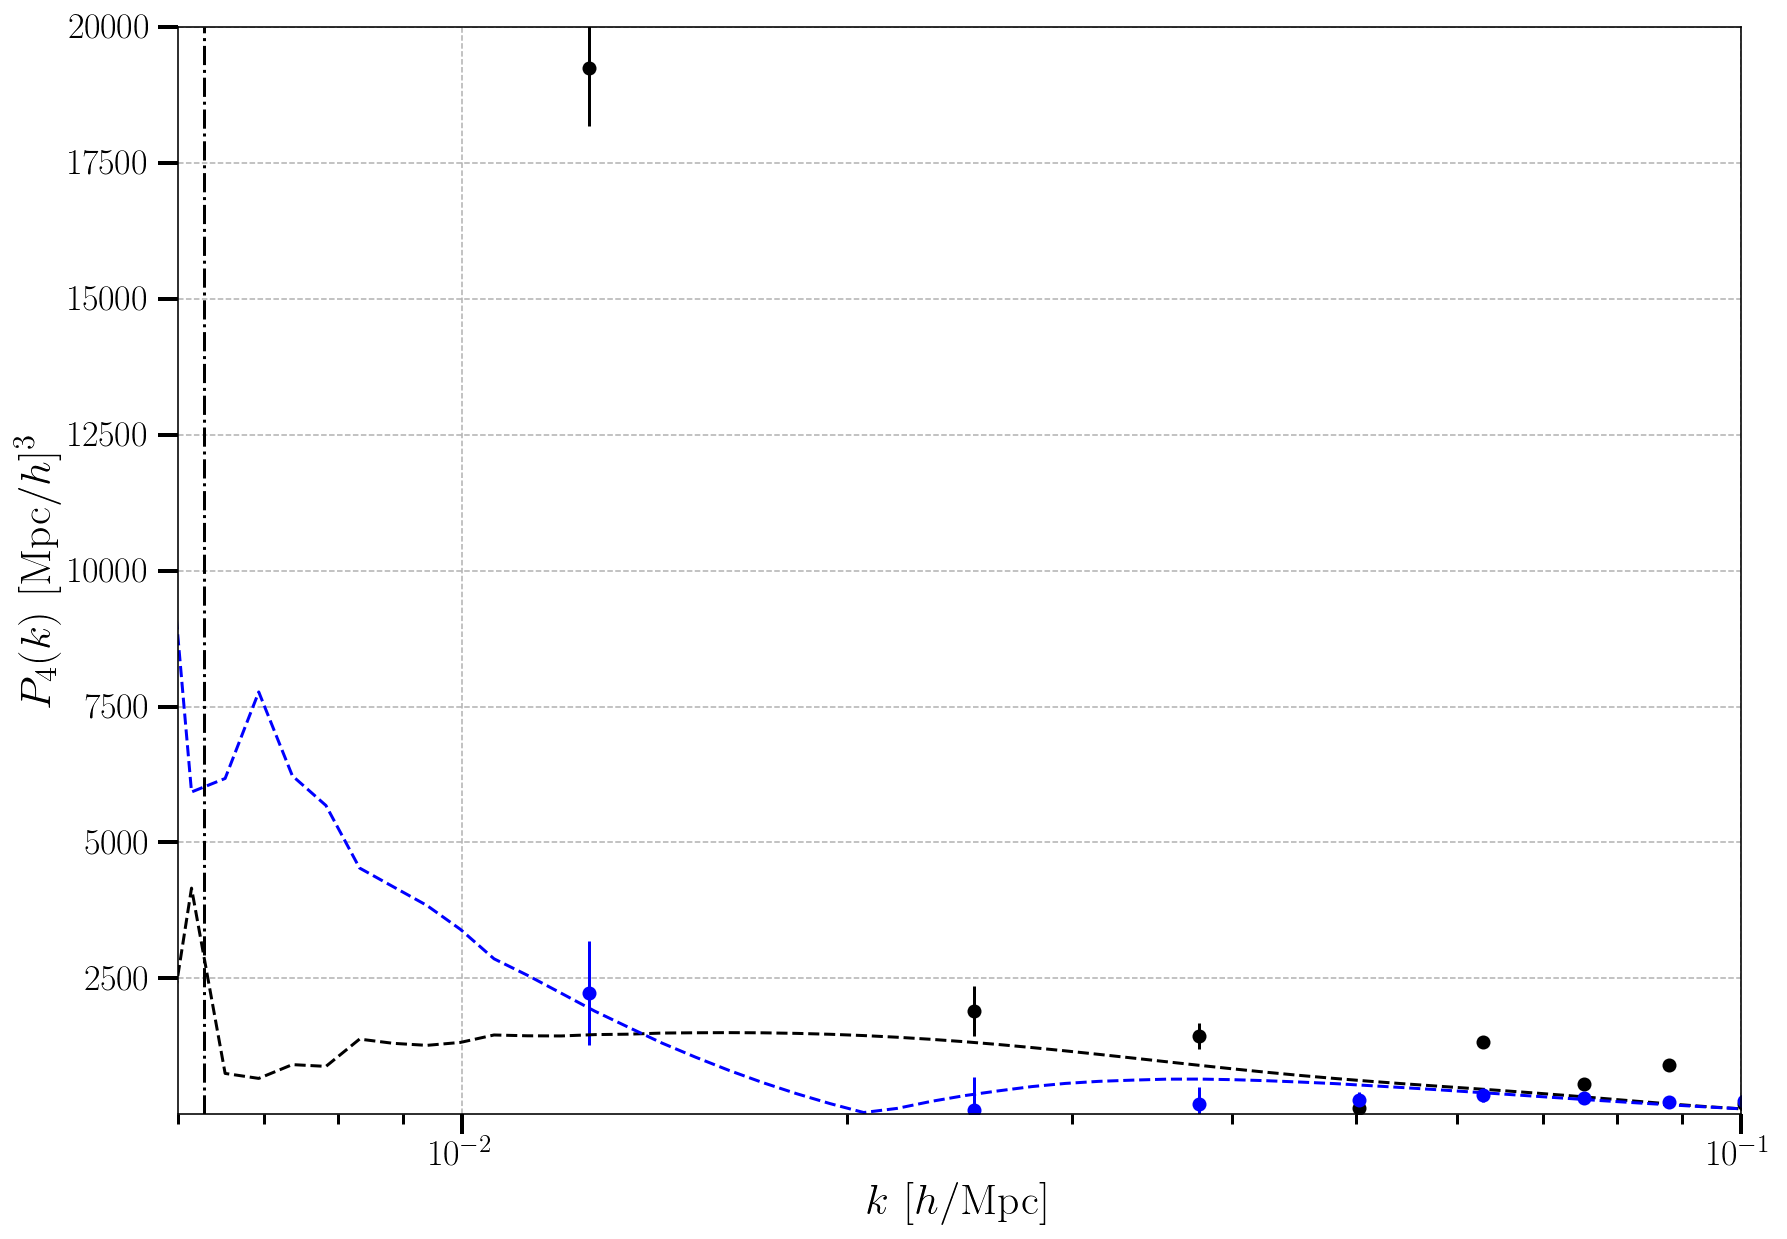

In [589]:
#hexadecapole
plt.figure(figsize=(14,10))

plt.errorbar(k_est,np.abs(Pk_avg['PP']['l=4,t=0'].real),yerr=Pk_err['PP']['l=4,t=0'],fmt ='o',color='black')
#plt.errorbar(k_est,np.abs(Pk_avg['-1000']['l=4,t=0'].real),yerr=Pk_err['-1000']['l=4,t=0'],fmt ='o',color='red')
plt.errorbar(k_est,np.abs(Pk_avg['Cen']['l=4,t=0'].real),yerr=Pk_err['Cen']['l=4,t=0'],fmt ='o',color='blue')

sigma=4
#plt.plot(ks, Pl4_pp,color='black')
plt.plot(ks, np.abs(pk_hexa_dfog(ks,sigma)),linestyle='--',color='black')
plt.plot(ks, np.abs(pk_hexa_dfog(ks,sigma)+pk_quad_dfog_wa(ks,sigma,430,0)),linestyle='--',color='blue')
#plt.loglog(ks,Pl2_pp,'--',color='black')
for i in range(100):
    1#plt.plot(k_est,-(pk['PP']['l=4,t=0'][i].real),'.',alpha=0.2,color='blue')
    1#plt.plot(k_est,(np.abs(pk_500['l=2,t=0'][i].real)),'.',alpha=0.2,color='red')


plt.axvline(x = grid_info[5], linestyle='-.', color = 'black')
plt.axvline(x = grid_info[6], linestyle='-.', color = 'black')
plt.xlim(6e-3,0.1e0)
plt.ylim(1e+1,2e+4)
plt.xlabel('$k\,\,[h/\mathrm{Mpc}]$')
plt.ylabel('$ P_{4}(k)\,\,[\mathrm{Mpc}/h]^3$')

plt.xscale('log')
#plt.yscale('log')

plt.grid(ls='--',lw=0.75)
#plt.savefig("P_0_pp_comp.png",bbox_inches='tight')

In [48]:
%%time
import sys
sys.path.append('/home/addis/Pylians3/library/build/lib.linux-x86_64-3.8')
import Pk_library as PKL
BoxSize = 1000.0 #Mpc/h
axis    = 2
MAS     = 'CIC'
threads = 4
realisation = str(10002)
field_tmp = np.load(path + 'fields_CIC/' + realisation + '_' + red_info + '_' + str(N_side) + '_LOS=PP' +'.npy')
Pk_py = PKL.Pk(np.array(field_tmp,dtype=np.float32), L, axis, MAS, threads, True)


Computing power spectrum of the field...
Time to complete loop = 0.11
Time taken = 0.13 seconds
CPU times: user 175 ms, sys: 6.7 ms, total: 182 ms
Wall time: 137 ms


In [49]:
k_py   = Pk_py.k3D
Pk0     = Pk_py.Pk[:,0] #monopole
Pk2     = Pk_py.Pk[:,1] #quadrupole
Pk4     = Pk_py.Pk[:,2] #hexadecapole

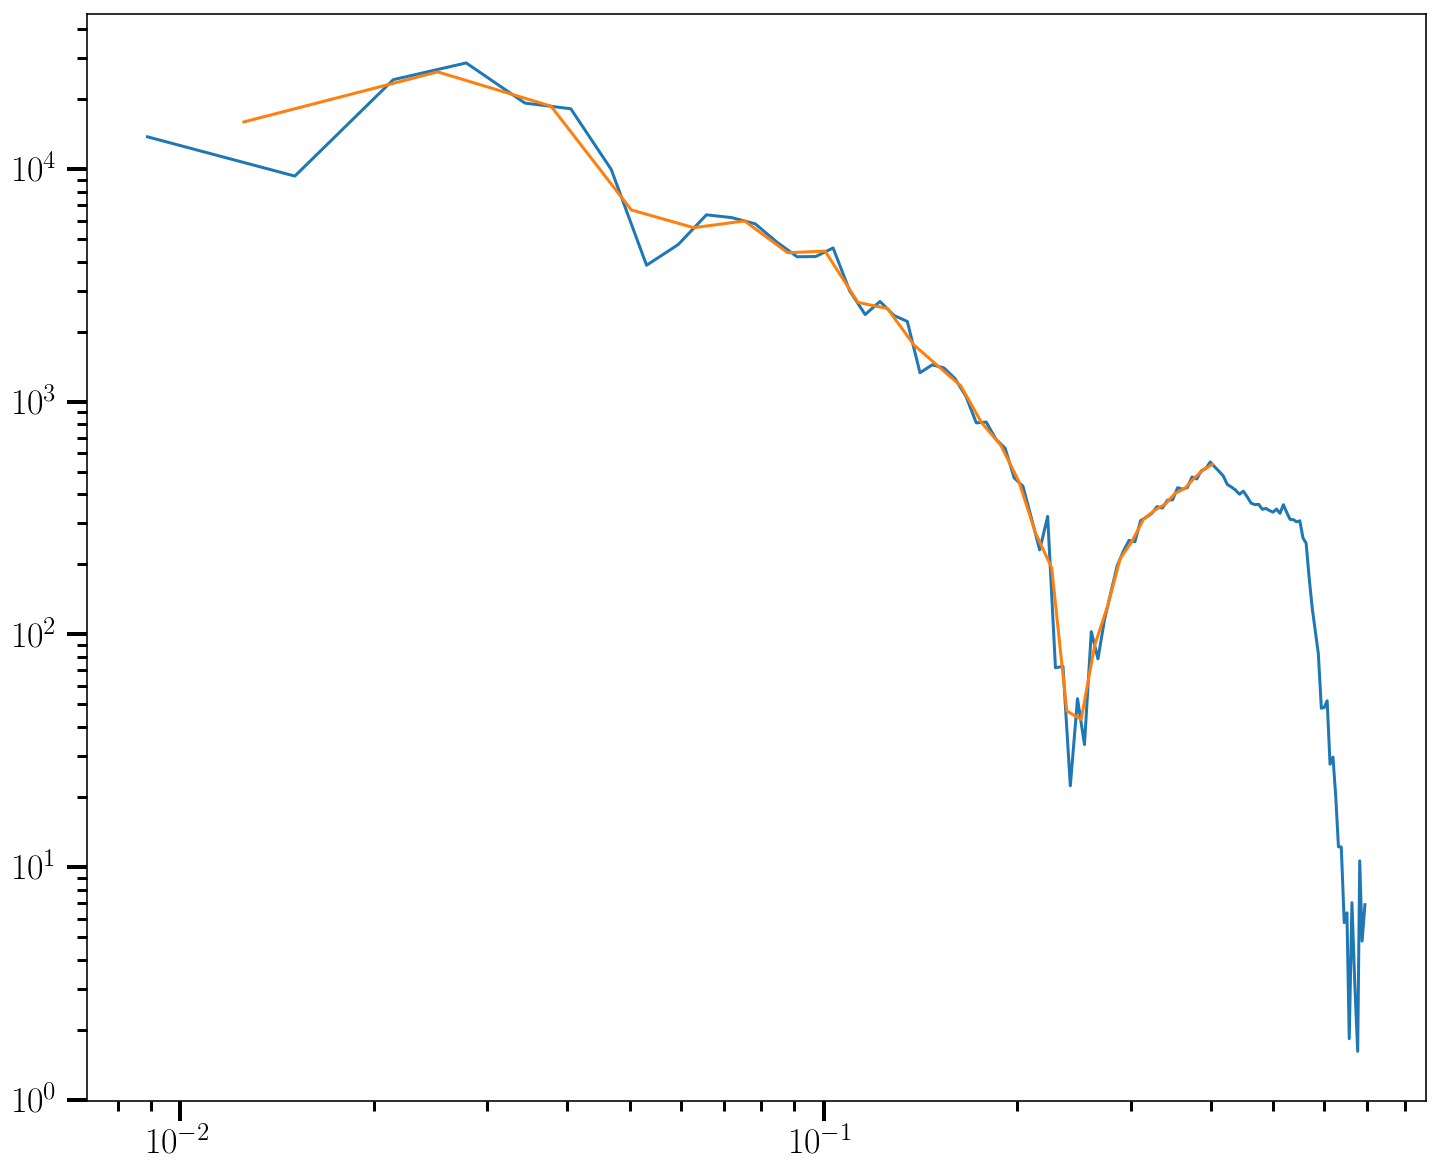

In [51]:
#pylians comparison
plt.figure(figsize=(12,10))
plt.loglog(k_py,np.abs(Pk2))
plt.loglog(k_est,np.abs(pk['PP']['l=2,t=0'][2].real))

In [138]:
from classy import Class

#Start by specifying the cosmology - fiducial quijote...
Omega_b = 0.049#0.05
Omega_m = 0.3175
Omega_l = 0.682
Omega_cdm = Omega_m - Omega_b
h = 0.6711#0.7 #H0/100
A_s = 2.1e-9
n_s = 0.9624
a = 1/(1+z)
H  = 100.0*np.sqrt(Omega_m*(1.0+z)**3+Omega_l)*a #Value of H(z) in km/s/(Mpc/h)

#Create a params dictionary
#Need to specify the max wavenumber
k_max = 10 #UNITS: 1/Mpc

params = {   'output':'mPk',
             'non linear':'halofit',
             'Omega_b':Omega_b,
             'Omega_cdm':Omega_cdm,
             'h':h,
             'A_s':A_s,
             'n_s':n_s,
             'P_k_max_1/Mpc':k_max,
             'z_max_pk':10. #Default value is 10
}
#Initialize the cosmology and compute everything
cosmo = Class()
cosmo.set(params)
cosmo.compute()

#Specify k and z
k = np.logspace(-5, np.log10(k_max), num=50000) #Mpc^-1
#z already specififed

#Call these for the nonlinear and linear matter power spectra
Pnonlin = np.array([cosmo.pk(ki, z) for ki in k])
Plin = np.array([cosmo.pk_lin(ki, z) for ki in k])

#NOTE: You will need to convert these to h/Mpc and (Mpc/h)^3
#to use in the toolkit. To do this you would do:
k /= h
Plin *= h**3
Pnonlin *= h**3

In [174]:
#ok so set a comoving distance of observation
#d = comoving_dist(z)
#set z ...
def get_class_powerspectrum(kk,zz): #h are needed to convert to 1/Mpc for k then convert pk back to (Mpc/h)^3
     
    return np.array([cosmo.pk_lin(ki, zz) for ki in kk*h])*h**3

def get_pkinfo_z(k,z):
    Plin = get_class_powerspectrum(k,z)
    Pk = interpolate.interp1d(k,Plin)#Plin
    Pk_d = interpolate.interp1d(k,np.gradient(Plin,k))#(k[1:]+k[:-1])/2,np.diff(Plin)/np.diff(k)
    Pk_dd = interpolate.interp1d(k,np.gradient(Pk_d(k),k))
    Pk_ddd = interpolate.interp1d(k,np.gradient(Pk_dd(k),k))
    return Pk,Pk_d,Pk_dd,Pk_ddd

#so set parameters...
z=1
Pk_,Pk_d,Pk_dd,Pk_ddd = get_pkinfo_z(k,z)


In [148]:
# Lambda CDM
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy import interpolate
LCDM = Class()
LCDM.compute()
print(LCDM.get_current_derived_parameters)
baLCDM = LCDM.get_background()
print(baLCDM.keys())
f_cl = baLCDM['gr.fac. f']
z_cl = baLCDM['z']
H_cl = baLCDM['H [1/Mpc]'];H = interp1d(z_cl,H_cl*(1/(1+z_cl))/h,kind='cubic') # now in h/Mpc!
xi_cl = baLCDM['comov. dist.']; comoving_dist = interp1d(z_cl,xi_cl*h,kind='cubic') # just use class background as quick
f_intp = interp1d(z_cl,f_cl,kind='cubic')#get f #omega_mz = Omega_m *(1+zt)**3 /(Omega_m *(1+zt)**3 + Omega_l)

<built-in method get_current_derived_parameters of classy.Class object at 0x556b92809790>
dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])


In [186]:

z=1
ks = np.geomspace(1e-3,4e-1,100)
f = f_intp(z)

Pks = Pk_(ks)
Pkd= Pk_d(ks)
Pkdd= Pk_dd(ks)

d=cosmo_funcs.comoving_dist(z)
b1 = 1.5
t=1/2

In [187]:

survey_params = cw.survey_params.SurveyParams(cosmo)

#so now we can compute terms for this cosmology and for euclid-likes biases
#cosmo_funcs = cw.ClassWAP(cosmo,[survey_params.Euclid],compute_bias=True)
survey_params.DM_part.b_1 = lambda xx: 1.5 + 0*xx
cosmo_funcs = cw.ClassWAP(cosmo,[survey_params.DM_part])

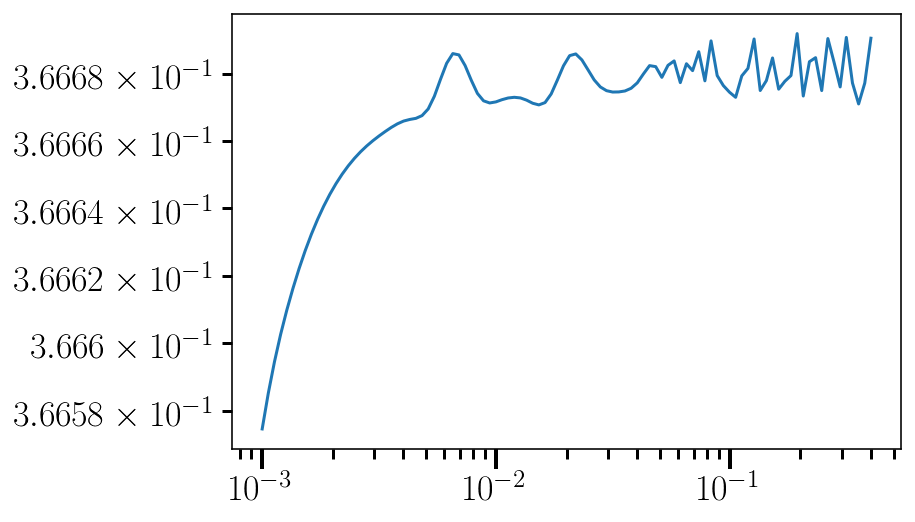

In [179]:
plt.loglog(ks,cosmo_funcs.D_intp(z)**2 *np.abs(Pl0_pp)/pk.Pk0.l0(cosmo_funcs,ks,z,t))

(0.003, 0.1)

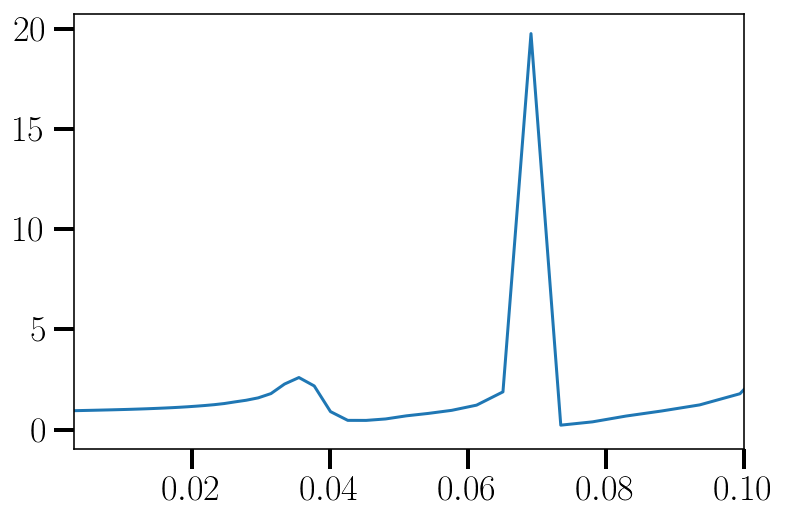

In [192]:
plt.plot(ks,np.abs(pk.WA2.l0(cosmo_funcs,ks,zz=1,t=1/2))/np.abs(Pk_l0_wa))
plt.xlim(0.003,0.1)

(0.003, 0.1)

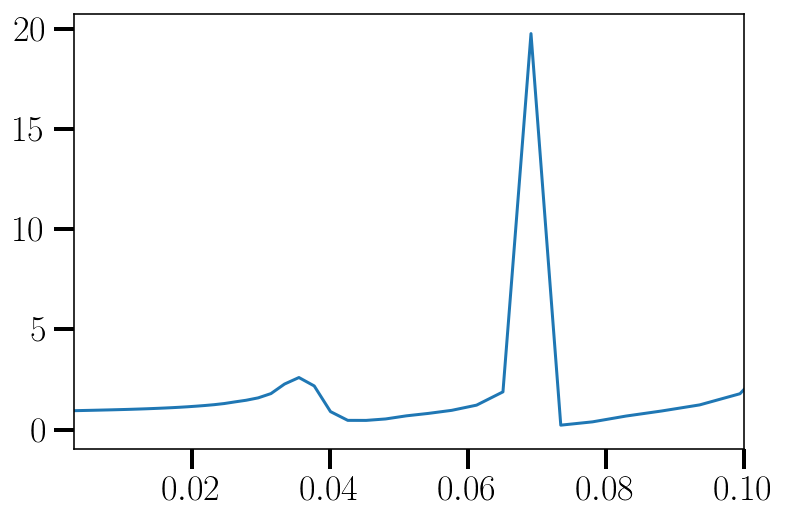

In [193]:
plt.plot(ks,np.abs(pk.WA2.l0(cosmo_funcs,ks,z,t))/np.abs(Pk_l0_wa))
#plt.loglog(ks,np.abs(pk.WA2.l0(cosmo_funcs,ks,z,t)))
plt.xlim(0.003,0.1)

(1e-06, 0.1)

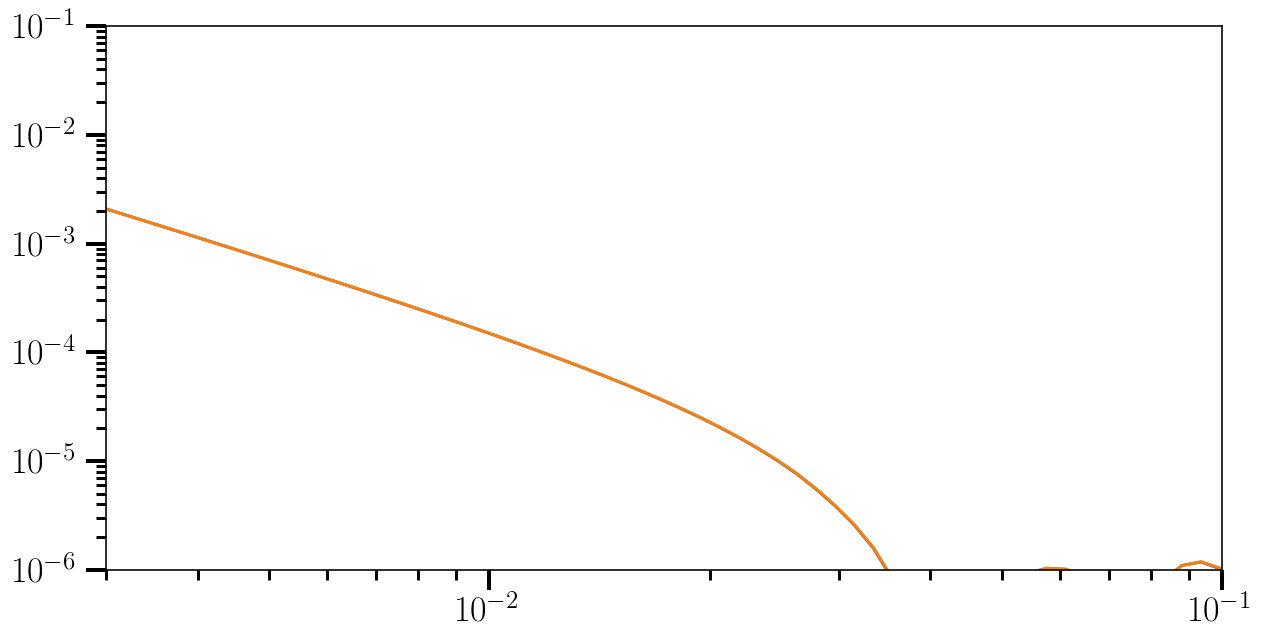

In [197]:
plt.figure(figsize=(10,5))
plt.loglog(ks,np.abs(Pk_l0_wa)/np.abs(Pl0_pp))
plt.loglog(ks,np.abs(pk.WA2.l0(cosmo_funcs,ks,zz=1,t=1/2))/np.abs(Pl0_pp))
plt.xlim(0.003,0.1)
plt.ylim(1e-6,1e-1)

In [196]:
s=2/5
Pk_l0_wa = f*(Pks*(7*b1*(-25*s - t*(12*t - 12) + 4) + f*(175*s - t*(36*t - 36) - 68)) + ks*(Pkd*(-35*b1*(5*s + t*(4*t - 4)) + f*(175*s - t*(60*t - 60) - 48)) - 2*Pkdd*ks*(7*b1*(t*(2*t - 2) + 1) + f*(t*(6*t - 6) - 5))))/(105*d**2*ks**2)
Pk_l1_wa = -4*f*(3*Pks+ Pkd*ks)*(7*b1 + 3*f)*(2*t - 1)/(35*d*ks)
Pk_l2_wa = 2*f*(-Pks*(2*b1*(70*s + t*(66*t - 66) + 5) + f*(-35*s + t*(108*t - 108) + 40)) + ks*(Pkd*(b1*(70*s + t*(44*t - 44) - 6) + f*(35*s - t*(12*t - 12) - 6)) + Pkdd*ks*(11*b1 + 3*f)*(t*(2*t - 2) + 1)))/(21*d**2*ks**2)
Pk_l3_wa = -4*1j*f*(2*t - 1)*(Pkd*ks*(9*b1 + f) - Pks*(18*b1 + 22*f))/(45*d*ks)

def pk_oct(ks,d,t):
    Pks= Pk_(ks)
    Pkd= Pk_d(ks)
    return -4*1j*f*(2*t - 1)*(Pkd*ks*(9*b1 + f) - Pks*(18*b1 + 22*f))/(45*d*ks)

Pl0_pp = b1**2 *Pks+ (2*b1*f*Pks)/3 + (f**2 *Pks)/5
Pl2_pp = (4*b1*f*Pks)/3 + (4*f**2 *Pks)/7
Pl4_pp = (8*f**2 *Pks)/35

In [14]:
#these are some multipoles without inverse distance terms
Pk_l0_wa1 = 2*f*(Pks*(-21*b1*(t*(2*t - 2) + 1) - 18*f*t*(t - 1) + f) + ks*(Pkd*(-35*b1*(t*(2*t - 2) + 1) + f*(-t*(30*t - 30) + 11)) + Pkdd*ks*(-7*b1*(t*(2*t - 2) + 1) + f*(-t*(6*t - 6) + 5))))/(105*d**2*ks**2)
Pk_l2_wa1 = 2*f*(-2*Pks*(33*b1*(t*(2*t - 2) + 1) + f*(t*(54*t - 54) + 13)) + ks*(2*Pkd*(22*b1*t*(t - 1) + 11*b1 - 6*f*t*(t - 1) + 4*f) + Pkdd*ks*(11*b1 + 3*f)*(t*(2*t - 2) + 1)))/(21*d**2*ks**2)


NameError: name 'f' is not defined

In [15]:
#plt.loglog(ks,Pl0_pp,color='blue')
#plt.loglog(ks,Pl0_pp+Pk_l0_wa,'--',color='blue')
#plt.loglog(ks,Pl0_pp+Pk_l0_wa1,'-.',color='blue')
plt.loglog(ks,Pl2_pp,color='red')
plt.loglog(ks,Pl2_pp+Pk_l2_wa,'--',color='red')
plt.loglog(ks,Pl2_pp+Pk_l2_wa1,'-.',color='red')
#plt.loglog(ks,Pk_l1_wa)

NameError: name 'ks' is not defined

In [16]:
plt.plot(ks,Pk_l1_wa,color='red')
plt.plot(ks,-Pk_l3_wa.imag,color='blue')
plt.xscale('log')
plt.yscale('log')

NameError: name 'ks' is not defined

In [47]:
import scipy 

In [906]:
#3rd order parts
def pk_dipo_3(kk,d,t):
    Pks = Pk_(kk)
    Pkd = Pk_d(kk)
    Pkdd = Pk_dd(kk)
    Pkddd = Pk_ddd(kk)
    
    return -1j*f*(2*t - 1)*(2*Pkddd*kk**3*(-12*b1*(t*(t - 1) + 1) + f*(-t*(109*t - 109) + 4)) + 48*Pks*(3*b1*(t*(t - 1) + 1) + 2*f*t*(t - 1)) + 12*kk*(Pkd*(4*b1*(t*(t - 1) + 1) + f*(-t*(97*t - 97) - 4)) + Pkdd*kk*(-10*b1*(t*(t - 1) + 1) - 107*f*t*(t - 1))))/(105*d**3*kk**3)

def pk_octo_3(kk,d,t):
    Pks = Pk_(kk)
    Pkd = Pk_d(kk)
    Pkdd = Pk_dd(kk)
    Pkddd = Pk_ddd(kk)
    return -8*1j*f*(2*t - 1)*(Pkddd*kk**3*(77*b1*(t*(t - 1) + 1) + 3*f*(t*(3*t - 3) + 7)) + 24*Pks*(77*b1*(t*(t - 1) + 1) + 93*f*t*(t - 1) + 30*f) + 3*kk*(-Pkd*(308*b1*(t*(t - 1) + 1) + 9*f*(t*(4*t - 4) + 13)) + Pkdd*f*kk*(-t*(56*t - 56) + 5)))/(495*d**3*kk**3)

def pk_octo_dfog_3(kk,sigma,d,t):
    Pks = Pk_(kk)
    Pkd = Pk_d(kk)
    Pkdd = Pk_dd(kk)
    Pkddd = Pk_ddd(kk)
    return -7*1j*np.exp(-kk**2*sigma**2)*f*(2*t - 1)*(-8*Pks*(8*b1*kk**3*sigma**3*(t**2 - t + 1)*(20*kk**6*sigma**6 + 173*kk**4*sigma**4 + 735*kk**2*sigma**2 + 3150) - 3*np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(-4*b1*kk**2*sigma**2*(t**2 - t + 1)*(6*kk**6*sigma**6 - 81*kk**4*sigma**4 + 455*kk**2*sigma**2 - 1050) + f*(16*kk**8*sigma**8 - 520*kk**6*sigma**6 + 5780*kk**4*sigma**4 - 32130*kk**2*sigma**2 + t**2*(24*kk**8*sigma**8 - 924*kk**6*sigma**6 + 10890*kk**4*sigma**4 - 62685*kk**2*sigma**2 + 151200) - t*(24*kk**8*sigma**8 - 924*kk**6*sigma**6 + 10890*kk**4*sigma**4 - 62685*kk**2*sigma**2 + 151200) + 75600)) + 2*f*kk*sigma*(128*kk**8*sigma**8 + 1576*kk**6*sigma**6 + 13560*kk**4*sigma**4 + 54810*kk**2*sigma**2 + t**2*(288*kk**8*sigma**8 + 3420*kk**6*sigma**6 + 28260*kk**4*sigma**4 + 114345*kk**2*sigma**2 + 453600) - t*(288*kk**8*sigma**8 + 3420*kk**6*sigma**6 + 28260*kk**4*sigma**4 + 114345*kk**2*sigma**2 + 453600) + 226800)) + kk*(2*Pkd*(4*b1*kk**3*sigma**3*(t**2 - t + 1)*(96*kk**6*sigma**6 + 892*kk**4*sigma**4 + 3780*kk**2*sigma**2 + 17325) - 3*np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(-2*b1*kk**2*sigma**2*(t**2 - t + 1)*(40*kk**6*sigma**6 - 484*kk**4*sigma**4 + 2590*kk**2*sigma**2 - 5775) + f*(40*kk**8*sigma**8 - 1048*kk**6*sigma**6 + 10970*kk**4*sigma**4 - 59220*kk**2*sigma**2 + t**2*(48*kk**8*sigma**8 - 2064*kk**6*sigma**6 + 22410*kk**4*sigma**4 - 120015*kk**2*sigma**2 + 274050) - t*(48*kk**8*sigma**8 - 2064*kk**6*sigma**6 + 22410*kk**4*sigma**4 - 120015*kk**2*sigma**2 + 274050) + 137025)) + 2*f*kk*sigma*(224*kk**8*sigma**8 + 2740*kk**6*sigma**6 + 24090*kk**4*sigma**4 + 96390*kk**2*sigma**2 + t**2*(432*kk**8*sigma**8 + 5256*kk**6*sigma**6 + 46440*kk**4*sigma**4 + 188055*kk**2*sigma**2 + 822150) - t*(432*kk**8*sigma**8 + 5256*kk**6*sigma**6 + 46440*kk**4*sigma**4 + 188055*kk**2*sigma**2 + 822150) + 411075)) + kk*(2*Pkdd*(3*np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(-2*b1*kk**2*sigma**2*(t**2 - t + 1)*(16*kk**6*sigma**6 - 160*kk**4*sigma**4 + 770*kk**2*sigma**2 - 1575) + f*(8*kk**8*sigma**8 - 200*kk**6*sigma**6 + 2010*kk**4*sigma**4 - 10500*kk**2*sigma**2 + t**2*(48*kk**8*sigma**8 - 576*kk**6*sigma**6 + 4690*kk**4*sigma**4 - 22575*kk**2*sigma**2 + 47250) + t*(-48*kk**8*sigma**8 + 576*kk**6*sigma**6 - 4690*kk**4*sigma**4 + 22575*kk**2*sigma**2 - 47250) + 23625)) - 2*kk*sigma*(2*b1*kk**2*sigma**2*(t**2 - t + 1)*(16*kk**6*sigma**6 + 200*kk**4*sigma**4 + 840*kk**2*sigma**2 + 4725) + f*(32*kk**8*sigma**8 + 420*kk**6*sigma**6 + 3930*kk**4*sigma**4 + 15750*kk**2*sigma**2 + t**2*(-16*kk**8*sigma**8 + 392*kk**6*sigma**6 + 6720*kk**4*sigma**4 + 26775*kk**2*sigma**2 + 141750) + t*(16*kk**8*sigma**8 - 392*kk**6*sigma**6 - 6720*kk**4*sigma**4 - 26775*kk**2*sigma**2 - 141750) + 70875))) + Pkddd*kk*(56*b1*kk**3*sigma**3*(t**2 - t + 1)*(2*kk**4*sigma**4 + 5*kk**2*sigma**2 + 75) + 3*np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(4*b1*kk**2*sigma**2*(t**2 - t + 1)*(4*kk**6*sigma**6 - 28*kk**4*sigma**4 + 105*kk**2*sigma**2 - 175) + f*(24*kk**6*sigma**6 - 280*kk**4*sigma**4 + 1470*kk**2*sigma**2 + t**2*(96*kk**6*sigma**6 - 850*kk**4*sigma**4 + 3465*kk**2*sigma**2 - 6300) + t*(-96*kk**6*sigma**6 + 850*kk**4*sigma**4 - 3465*kk**2*sigma**2 + 6300) - 3150)) + 2*f*kk*sigma*(32*kk**6*sigma**6 + 420*kk**4*sigma**4 + 1890*kk**2*sigma**2 + t**2*(16*kk**8*sigma**8 + 80*kk**6*sigma**6 + 660*kk**4*sigma**4 + 2205*kk**2*sigma**2 + 18900) - t*(16*kk**8*sigma**8 + 80*kk**6*sigma**6 + 660*kk**4*sigma**4 + 2205*kk**2*sigma**2 + 18900) + 9450)))))/(32*d**3*kk**14*sigma**11)


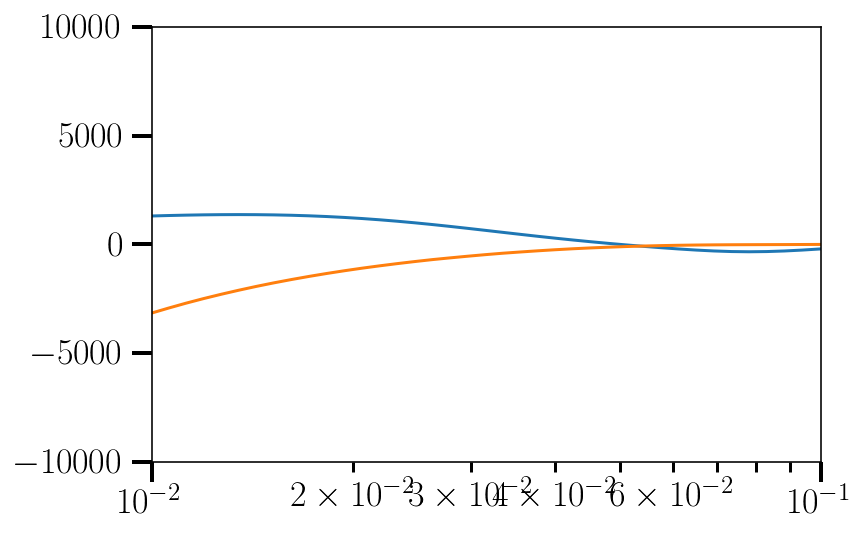

In [1122]:
#PP functions with Dfog
def pk_mono_dfog(kk,sigma):
    Pks = Pk_(kk)
    return Pks*np.exp(-kk**2*sigma**2)*(np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(4*b1**2*kk**4*sigma**4 + 4*b1*f*kk**2*sigma**2 + 3*f**2) - 6*f**2*kk*sigma - 4*f*kk**3*sigma**3*(2*b1 + f))/(8*kk**5*sigma**5)  
    
def pk_mono_dfog_wa(kk,sigma,d,t):
    Pks = Pk_(kk)
    Pkd= Pk_d(kk)
    Pkdd= Pk_dd(kk)
    return np.exp(-kk**2*sigma**2)*(8*Pks*(8*b1**2*kk**9*sigma**9*(4*t**2 - 4*t - 1) + 4*b1*f*kk**3*sigma**3*(-4*kk**6*sigma**6 - 14*kk**4*sigma**4 - 33*kk**2*sigma**2 + t**2*(16*kk**6*sigma**6 + 16*kk**4*sigma**4 + 48*kk**2*sigma**2 + 72) - t*(16*kk**6*sigma**6 + 16*kk**4*sigma**4 + 48*kk**2*sigma**2 + 72) - 54) + np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(12*b1**2*kk**8*sigma**8 - 6*b1*f*kk**2*sigma**2*(kk**2*sigma**2 + 24*t**2 - 24*t - 18) + f**2*(7*kk**4*sigma**4 - 153*kk**2*sigma**2 + t**2*(24*kk**2*sigma**2 - 540) + t*(-24*kk**2*sigma**2 + 540) + 765)) + 2*f**2*kk*sigma*(-4*kk**8*sigma**8 - 22*kk**6*sigma**6 - 109*kk**4*sigma**4 - 357*kk**2*sigma**2 + t**2*(16*kk**8*sigma**8 + 32*kk**6*sigma**6 + 128*kk**4*sigma**4 + 336*kk**2*sigma**2 + 540) - t*(16*kk**8*sigma**8 + 32*kk**6*sigma**6 + 128*kk**4*sigma**4 + 336*kk**2*sigma**2 + 540) - 765)) + kk*(Pkd*(-8*b1**2*kk**5*sigma**5*(8*kk**2*sigma**2 + 3)*(4*t**2 - 4*t - 3) + 8*b1*f*kk**3*sigma**3*(24*kk**4*sigma**4 + 76*kk**2*sigma**2 - t**2*(64*kk**4*sigma**4 + 112*kk**2*sigma**2 + 180) + t*(64*kk**4*sigma**4 + 112*kk**2*sigma**2 + 180) + 135) - np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(-12*b1**2*kk**4*sigma**4*(8*kk**4*sigma**4 - 6*kk**2*sigma**2 + t**2*(8*kk**2*sigma**2 + 4) - t*(8*kk**2*sigma**2 + 4) - 3) + 4*b1*f*kk**2*sigma**2*(8*kk**4*sigma**4 - 14*kk**2*sigma**2 + t**2*(8*kk**2*sigma**2 - 180) + t*(-8*kk**2*sigma**2 + 180) + 135) + f**2*(56*kk**4*sigma**4 - 666*kk**2*sigma**2 + t**2*(120*kk**2*sigma**2 - 1620) - t*(120*kk**2*sigma**2 - 1620) + 2295)) + 2*f**2*kk*sigma*(48*kk**6*sigma**6 + 224*kk**4*sigma**4 + 864*kk**2*sigma**2 - t**2*(128*kk**6*sigma**6 + 352*kk**4*sigma**4 + 960*kk**2*sigma**2 + 1620) + t*(128*kk**6*sigma**6 + 352*kk**4*sigma**4 + 960*kk**2*sigma**2 + 1620) + 2295)) + Pkdd*kk*(8*b1**2*kk**5*sigma**5*(2*kk**2*sigma**2 + 12*t**2 - 12*t - 9) + 8*b1*f*kk**3*sigma**3*(-10*kk**2*sigma**2 + t**2*(16*kk**2*sigma**2 + 36) - t*(16*kk**2*sigma**2 + 36) - 27) + np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(4*b1**2*kk**4*sigma**4*(4*kk**4*sigma**4 - 8*kk**2*sigma**2 + t**2*(8*kk**2*sigma**2 - 12) + t*(-8*kk**2*sigma**2 + 12) + 9) - 4*b1*f*kk**2*sigma**2*(4*kk**4*sigma**4 + 8*kk**2*sigma**2 + t**2*(-8*kk**2*sigma**2 + 36) + t*(8*kk**2*sigma**2 - 36) - 27) + f**2*(28*kk**4*sigma**4 - 120*kk**2*sigma**2 + t**2*(24*kk**2*sigma**2 - 180) + t*(-24*kk**2*sigma**2 + 180) + 255)) + 2*f**2*kk*sigma*(-16*kk**4*sigma**4 - 50*kk**2*sigma**2 + t**2*(32*kk**4*sigma**4 + 96*kk**2*sigma**2 + 180) - t*(32*kk**4*sigma**4 + 96*kk**2*sigma**2 + 180) - 255))))/(128*d**2*kk**9*sigma**7)

def pk_quad_dfog(kk,sigma):
    Pks = Pk_(kk)
    return  5*Pks*np.exp(-kk**2*sigma**2)*(-np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(8*b1**2*kk**6*sigma**6 + 4*b1*kk**4*sigma**4*(-3*b1 + 2*f) - 45*f**2 + 6*f*kk**2*sigma**2*(-6*b1 + f)) - 90*f**2*kk*sigma - 24*f*kk**3*sigma**3*(3*b1 + 2*f) - kk**5*sigma**5*(24*b1**2 + 32*b1*f + 16*f**2))/(32*kk**7*sigma**7)

def pk_quad_dfog_wa(kk,sigma,d,t):
    Pks = Pk_(kk)
    Pkd= Pk_d(kk)
    Pkdd= Pk_dd(kk)
    return 5*np.exp(-kk**2*sigma**2)*(8*Pks*(8*b1**2*kk**9*sigma**9*(-4*kk**2*sigma**2 + t**2*(16*kk**2*sigma**2 + 24) - t*(16*kk**2*sigma**2 + 24) - 15) + 4*b1*f*kk**3*sigma**3*(-16*kk**8*sigma**8 - 80*kk**6*sigma**6 - 180*kk**4*sigma**4 - 381*kk**2*sigma**2 + t**2*(64*kk**8*sigma**8 + 160*kk**6*sigma**6 + 912*kk**4*sigma**4 + 2808*kk**2*sigma**2 + 5400) - t*(64*kk**8*sigma**8 + 160*kk**6*sigma**6 + 912*kk**4*sigma**4 + 2808*kk**2*sigma**2 + 5400) - 450) + np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(12*b1**2*kk**8*sigma**8*(-2*kk**2*sigma**2 - 8*t**2 + 8*t + 5) + 6*b1*f*kk**2*sigma**2*(2*kk**4*sigma**4 + 27*kk**2*sigma**2 + t**2*(264*kk**2*sigma**2 - 1800) - t*(264*kk**2*sigma**2 - 1800) + 150) + f**2*(-14*kk**6*sigma**6 + 297*kk**4*sigma**4 - 2385*kk**2*sigma**2 - t**2*(264*kk**4*sigma**4 - 9720*kk**2*sigma**2 + 56700) + t*(264*kk**4*sigma**4 - 9720*kk**2*sigma**2 + 56700) + 12285)) + 2*f**2*kk*sigma*(-16*kk**10*sigma**10 - 112*kk**8*sigma**8 - 484*kk**6*sigma**6 - 1983*kk**4*sigma**4 - 5805*kk**2*sigma**2 + t**2*(64*kk**10*sigma**10 + 224*kk**8*sigma**8 + 1904*kk**6*sigma**6 + 8904*kk**4*sigma**4 + 28080*kk**2*sigma**2 + 56700) - t*(64*kk**10*sigma**10 + 224*kk**8*sigma**8 + 1904*kk**6*sigma**6 + 8904*kk**4*sigma**4 + 28080*kk**2*sigma**2 + 56700) - 12285)) + kk*(Pkd*(8*b1**2*kk**5*sigma**5*(24*kk**4*sigma**4 + 138*kk**2*sigma**2 - t**2*(128*kk**4*sigma**4 + 984*kk**2*sigma**2 + 540) + t*(128*kk**4*sigma**4 + 984*kk**2*sigma**2 + 540) + 45) - 8*b1*f*kk**3*sigma**3*(-96*kk**6*sigma**6 - 328*kk**4*sigma**4 - 858*kk**2*sigma**2 + t**2*(256*kk**6*sigma**6 + 1792*kk**4*sigma**4 + 6264*kk**2*sigma**2 + 13500) - t*(256*kk**6*sigma**6 + 1792*kk**4*sigma**4 + 6264*kk**2*sigma**2 + 13500) - 1125) + np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(-12*b1**2*kk**4*sigma**4*(16*kk**6*sigma**6 - 20*kk**4*sigma**4 + 36*kk**2*sigma**2 + t**2*(144*kk**4*sigma**4 - 208*kk**2*sigma**2 - 180) - t*(144*kk**4*sigma**4 - 208*kk**2*sigma**2 - 180) + 15) + 4*b1*f*kk**2*sigma**2*(16*kk**6*sigma**6 + 44*kk**4*sigma**4 - 108*kk**2*sigma**2 + t**2*(16*kk**4*sigma**4 - 2736*kk**2*sigma**2 + 13500) - t*(16*kk**4*sigma**4 - 2736*kk**2*sigma**2 + 13500) - 1125) + f**2*(112*kk**6*sigma**6 - 1548*kk**4*sigma**4 + 10620*kk**2*sigma**2 + t**2*(1392*kk**4*sigma**4 - 36720*kk**2*sigma**2 + 170100) - t*(1392*kk**4*sigma**4 - 36720*kk**2*sigma**2 + 170100) - 36855)) + 2*f**2*kk*sigma*(192*kk**8*sigma**8 + 896*kk**6*sigma**6 + 4296*kk**4*sigma**4 + 13950*kk**2*sigma**2 - t**2*(512*kk**8*sigma**8 + 4096*kk**6*sigma**6 + 22272*kk**4*sigma**4 + 76680*kk**2*sigma**2 + 170100) + t*(512*kk**8*sigma**8 + 4096*kk**6*sigma**6 + 22272*kk**4*sigma**4 + 76680*kk**2*sigma**2 + 170100) + 36855)) - Pkdd*kk*(8*b1**2*kk**5*sigma**5*(4*kk**4*sigma**4 + 12*kk**2*sigma**2 + t**2*(24*kk**2*sigma**2 - 540) + t*(-24*kk**2*sigma**2 + 540) + 45) - 8*b1*f*kk**3*sigma**3*(-28*kk**4*sigma**4 - 96*kk**2*sigma**2 + t**2*(64*kk**4*sigma**4 + 648*kk**2*sigma**2 + 2700) - t*(64*kk**4*sigma**4 + 648*kk**2*sigma**2 + 2700) - 225) + np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(4*b1**2*kk**4*sigma**4*(8*kk**6*sigma**6 - 4*kk**4*sigma**4 + 18*kk**2*sigma**2 + t**2*(112*kk**4*sigma**4 - 384*kk**2*sigma**2 + 540) - t*(112*kk**4*sigma**4 - 384*kk**2*sigma**2 + 540) - 45) - 4*b1*f*kk**2*sigma**2*(8*kk**6*sigma**6 + 4*kk**4*sigma**4 - 54*kk**2*sigma**2 - t**2*(112*kk**4*sigma**4 - 1152*kk**2*sigma**2 + 2700) + t*(112*kk**4*sigma**4 - 1152*kk**2*sigma**2 + 2700) + 225) + f**2*(56*kk**6*sigma**6 - 492*kk**4*sigma**4 + 1950*kk**2*sigma**2 + t**2*(336*kk**4*sigma**4 - 5760*kk**2*sigma**2 + 18900) - t*(336*kk**4*sigma**4 - 5760*kk**2*sigma**2 + 18900) - 4095)) + 2*f**2*kk*sigma*(64*kk**6*sigma**6 + 284*kk**4*sigma**4 + 780*kk**2*sigma**2 - t**2*(128*kk**6*sigma**6 + 1536*kk**4*sigma**4 + 6840*kk**2*sigma**2 + 18900) + t*(128*kk**6*sigma**6 + 1536*kk**4*sigma**4 + 6840*kk**2*sigma**2 + 18900) + 4095))))/(512*d**2*kk**11*sigma**9)

def pk_dipo_dfog_wa(kk,sigma,d,t):
    Pks = Pk_(kk)
    Pkd= Pk_d(kk)
    return 3*1j*np.exp(-kk**2*sigma**2)*(2*t - 1)*(np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(Pkd*kk*(-8*b1**2*kk**6*sigma**6 + 4*b1*kk**4*sigma**4*(3*b1 - 2*f) + 45*f**2 - 6*f*kk**2*sigma**2*(-6*b1 + f)) - 4*Pks*(4*b1**2*kk**6*sigma**6 + 45*f**2 - 3*f*kk**2*sigma**2*(-6*b1 + f))) + 2*kk*sigma*(-Pkd*kk*(45*f**2 + 12*f*kk**2*sigma**2*(3*b1 + 2*f) + kk**4*sigma**4*(12*b1**2 + 16*b1*f + 8*f**2)) + 4*Pks*(45*f**2 + 2*f*kk**4*sigma**4*(6*b1 + 5*f) + 9*f*kk**2*sigma**2*(2*b1 + 3*f) + 4*kk**6*sigma**6*(b1 + f)**2)))/(32*d*kk**8*sigma**7)
            
def pk_octo_dfog_wa(kk,sigma,d,t):
    Pks = Pk_(kk)
    Pkd= Pk_d(kk)
    return  7*1j*np.exp(-kk**2*sigma**2)*(2*t - 1)*(Pkd*kk*(3*np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(16*b1**2*kk**8*sigma**8 + 16*b1*kk**6*sigma**6*(-4*b1 + f) + 875*f**2 + f*kk**2*sigma**2*(500*b1 - 240*f) + kk**4*sigma**4*(100*b1**2 - 192*b1*f + 12*f**2)) - 5250*f**2*kk*sigma - 20*f*kk**3*sigma**3*(150*b1 + 103*f) - kk**7*sigma**7*(16*b1**2 + 128*b1*f + 64*f**2) - kk**5*sigma**5*(600*b1**2 + 848*b1*f + 512*f**2)) + 4*Pks*(-3*np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(-8*b1**2*kk**8*sigma**8 + 20*b1**2*kk**6*sigma**6 + 875*f**2 + 6*f*kk**4*sigma**4*(-6*b1 + f) + f*kk**2*sigma**2*(250*b1 - 165*f)) + 5250*f**2*kk*sigma + 8*f*kk**5*sigma**5*(98*b1 + 97*f) + 10*f*kk**3*sigma**3*(150*b1 + 251*f) + 32*kk**9*sigma**9*(b1 + f)**2 + kk**7*sigma**7*(120*b1**2 + 256*b1*f + 160*f**2)))/(128*d*kk**10*sigma**9)

def pk_hexa_dfog1(kk,sigma):
    Pks = Pk_(kk)
    return (8*f**2 *Pks)/35

def pk_hexa_dfog(kk,sigma):
    Pks = Pk_(kk)
    return 9*Pks*np.exp(-kk**2*sigma**2)*(3*np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(16*b1**2*kk**8*sigma**8 + 16*b1*kk**6*sigma**6*(-5*b1 + f) + 1225*f**2 + f*kk**2*sigma**2*(700*b1 - 300*f) + kk**4*sigma**4*(140*b1**2 - 240*b1*f + 12*f**2)) - 7350*f**2*kk*sigma - 100*f*kk**3*sigma**3*(42*b1 + 31*f) - kk**7*sigma**7*(80*b1**2 + 256*b1*f + 128*f**2) - kk**5*sigma**5*(840*b1**2 + 1360*b1*f + 832*f**2))/(256*kk**9*sigma**9)

#Extra wide-angle contributions...
def pk_hexa_dfog_wa(kk,sigma,d,t):
    Pks = Pk_(kk)
    Pkd= Pk_d(kk)
    Pkdd= Pk_dd(kk)
    return 9*np.exp(-kk**2*sigma**2)*(8*Pks*(8*b1**2*kk**9*sigma**9*(-32*kk**4*sigma**4 - 190*kk**2*sigma**2 + t**2*(128*kk**4*sigma**4 + 640*kk**2*sigma**2 + 1680) - t*(128*kk**4*sigma**4 + 640*kk**2*sigma**2 + 1680) - 735) + 4*b1*f*kk**3*sigma**3*(-128*kk**10*sigma**10 - 1088*kk**8*sigma**8 - 3456*kk**6*sigma**6 - 6898*kk**4*sigma**4 - 1325*kk**2*sigma**2 + t**2*(512*kk**10*sigma**10 + 3072*kk**8*sigma**8 + 25216*kk**6*sigma**6 + 132224*kk**4*sigma**4 + 452000*kk**2*sigma**2 + 1029000) - t*(512*kk**10*sigma**10 + 3072*kk**8*sigma**8 + 25216*kk**6*sigma**6 + 132224*kk**4*sigma**4 + 452000*kk**2*sigma**2 + 1029000) + 51450) + 3*np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(4*b1**2*kk**8*sigma**8*(12*kk**4*sigma**4 - 100*kk**2*sigma**2 + t**2*(160*kk**2*sigma**2 - 560) - t*(160*kk**2*sigma**2 - 560) + 245) - 2*b1*f*kk**2*sigma**2*(12*kk**6*sigma**6 + 1044*kk**4*sigma**4 - 11875*kk**2*sigma**2 + t**2*(4608*kk**4*sigma**4 - 78000*kk**2*sigma**2 + 343000) - t*(4608*kk**4*sigma**4 - 78000*kk**2*sigma**2 + 343000) + 17150) + f**2*(28*kk**8*sigma**8 - 552*kk**6*sigma**6 + 185*kk**4*sigma**4 + 22225*kk**2*sigma**2 + t**2*(1536*kk**6*sigma**6 - 84960*kk**4*sigma**4 + 1113000*kk**2*sigma**2 - 4630500) - t*(1536*kk**6*sigma**6 - 84960*kk**4*sigma**4 + 1113000*kk**2*sigma**2 - 4630500) + 33075)) + 2*f**2*kk*sigma*(-128*kk**12*sigma**12 - 1344*kk**10*sigma**10 - 5888*kk**8*sigma**8 - 24054*kk**6*sigma**6 - 71465*kk**4*sigma**4 - 132825*kk**2*sigma**2 + t**2*(512*kk**12*sigma**12 + 3584*kk**10*sigma**10 + 45696*kk**8*sigma**8 + 333312*kk**6*sigma**6 + 1733280*kk**4*sigma**4 + 5922000*kk**2*sigma**2 + 13891500) - t*(512*kk**12*sigma**12 + 3584*kk**10*sigma**10 + 45696*kk**8*sigma**8 + 333312*kk**6*sigma**6 + 1733280*kk**4*sigma**4 + 5922000*kk**2*sigma**2 + 13891500) - 99225)) + kk*(Pkd*(8*b1**2*kk**5*sigma**5*(528*kk**6*sigma**6 + 348*kk**4*sigma**4 + 1900*kk**2*sigma**2 - t**2*(1024*kk**6*sigma**6 + 14704*kk**4*sigma**4 + 101200*kk**2*sigma**2 + 73500) + t*(1024*kk**6*sigma**6 + 14704*kk**4*sigma**4 + 101200*kk**2*sigma**2 + 73500) - 3675) - 8*b1*f*kk**3*sigma**3*(-768*kk**8*sigma**8 - 2512*kk**6*sigma**6 - 5660*kk**4*sigma**4 - 2000*kk**2*sigma**2 + t**2*(2048*kk**8*sigma**8 + 39424*kk**6*sigma**6 + 261680*kk**4*sigma**4 + 1004000*kk**2*sigma**2 + 2572500) - t*(2048*kk**8*sigma**8 + 39424*kk**6*sigma**6 + 261680*kk**4*sigma**4 + 1004000*kk**2*sigma**2 + 2572500) + 128625) - 3*np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(-4*b1**2*kk**4*sigma**4*(96*kk**8*sigma**8 - 232*kk**6*sigma**6 + 524*kk**4*sigma**4 - 1450*kk**2*sigma**2 + t**2*(2656*kk**6*sigma**6 - 13232*kk**4*sigma**4 + 17400*kk**2*sigma**2 + 24500) - t*(2656*kk**6*sigma**6 - 13232*kk**4*sigma**4 + 17400*kk**2*sigma**2 + 24500) + 1225) + 4*b1*f*kk**2*sigma**2*(32*kk**8*sigma**8 + 424*kk**6*sigma**6 - 6180*kk**4*sigma**4 + 29250*kk**2*sigma**2 + t**2*(32*kk**6*sigma**6 - 16560*kk**4*sigma**4 + 237000*kk**2*sigma**2 - 857500) - t*(32*kk**6*sigma**6 - 16560*kk**4*sigma**4 + 237000*kk**2*sigma**2 - 857500) - 42875) + f**2*(224*kk**8*sigma**8 - 4104*kk**6*sigma**6 + 14380*kk**4*sigma**4 - 8050*kk**2*sigma**2 + t**2*(8160*kk**6*sigma**6 - 364080*kk**4*sigma**4 + 3927000*kk**2*sigma**2 - 13891500) - t*(8160*kk**6*sigma**6 - 364080*kk**4*sigma**4 + 3927000*kk**2*sigma**2 - 13891500) + 99225)) + 2*f**2*kk*sigma*(1536*kk**10*sigma**10 + 7168*kk**8*sigma**8 + 32688*kk**6*sigma**6 + 106420*kk**4*sigma**4 + 174300*kk**2*sigma**2 - t**2*(4096*kk**10*sigma**10 + 82944*kk**8*sigma**8 + 737280*kk**6*sigma**6 + 4351440*kk**4*sigma**4 + 16002000*kk**2*sigma**2 + 41674500) + t*(4096*kk**10*sigma**10 + 82944*kk**8*sigma**8 + 737280*kk**6*sigma**6 + 4351440*kk**4*sigma**4 + 16002000*kk**2*sigma**2 + 41674500) + 297675)) + Pkdd*kk*(8*b1**2*kk**5*sigma**5*(24*kk**6*sigma**6 - 68*kk**4*sigma**4 - 850*kk**2*sigma**2 + t**2*(1264*kk**4*sigma**4 + 400*kk**2*sigma**2 + 73500) - t*(1264*kk**4*sigma**4 + 400*kk**2*sigma**2 + 73500) + 3675) + 8*b1*f*kk**3*sigma**3*(-280*kk**6*sigma**6 - 684*kk**4*sigma**4 + 650*kk**2*sigma**2 + t**2*(512*kk**6*sigma**6 + 17392*kk**4*sigma**4 + 100000*kk**2*sigma**2 + 514500) - t*(512*kk**6*sigma**6 + 17392*kk**4*sigma**4 + 100000*kk**2*sigma**2 + 514500) + 25725) + 3*np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(4*b1**2*kk**4*sigma**4*(16*kk**8*sigma**8 + 48*kk**6*sigma**6 - 384*kk**4*sigma**4 + 1100*kk**2*sigma**2 + t**2*(672*kk**6*sigma**6 - 4688*kk**4*sigma**4 + 16200*kk**2*sigma**2 - 24500) - t*(672*kk**6*sigma**6 - 4688*kk**4*sigma**4 + 16200*kk**2*sigma**2 - 24500) - 1225) - 4*b1*f*kk**2*sigma**2*(16*kk**8*sigma**8 - 48*kk**6*sigma**6 + 1152*kk**4*sigma**4 - 5500*kk**2*sigma**2 - t**2*(672*kk**6*sigma**6 - 14064*kk**4*sigma**4 + 81000*kk**2*sigma**2 - 171500) + t*(672*kk**6*sigma**6 - 14064*kk**4*sigma**4 + 81000*kk**2*sigma**2 - 171500) + 8575) + f**2*(112*kk**8*sigma**8 - 2160*kk**6*sigma**6 + 9920*kk**4*sigma**4 - 17500*kk**2*sigma**2 + t**2*(2016*kk**6*sigma**6 - 70320*kk**4*sigma**4 + 567000*kk**2*sigma**2 - 1543500) - t*(2016*kk**6*sigma**6 - 70320*kk**4*sigma**4 + 567000*kk**2*sigma**2 - 1543500) + 11025)) + 2*f**2*kk*sigma*(-512*kk**8*sigma**8 - 1880*kk**6*sigma**6 - 3580*kk**4*sigma**4 + 30450*kk**2*sigma**2 + t**2*(1024*kk**8*sigma**8 + 33792*kk**6*sigma**6 + 311760*kk**4*sigma**4 + 1386000*kk**2*sigma**2 + 4630500) - t*(1024*kk**8*sigma**8 + 33792*kk**6*sigma**6 + 311760*kk**4*sigma**4 + 1386000*kk**2*sigma**2 + 4630500) - 33075))))/(4096*d**2*kk**13*sigma**11)

def pk_6_dfog(kk,sigma):
    Pks = Pk_(kk)
    return 13*Pks*np.exp(-kk**2*sigma**2)*(-5*np.sqrt(np.pi)*np.exp(kk**2*sigma**2)*scipy.special.erf(sigma*kk)*(32*b1**2*kk**10*sigma**10 + 16*b1*kk**8*sigma**8*(-21*b1 + 2*f) - 43659*f**2 + 882*f*kk**2*sigma**2*(-22*b1 + 15*f) + kk**6*sigma**6*(1512*b1**2 - 1008*b1*f + 24*f**2) - kk**4*sigma**4*(2772*b1**2 - 7560*b1*f + 1260*f**2)) - 436590*f**2*kk*sigma - 17640*f*kk**3*sigma**3*(11*b1 + 9*f) - kk**9*sigma**9*(672*b1**2 + 1024*b1*f + 512*f**2) - kk**7*sigma**7*(3360*b1**2 + 11424*b1*f + 6144*f**2) - kk**5*sigma**5*(27720*b1**2 + 53760*b1*f + 40824*f**2))/(1024*kk**11*sigma**11)

#plt.plot(ks,pk_hexa_dfog(ks,10)+pk_hexa_dfog_wa(ks,10,560,0))
plt.plot(ks,pk_hexa_dfog(ks,10))
plt.plot(ks,pk_hexa_dfog_wa(ks,10,560,0))
plt.ylim(-1e+4,1e+4)
plt.xlim(1e-2,1e-1)
plt.xscale('log')


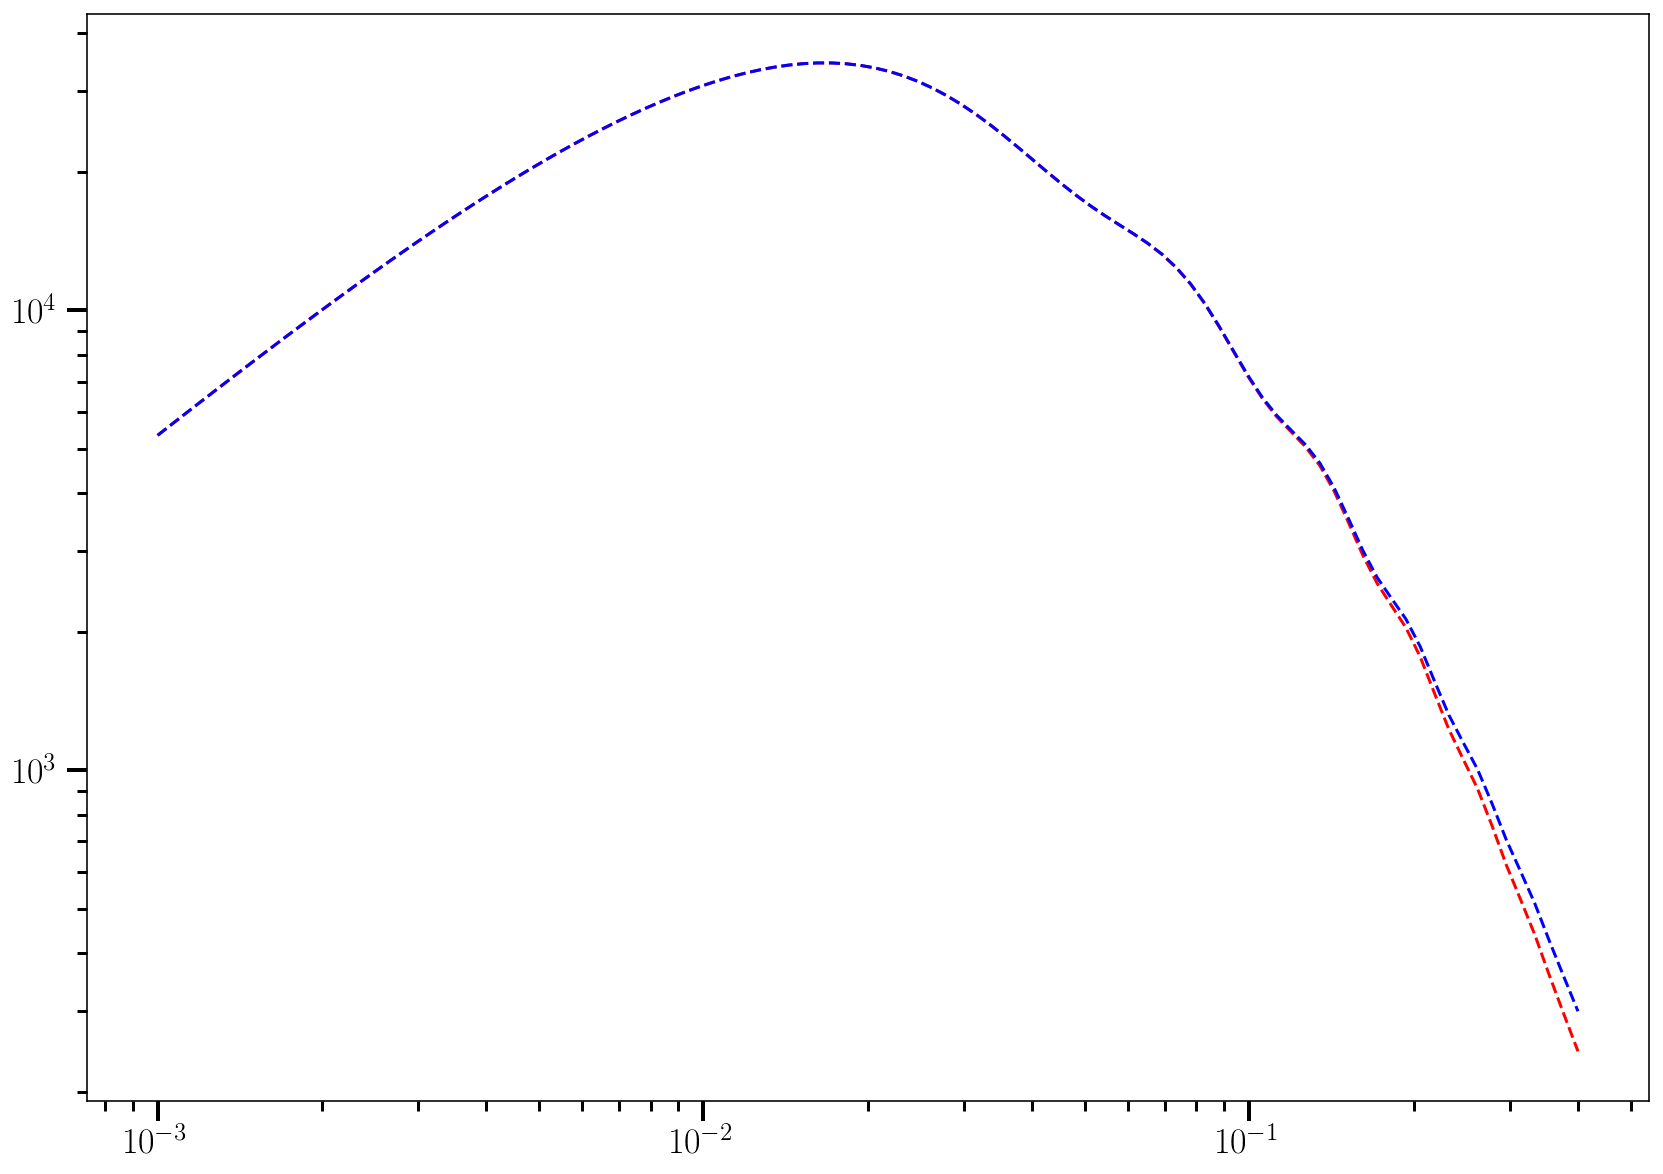

In [531]:
plt.figure(figsize=(14,10))
plt.plot(ks,np.abs(pk_mono_dfog(ks,5.3)),color='red',linestyle='--')
plt.plot(ks,np.abs(pk_mono_dfog1(ks,5.3)),color='blue',linestyle='--')
#plt.plot(ks,np.abs(pk_mono_dfog_wa(ks,5.3,500,0)),color='red',linestyle='--')
#plt.plot(ks,np.abs(pk_mono_dfog1_wa(ks,8,500,0)),color='blue',linestyle='--')
plt.yscale('log')
plt.xscale('log')

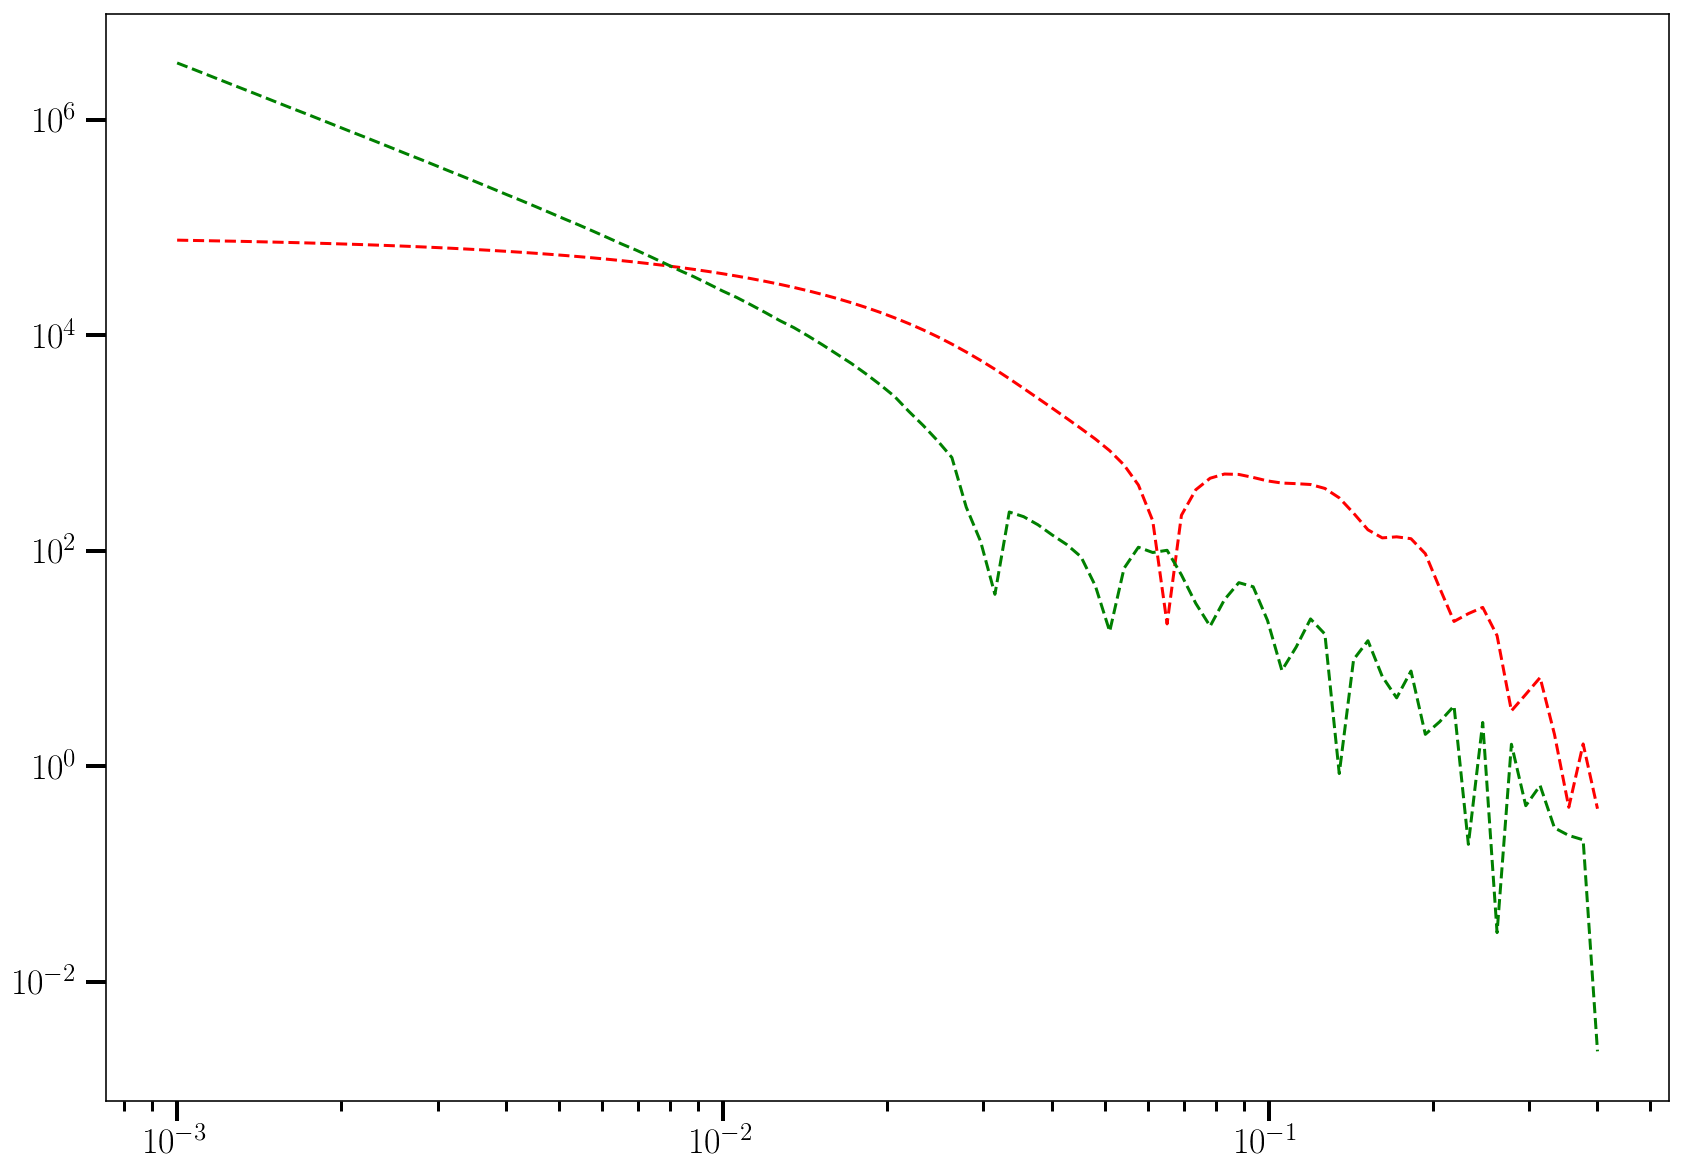

In [864]:
sigma =10
plt.figure(figsize=(14,10))
d=100
plt.plot(ks,np.abs(pk_dipo_dfog_wa(ks,sigma,d,t).imag),color='red',linestyle='--')
plt.plot(ks,np.abs(pk_dipo_3(ks,d,0).imag),color='green',linestyle='--')
#plt.plot(ks,np.abs(pk_octo_dfog_wa(ks,sigma,d,t)),color='blue',linestyle='--')

#plt.plot(ks,Pk_l1_wa,color='red')
#plt.plot(ks,-Pk_l3_wa.imag,color='blue')

#plt.ylim(-1e4,1e4)
plt.yscale('log')
plt.xscale('log')

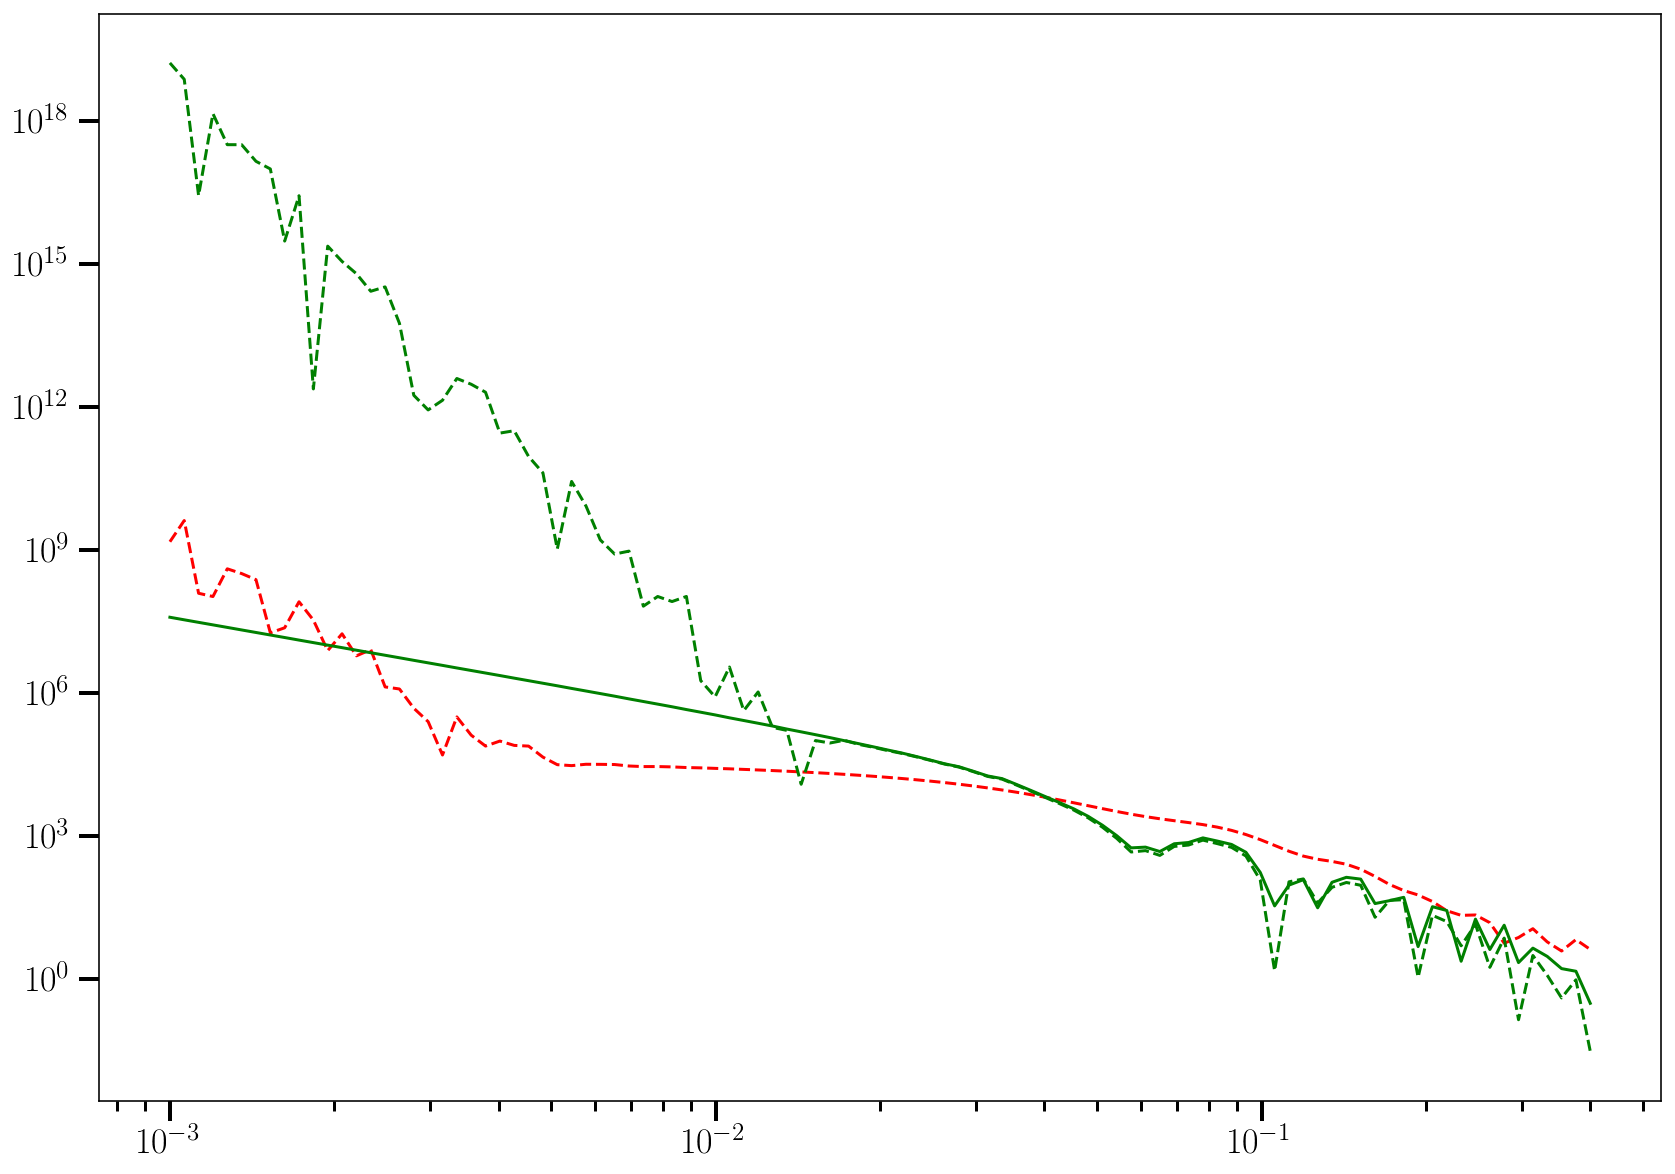

In [911]:
sigma = 5
plt.figure(figsize=(14,10))
d=100
plt.plot(ks,np.abs(pk_octo_dfog_wa(ks,sigma,d,t).imag),color='red',linestyle='--')
plt.plot(ks,np.abs(pk_octo_3(ks,d,0).imag),color='green',linestyle='-')
plt.plot(ks,np.abs(pk_octo_dfog_3(ks,sigma,d,0).imag),color='green',linestyle='--')

#plt.plot(ks,Pk_l1_wa,color='red')
#plt.plot(ks,-Pk_l3_wa.imag,color='blue')

#plt.ylim(1e+3,1e8)
plt.yscale('log')
plt.xscale('log')

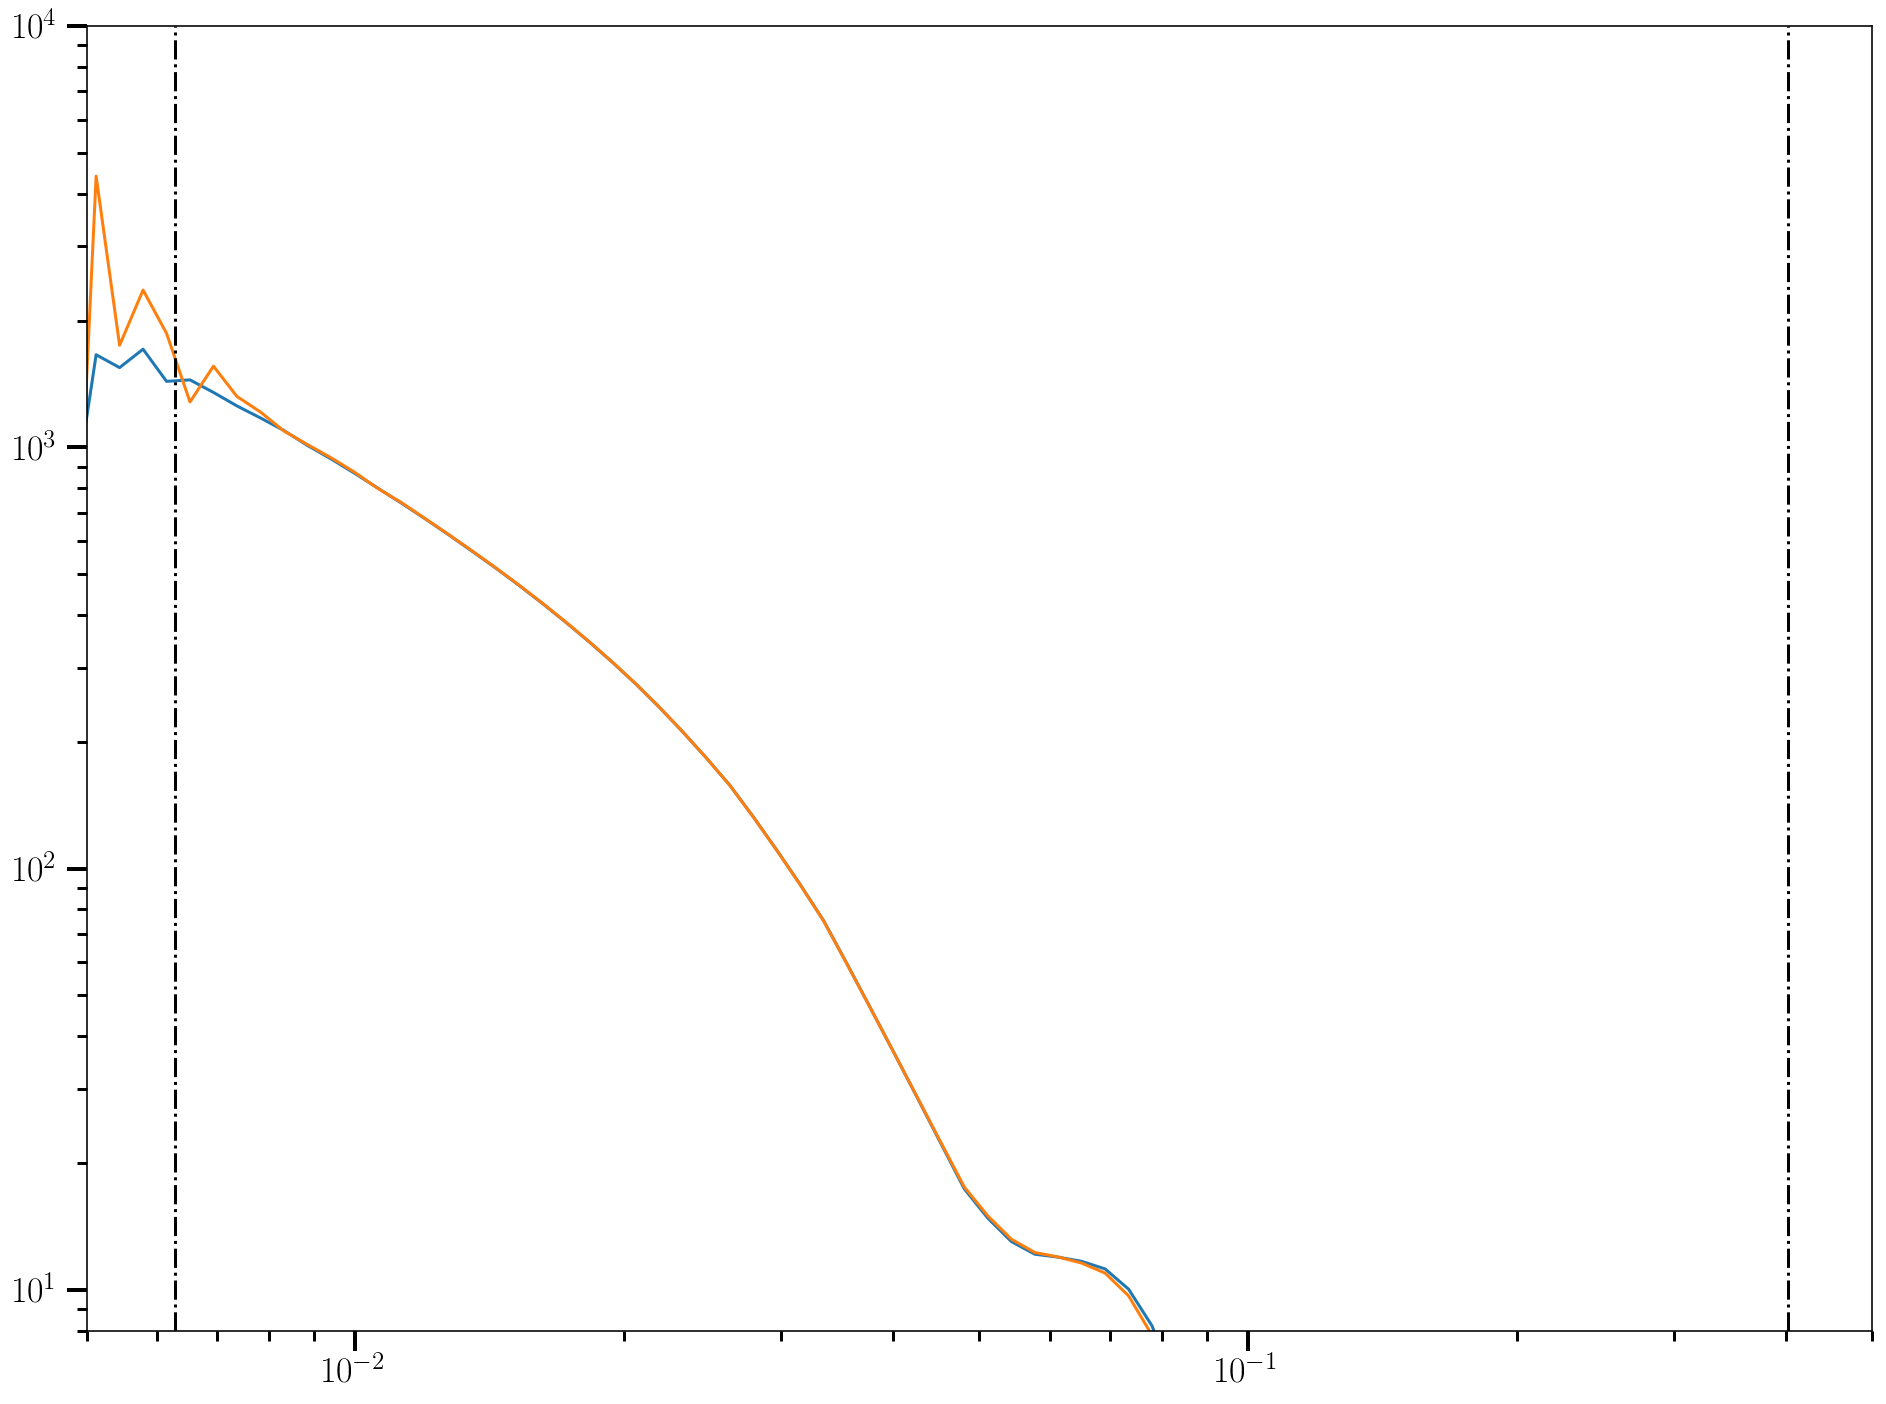

In [380]:
plt.figure(figsize=(16,12))
#plt.plot(ks,Pl2_pp,'k')
plt.plot(ks,-pk_quad_dfog_wa(ks,10,1000,0))
plt.plot(ks,-pk_quad_dfog_wa1(ks,4,1000,0))
#plt.plot(ks,np.abs(Pk_l2_wa))


plt.axvline(x = grid_info[5], linestyle='-.', color = 'black')
plt.axvline(x = grid_info[6], linestyle='-.', color = 'black')

plt.ylim(0.8e+1,1e+4)
plt.xlim(5e-3,5e-1)
plt.yscale('log')
plt.xscale('log')

In [ ]:
plt.figure(figsize=(12,8))
#plt.plot(ks,pk_mono_dfog(ks,5))
plt.plot(ks,np.abs(pk_mono_dfog(ks,10)))
plt.plot(ks,np.abs(pk_mono_dfog(ks,10)+pk_mono_dfog_wa(ks,10,0)))
plt.plot(ks,np.abs(pk_mono_dfog(ks,10)+Pk_l0_wa1))
#plt.plot(ks,np.abs(pk_quad_dfog(ks,10)+pk_quad_dfog_wa(ks,10,0)),'--')

plt.plot(ks,Pl0_pp)
plt.yscale('log')
plt.xscale('log')
plt.show()

In [ ]:
plt.plot(ks,np.abs(pk_dipo_dfog_wa(ks,10,0)))
plt.plot(ks,Pk_l1_wa)
#plt.yscale('log')
plt.xscale('log')

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(ks,np.abs(pk_mono_dfog_wa(ks,10,0)))
plt.plot(ks,np.abs(Pk_l0_wa1))

plt.xscale('log')
plt.yscale('log')
plt.grid(ls='--',lw=0.75)